In [1]:
# Auto-reload edited py_utils/*.py modules without restarting the kernel.
# Run this cell first; then any edits to the ZrMicro Python modules
# (e.g. visualization.py) are picked up automatically on the next cell run.
%load_ext autoreload
%autoreload 2

# Render matplotlib figures inline in the notebook. Without this, an interactive
# kernel (e.g. VS Code / Jupyter) may use a non-inline backend where plt.show()
# emits nothing — so cells "run clean" but display no figures, even though
# fig.savefig(...) still writes the PNGs to disk. (nbconvert --execute forces
# the inline backend automatically, which is why batch runs always embed plots.)
%matplotlib inline

PARAMETER IDENTIFICATION — setup (per-loop-type fit)
Experiments file : Zr_input_parameters.xlsx
Parameters to fit: 23   (delta_DAD_i_300, delta_DAD_i_600, Z_iL, c_LL_a, c_LN_a, epsilon_iL, n_iL_nuc, epsilon_2i, epsilon_3i, E_m_i, E_m_2i, E_b_2i, delta_DAD, c_LL_c, c_LN_c, epsilon_vL, n_vL_nuc, E_a_vL, tau_vL0, Q, Z_N, c_rhoN, k_rhoN_rec)
  log-searched   : c_LL_a, c_LN_a, epsilon_iL, n_iL_nuc, epsilon_2i, epsilon_3i, delta_DAD, c_LL_c, c_LN_c, epsilon_vL, n_vL_nuc, tau_vL0, c_rhoN, k_rhoN_rec
Targets_A (a-loops (interstitial)): 47 points over 9 temperatures   [N: 45, d: 35]  weight w_A=1
Targets_C (c-loops (vacancy)): 5 points over 2 temperatures   [N: 5, d: 5]  weight w_C=1
ODE solves per objective evaluation: 10 (union temperatures: 473K, 500K, 523K, 573K, 583K, 600K, 615K, 623K, 668K, 673K)

Vacancy-loop saturation parameters (manual control via input workbook):
  E_a_vL     = optimised (listed in the Params sheet)
  tau_vL0    = optimised (listed in the Params sheet)
  epsilon_vL 

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.



Model vs experiment at the optimum (per loop type):
loop  T_K     dpa  N_L_exp  N_L_sim  d_exp  d_sim
   A  473   0.133 2.15e+22 4.77e+22    8.1   6.58
   A  500     0.3  1.8e+22 3.01e+22   17.5   7.71
   A  523    0.52  3.4e+22 1.98e+22    8.5   8.26
   A  573    1.83    5e+21 6.63e+21   18.6   8.52
   A  573   0.288    6e+21 7.01e+21   14.5   8.28
   A  573    3.33  2.6e+22 6.63e+21     10   8.52
   A  573     1.5  2.8e+22 6.63e+21      9   8.52
   A  573     0.5  2.8e+22 6.73e+21    7.5   8.46
   A  573     0.5  2.8e+22 6.73e+21    6.8   8.46
   A  573   0.667  3.7e+22 6.66e+21      7    8.5
   A  573   0.125  2.1e+22 7.63e+21    5.8   7.94
   A  573  0.0833    1e+22 7.87e+21    4.5    7.8
   A  573   0.133  2.5e+22 7.58e+21    5.8   7.96
   A  573    0.25  3.6e+22 7.11e+21      7   8.22
   A  573   0.333    3e+22 6.92e+21    6.4   8.34
   A  573 0.00667  2.8e+22 5.53e+21    6.6   4.41
   A  573   0.015    3e+22 9.55e+21    6.8   5.84
   A  573  0.0333  2.7e+22 9.59e+21    7.2   7.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling 

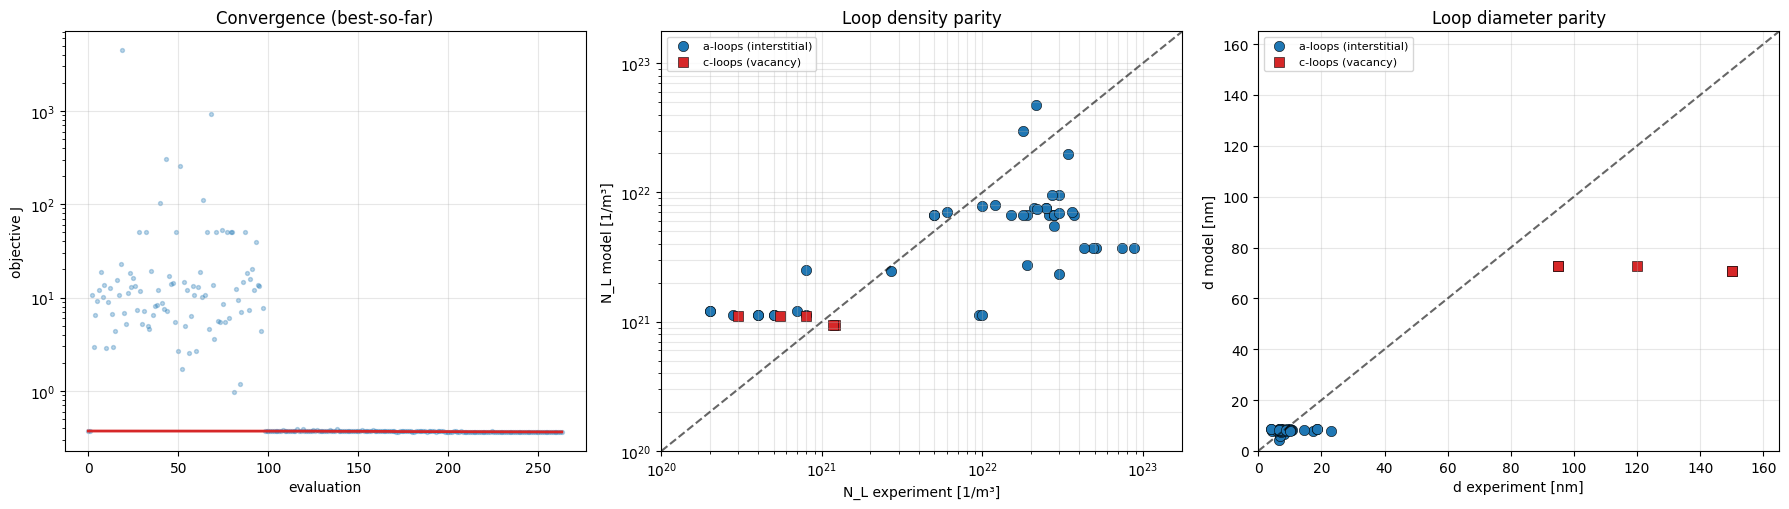


✓ All fit outputs (parameters + comparison + figure) saved to D:\GitHub\ZrClusterDynamics\ZrMicro\output\fit_20260622_143806_7959445


In [2]:
# ZrMicro: PARAMETER IDENTIFICATION  —  fit a-loops and c-loops SEPARATELY
# =========================================================================
# Discover the model parameters that minimise the disagreement between the
# simulated and the *measured* irradiation microstructure, fitting the two loop
# families INDEPENDENTLY and combining them as a weighted sum over loop types:
#
#       J(theta) = w_A * J_A(theta)  +  w_C * J_C(theta)
#
#   J_A : misfit against a-type (interstitial) loops   — sheet "Targets_A"
#   J_C : misfit against c-type (vacancy)      loops   — sheet "Targets_C"
#
# The misfit is averaged over per-(loop, temperature) GROUPS and normalised by
# the total group weight (matches fit_loops_compromise.py):
#
#   score(k,T) = mean[ w_density  * mean(density log-MSE) ,
#                      w_diameter * mean(relative-diameter MSE) ]   (present terms)
#   J = sum_g w_g * score_g / sum_g w_g ,
#       w_g = w_loop[k] * (w_highT_boost if T >= highT_thresh_K else 1)
#
# Model loop families  (one ODE solve per temperature yields BOTH types):
#   a-loops : N_A = (CiL + CaiL)/Omega ,  d_A = 2*<r> over (iL, aiL)  [number-wtd]
#   c-loops : N_C = (CvL + CavL)/Omega ,  d_C = 2*<r> over (vL, avL)  [number-wtd]
#
# Inputs (all read from input/Zr_input_parameters.xlsx):
#   • sheet "Params"    : parameters to identify, with [min, max] bounds
#                         (optional 4th column = nominal / starting value).
#   • sheet "Targets_A" : a-loop experiments — Temp.(K) | Dose(dpa) |
#                         Number Density(m^-3) | Mean Size(nm) | Source
#   • sheet "Targets_C" : c-loop experiments  (same columns; smaller dataset)
#   Blank density or size cells are simply skipped for that row.
#
# Optimiser (choose with OPT_CONFIG['method'] — scipy only):
#   'surrogate'  RBF surrogate self-learning loop (recommended, sample-efficient)
#   'diff_evol'  scipy.optimize.differential_evolution (robust global search)
#   'local'      Nelder-Mead refinement from the nominal seed only (fast)
# A local Nelder-Mead polish is always run on the best point at the end.
#
# GRACEFUL INTERRUPTION: press kernel-interrupt (Ctrl-C) any time — the optimiser
# stops cleanly, keeps the best parameters found, and they are checkpointed to
# disk continuously (section 3b) so the latest optimum survives even a hard kill.

import json
import time as _time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator
from scipy.optimize import differential_evolution, minimize

import io, contextlib
_DEVNULL = contextlib.redirect_stdout(io.StringIO())

# ── Identification input file (extended workbook with Params / Targets sheets) ─
# Resolve paths here too, so this cell runs even if the setup cell above has
# not been executed yet in this kernel session (mirrors BASE_DIR logic above).
# Self-contained bootstrap so this cell runs FIRST (before the forward-run cell):
# resolve paths and import the simulation modules even in a fresh kernel.
from pathlib import Path as _Path
import sys as _sys
try:
    BASE_DIR
except NameError:
    try:
        BASE_DIR = _Path(__file__).resolve().parent.parent
    except NameError:
        BASE_DIR = _Path().resolve().parent
if str(BASE_DIR) not in _sys.path:
    _sys.path.insert(0, str(BASE_DIR))
from py_utils.simulation import ZrMicroSimulation
from py_utils.reaction_rates import ReactionRates
from py_utils.rate_equations import RateEquations
from py_utils.cpp_bridge import (run_cpp_solver, run_cpp_solver_batch,
                                 collect_solver_args)
from py_utils.post_process import calculate_derived_quantities
INPUT_DIR  = BASE_DIR / 'input'
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
FIT_INPUT_FILE = INPUT_DIR / 'Zr_input_parameters.xlsx'

# ════════════════════════════════════════════════════════════════════════════
#  USER SETTINGS  —  edit these
# ════════════════════════════════════════════════════════════════════════════
OPT_CONFIG = {
    'method':      'surrogate',  # 'surrogate' | 'diff_evol' | 'local'  (surrogate: global-ish re-fit for the new model)
    # forward-model fidelity (per ODE solve)
    'backend':     'cpp',        # 'cpp' (SUNDIALS CVODE/BDF, ~50x faster) or 'python' (LSODA)
    'n_points':    100,          # time samples per solve (matches compromise driver)
    'rtol':        1e-6,
    'atol':        1e-20,
    # ── objective weights ────────────────────────────────────────────────────
    # Per-LOOP-TYPE weights (the weighted sum over loop families):
    'w_loop_A':    1.0,          # weight on a-loop (interstitial) misfit J_A
    'w_loop_C':    1.0,          # weight on c-loop (vacancy)      misfit J_C  (=compromise driver)
    # Within each loop type, density vs diameter:
    'w_density':   1.0,          # weight on log-density misfit
    'w_diameter':  1.0,          # weight on relative-diameter misfit
    # Smooth-rise (anti-overshoot) penalty: relative downward total variation
    # of every loop density/size trajectory (dose >= os_dose_lo). 0 = monotonic
    # rise to a plateau; larger = peak-then-collapse. Rewards smooth curves.
    'w_overshoot': 1.0,          # weight on the overshoot penalty (0 disables)
    'os_dose_lo':  1e-3,         # ignore the sub-threshold embryo transient [dpa]
    # High-temperature density emphasis (applied within each loop type). The
    # high-T tail is sparse, so it is otherwise swung freely while the dense
    # low/mid-T cluster dominates the per-type objective.
    'balance_by_temperature': True,   # weight each temperature group equally
    'highT_thresh_K':         650.0,  # T >= this gets an extra boost
    'w_highT_boost':          2.0,    # multiplier applied above the threshold (=compromise driver)
    # 'surrogate' budget
    'n_init':      None,         # initial LHS design (None → 2·n_params+1)
    'n_infill':    50,           # surrogate-guided refinement steps
    # 'diff_evol' budget
    'de_maxiter':  15,
    'de_popsize':  6,
    # final local polish
    'polish':      True,
    'polish_iter': 100,
    'seed':        0,
}
LOG_RATIO_THRESH = 20.0   # parameters with max/min ≥ this are searched in log10
# ════════════════════════════════════════════════════════════════════════════

warnings.filterwarnings('ignore')   # silence transient LSODA / RBF warnings
_rng = np.random.default_rng(OPT_CONFIG['seed'])

LOOP_TYPES = ('A', 'C')                       # a-loops (interstitial), c-loops (vacancy)
LOOP_LABEL = {'A': 'a-loops (interstitial)', 'C': 'c-loops (vacancy)'}
LOOP_WEIGHT = {'A': OPT_CONFIG['w_loop_A'], 'C': OPT_CONFIG['w_loop_C']}


# ── 1. Load the parameter bounds and the per-type experimental targets ───────
# THE 'Params' SHEET IS THE OPTIMISATION LIST: every row with a valid [min, max]
# becomes a fitted parameter. Add or remove rows in the spreadsheet to choose
# which parameters are optimised. Only genuinely DERIVED quantities (recomputed
# by the model from others) are dropped, since fitting them has no effect.
DERIVED_PARAMS = {'tau_vL'}

# Vacancy-loop saturation parameters (E_a_vL, tau_vL0, epsilon_vL) are handled
# MANUALLY via the input workbook: list one in the Params sheet to OPTIMISE it,
# or omit it to hold it FIXED at its workbook value (E_a_vL, tau_vL0 ->
# Model_Parameters; epsilon_vL -> Physical_Properties). There is no automatic
# anchor pre-fit / freeze. (G, the dose rate, is a MEASURED input; vary it in
# Material_Environment, not via the Params sheet.)
VL_SAT_PARAMS = ('E_a_vL', 'tau_vL0', 'epsilon_vL')
_DROP_FROM_FIT = DERIVED_PARAMS


def _load_targets(path, sheet):
    """Read one experimental-target sheet into a tidy (T, dpa, N_L, d) frame.

    Expected columns (first four): Temp.(K) | Dose(dpa) | Number Density(m^-3) |
    Mean Size(nm). 'Mean Size' is the loop DIAMETER (matches the model's 2*<r>).
    Rows with no dose, or with neither density nor size, are dropped.
    """
    tdf = pd.read_excel(path, sheet_name=sheet)
    tdf = tdf.iloc[:, :4]
    tdf.columns = ['T', 'dpa', 'N_L', 'd']
    for col in ('T', 'dpa', 'N_L', 'd'):
        tdf[col] = pd.to_numeric(tdf[col], errors='coerce')
    tdf['T'] = tdf['T'].ffill()
    tdf = tdf.dropna(subset=['T', 'dpa'])
    tdf = tdf[~(tdf['N_L'].isna() & tdf['d'].isna())].reset_index(drop=True)
    return tdf


def load_fit_tables(path):
    pdf = pd.read_excel(path, sheet_name='Params', header=0)
    pdf = pdf.rename(columns={pdf.columns[0]: 'parameter',
                              pdf.columns[1]: 'min', pdf.columns[2]: 'max'})
    pdf = pdf.dropna(subset=['parameter', 'min', 'max'])
    _pnames = pdf['parameter'].astype(str).str.strip()
    _drop = _pnames.isin(_DROP_FROM_FIT)
    if _drop.any():
        print('  skipping derived parameter(s) in Params sheet (recomputed by '
              'the model):', ', '.join(_pnames[_drop]))
        pdf = pdf[~_drop]
    names = pdf['parameter'].astype(str).str.strip().tolist()
    lo = pdf['min'].astype(float).to_numpy()
    hi = pdf['max'].astype(float).to_numpy()
    if pdf.shape[1] > 3:
        nom = pd.to_numeric(pdf.iloc[:, 3], errors='coerce').to_numpy()
    else:
        nom = np.full(len(names), np.nan)
    nom = np.where(np.isnan(nom), np.sqrt(np.maximum(lo * hi, 1e-300)), nom)

    targets = {'A': _load_targets(path, 'Targets_A'),
               'C': _load_targets(path, 'Targets_C')}
    return names, lo, hi, nom, targets


PARAM_NAMES, LO, HI, NOM, TARGETS = load_fit_tables(FIT_INPUT_FILE)
# Contamination fix: the high-T (>=650 K) Targets_A SIZE rows are large
# (33-62 nm) VACANCY-character loops mislabeled as a-loops -- exclude their
# DIAMETER from the a-loop fit (their density is still used). [[dad-loop-bias]]
TARGETS['A'].loc[TARGETS['A']['T'] >= 650.0, 'd'] = np.nan
N_PARAM = len(PARAM_NAMES)

# Per-type temperature groups, and the UNION of temperatures actually solved
# (one ODE solve per temperature serves whichever loop types have data there).
GROUPS = {k: {float(T): g.reset_index(drop=True)
              for T, g in TARGETS[k].groupby('T')} for k in LOOP_TYPES}
EVAL_TEMPS = sorted(set(GROUPS['A']) | set(GROUPS['C']))

# log10 transform for wide-range parameters → optimiser sees comparable scales
LOG_MASK = np.array([(lo > 0 and hi / lo >= LOG_RATIO_THRESH)
                     for lo, hi in zip(LO, HI)])
def _to_t(v):    return np.where(LOG_MASK, np.log10(np.maximum(v, 1e-300)), v)
def _from_t(xt): return np.where(LOG_MASK, 10.0 ** xt, xt)
LO_T, HI_T = _to_t(LO), _to_t(HI)
X0_T = np.clip(_to_t(NOM), LO_T, HI_T)

print("=" * 72)
print("PARAMETER IDENTIFICATION — setup (per-loop-type fit)")
print("=" * 72)
print(f"Experiments file : {FIT_INPUT_FILE.name}")
print(f"Parameters to fit: {N_PARAM}   ({', '.join(PARAM_NAMES)})")
print(f"  log-searched   : {', '.join(np.array(PARAM_NAMES)[LOG_MASK]) or '(none)'}")
for k in LOOP_TYPES:
    t = TARGETS[k]
    print(f"Targets_{k} ({LOOP_LABEL[k]}): {len(t)} points over "
          f"{t['T'].nunique()} temperatures   "
          f"[N: {int(t['N_L'].notna().sum())}, d: {int(t['d'].notna().sum())}]  "
          f"weight w_{k}={LOOP_WEIGHT[k]:g}")
print(f"ODE solves per objective evaluation: {len(EVAL_TEMPS)} "
      f"(union temperatures: {', '.join(f'{T:.0f}K' for T in EVAL_TEMPS)})")


# ── 2. Forward model: one persistent simulation, re-configured per evaluation ─
with _DEVNULL:
    _SIM = ZrMicroSimulation(str(FIT_INPUT_FILE))


# ── 2b. Vacancy-loop saturation parameters — taken from the input workbook ────
# E_a_vL, tau_vL0 and epsilon_vL are NO LONGER auto-pre-fit/frozen. Each is
# either OPTIMISED (listed in the Params sheet) or held FIXED at its value in the
# input workbook. VL_FIXED_PARAMS captures the fixed ones (with their workbook
# values) for reporting, provenance, and the ready-to-paste override block.
def _input_value(sim, key):
    for d in (sim.input_data.model_params, sim.input_data.physical_props,
              sim.input_data.material_params):
        if key in d:
            return float(d[key])
    return None

VL_FIXED_PARAMS = {k: _input_value(_SIM, k) for k in VL_SAT_PARAMS
                   if k not in PARAM_NAMES and _input_value(_SIM, k) is not None}

print()
print("Vacancy-loop saturation parameters (manual control via input workbook):")
for _k in VL_SAT_PARAMS:
    if _k in PARAM_NAMES:
        print(f"  {_k:<11}= optimised (listed in the Params sheet)")
    elif _k in VL_FIXED_PARAMS:
        print(f"  {_k:<11}= {VL_FIXED_PARAMS[_k]:.6g}   (fixed from input workbook)")
    else:
        print(f"  {_k:<11}= (not present in workbook; model default in use)")


def _sheet_for(key):
    inp = _SIM.input_data
    for d in (inp.material_params, inp.physical_props, inp.model_params):
        if key in d:
            return d
    return _SIM.input_data.model_params   # new key → Model_Parameters

def _configure(pdict, T):
    """Inject a parameter set + temperature and rebuild the physics modules."""
    inp = _SIM.input_data
    for k, v in pdict.items():
        _sheet_for(k)[k] = float(v)
    inp.material_params['T'] = float(T)
    with _DEVNULL:
        inp.calculate_derived_parameters()
        _SIM.reaction_rates = ReactionRates(inp)
        _SIM.rate_equations = RateEquations(inp, _SIM.reaction_rates)

# Per-evaluation forward solve (fast C++ SUNDIALS subprocess or scipy LSODA).
_FIT_SOLVER_METHOD = {'backend': 'cvode', 'lmm': 'bdf', 'linsol': 'dense'}

def _forward_solve(t_end):
    if OPT_CONFIG.get('backend', 'python') == 'cpp':
        solver_config = {
            't_begin': 1e-1, 't_end': t_end,
            'n_points': OPT_CONFIG['n_points'],
            'rtol': OPT_CONFIG['rtol'], 'atol': OPT_CONFIG['atol'],
            'log_time': True, 'solver_method': _FIT_SOLVER_METHOD,
        }
        with _DEVNULL:
            return run_cpp_solver(_SIM, solver_config, base_dir=BASE_DIR)
    with _DEVNULL:
        return _SIM.run_simulation(t_begin=1e-1, t_end=t_end,
                                   n_points=OPT_CONFIG['n_points'], method='LSODA',
                                   rtol=OPT_CONFIG['rtol'], atol=OPT_CONFIG['atol'],
                                   log_time=True)


def model_history(pdict, T, max_dpa):
    """One ODE solve at temperature T → (dose, {type: (N[1/m^3], d[nm])}).

    Returns BOTH loop families from a single integration:
      'A' : a-loops = CiL+CaiL          , diameter = 2*<r> over (iL, aiL)
      'C' : c-loops = CvL+CavL          , diameter = 2*<r> over (vL, avL)
    Returns None if the integration fails.
    """
    _configure(pdict, T)
    G = float(pdict.get('G', _SIM.input_data.material_params['G']))
    t_end = min(10.0 ** np.ceil(np.log10(max(max_dpa / G * 3.0, 1e6))), 1e10)
    r = _forward_solve(t_end)
    if r is None:
        return None
    c, ls = r['concentrations'], r['loop_sizes']
    Om = _SIM.input_data.physical_props['Omega']
    dose = G * r['time']
    Na = c['CiL'] + c['CaiL']
    Nc = c['CvL'] + c['CavL']
    d_A = 2.0 * (c['CiL'] * ls['r_iL'] + c['CaiL'] * ls['r_aiL']) \
          / np.maximum(Na, 1e-30) * 1e9
    d_C = 2.0 * (c['CvL'] * ls['r_vL'] + c['CavL'] * ls['r_avL']) \
          / np.maximum(Nc, 1e-30) * 1e9
    return dose, {'A': (np.maximum(Na / Om, 1e-30), d_A),
                  'C': (np.maximum(Nc / Om, 1e-30), d_C)}


def model_history_batch(pdict, temps_maxdpa):
    """Batched model_history: solve EVERY (T, max_dpa) case in ONE C++
    subprocess (OpenMP-parallel over temperatures) instead of one subprocess
    per temperature, then post-process each case on its T-specific InputData.

    Returns {T: (dose, series)} with the same `series` shape as model_history;
    a case that fails to integrate maps to None. Falls back transparently to
    per-T model_history when the C++ backend is not selected. [[fit-batch-openmp]]
    """
    if OPT_CONFIG.get('backend', 'python') != 'cpp':
        return {T: model_history(pdict, T, md) for T, md in temps_maxdpa}

    # Phase 1 — configure per T and serialise each case's solver arguments.
    cases, meta = [], []
    for T, max_dpa in temps_maxdpa:
        _configure(pdict, T)
        G = float(pdict.get('G', _SIM.input_data.material_params['G']))
        t_end = min(10.0 ** np.ceil(np.log10(max(max_dpa / G * 3.0, 1e6))), 1e10)
        solver_config = {
            't_begin': 1e-1, 't_end': t_end,
            'n_points': OPT_CONFIG['n_points'],
            'rtol': OPT_CONFIG['rtol'], 'atol': OPT_CONFIG['atol'],
            'log_time': True, 'solver_method': _FIT_SOLVER_METHOD,
        }
        with _DEVNULL:
            cases.append(collect_solver_args(_SIM, solver_config))
        meta.append((T, G))

    # Phase 2 — one parallel subprocess solves all cases.
    with _DEVNULL:
        raw = run_cpp_solver_batch(cases, base_dir=BASE_DIR)

    # Phase 3 — post-process each trajectory on its own T-specific physics.
    out = {}
    for (T, G), ty in zip(meta, raw):
        if ty is None:
            out[T] = None
            continue
        t, y = ty
        _configure(pdict, T)
        with _DEVNULL:
            r = calculate_derived_quantities(t, y, _SIM.input_data,
                                             _SIM.rate_equations)
        c, ls = r['concentrations'], r['loop_sizes']
        Om = _SIM.input_data.physical_props['Omega']
        dose = G * r['time']
        Na = c['CiL'] + c['CaiL']
        Nc = c['CvL'] + c['CavL']
        d_A = 2.0 * (c['CiL'] * ls['r_iL'] + c['CaiL'] * ls['r_aiL'])               / np.maximum(Na, 1e-30) * 1e9
        d_C = 2.0 * (c['CvL'] * ls['r_vL'] + c['CavL'] * ls['r_avL'])               / np.maximum(Nc, 1e-30) * 1e9
        out[T] = (dose, {'A': (np.maximum(Na / Om, 1e-30), d_A),
                         'C': (np.maximum(Nc / Om, 1e-30), d_C)})
    return out


def _sample(dose, N, d, dpas):
    """Interpolate (N, d) onto the requested dose levels (log-dose, log-N)."""
    ld = np.log10(np.maximum(dose, 1e-30))
    q = np.log10(np.clip(np.asarray(dpas, float), dose.min(), dose.max()))
    return 10.0 ** np.interp(q, ld, np.log10(N)), np.interp(q, ld, d)


def predict_type(pdict, T, dpas, kind):
    """Model (N_L[1/m^3], d[nm]) for ONE loop type at the requested doses."""
    hist = model_history(pdict, T, float(np.max(dpas)))
    if hist is None:
        return None, None
    dose, series = hist
    N, d = series[kind]
    return _sample(dose, N, d, dpas)


# ── 3. Objective + evaluation history (for convergence & best-so-far) ────────
_PENALTY = 50.0
_HIST = {'x': [], 'J': [], 'best_J': np.inf, 'best_x': X0_T.copy(),
         'best_types': {}, 't0': _time.time(), 'n': 0}

# ── 3b. Incremental checkpoint of the best-so-far parameters ─────────────────
try:
    import subprocess
    _hash = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'],
                           capture_output=True, text=True,
                           cwd=str(BASE_DIR)).stdout.strip() or 'nogit'
except Exception:
    _hash = 'nogit'
_run_dir = OUTPUT_DIR / f"fit_{datetime.now():%Y%m%d_%H%M%S}_{_hash}"
_run_dir.mkdir(parents=True, exist_ok=True)

def _checkpoint_best():
    """Atomically write the latest best parameters to optimal_parameters.csv."""
    x = _HIST['best_x']
    _tmp = _run_dir / 'optimal_parameters.csv.tmp'
    pd.DataFrame({'parameter': PARAM_NAMES, 'min': LO, 'optimal': _from_t(x),
                  'max': HI, 'log_searched': LOG_MASK}
                 ).to_csv(_tmp, index=False)
    _tmp.replace(_run_dir / 'optimal_parameters.csv')


def _overshoot_metric(dose, y, logscale):
    """Relative downward total variation of a trajectory over dose>=os_dose_lo.
    0 = monotonic rise to a plateau; ->1 = the peak is fully retraced (collapse).
    Penalises BOTH a post-peak collapse and interior non-monotonic wiggles."""
    lo = OPT_CONFIG.get('os_dose_lo', 0.0)
    m = np.asarray(dose) >= lo
    if int(np.sum(m)) < 3:
        return 0.0
    v = np.log10(np.maximum(np.asarray(y)[m], 1e-30)) if logscale else np.asarray(y)[m]
    dv = np.diff(v)
    down = float(-np.sum(dv[dv < 0]))
    rise = max(float(v.max() - v.min()), 1e-9)
    return down / rise


def objective(xt):
    """Per-(loop, temperature)-GROUP misfit, matching fit_loops_compromise.py.

    For each (loop type k, temperature T) group:
        score = mean[ w_density*mean(density log-MSE), w_diameter*mean(rel-diam MSE) ]
                (only terms with data are included in the inner mean)
    and the objective is the weight-normalised average over groups:
        J = sum_g w_g*score_g / sum_g w_g ,  w_g = w_loop[k]*(boost if T>=thresh).
    a-loop diameters at T>=650 K are pre-excluded (NaN) as vacancy-character loops.
    """
    xt = np.clip(np.asarray(xt, float), LO_T, HI_T)        # project into bounds
    pdict = dict(zip(PARAM_NAMES, _from_t(xt)))
    wD, wS = OPT_CONFIG['w_density'], OPT_CONFIG['w_diameter']
    boost  = OPT_CONFIG.get('w_highT_boost', 1.0)
    thr    = OPT_CONFIG.get('highT_thresh_K', np.inf)
    J = _PENALTY
    J_types = {}
    try:
        terms = wsum = 0.0
        os_terms = []
        tk = {k: {'t': 0.0, 'w': 0.0, 'sN': 0.0, 'wN': 0.0, 'sD': 0.0, 'wD': 0.0}
              for k in LOOP_TYPES}
        ok = True
        # Solve EVERY temperature for this parameter set in ONE OpenMP-parallel
        # C++ subprocess (vs one subprocess per temperature) — this is the
        # dominant cost of each objective evaluation. [[fit-batch-openmp]]
        _tm = [(T, max(float(GROUPS[k][T]['dpa'].max())
                       for k in LOOP_TYPES if T in GROUPS[k]))
               for T in EVAL_TEMPS]
        hist_all = model_history_batch(pdict, _tm)
        for T in EVAL_TEMPS:
            hist = hist_all.get(T)
            if hist is None:
                ok = False
                break
            dose, series = hist
            nT = boost if T >= thr else 1.0
            for k in LOOP_TYPES:
                _Ntr, _dtr = series[k]
                os_terms.append(_overshoot_metric(dose, _Ntr, True))
                os_terms.append(_overshoot_metric(dose, _dtr, False))
                if T not in GROUPS[k]:
                    continue
                g = GROUPS[k][T]
                N_sim, d_sim = _sample(dose, series[k][0], series[k][1],
                                       g['dpa'].to_numpy())
                mN, md = g['N_L'].to_numpy(), g['d'].to_numpy()
                okN, okD = ~np.isnan(mN), ~np.isnan(md)
                res = []
                if okN.any():
                    dMSE = float(np.mean((np.log10(N_sim[okN])
                                          - np.log10(mN[okN])) ** 2))
                    res.append(wD * dMSE)
                    tk[k]['sN'] += dMSE * nT; tk[k]['wN'] += nT
                if okD.any():
                    sMSE = float(np.mean(((d_sim[okD] - md[okD]) / md[okD]) ** 2))
                    res.append(wS * sMSE)
                    tk[k]['sD'] += sMSE * nT; tk[k]['wD'] += nT
                if not res:
                    continue
                score = float(np.mean(res))
                w = LOOP_WEIGHT[k] * nT
                terms += score * w; wsum += w
                tk[k]['t'] += score * nT; tk[k]['w'] += nT
        if ok and wsum:
            J_data = terms / wsum
            J_os   = float(np.mean(os_terms)) if os_terms else 0.0
            J = J_data + OPT_CONFIG.get('w_overshoot', 0.0) * J_os
            _HIST['last_os'] = J_os
            for k in LOOP_TYPES:
                a = tk[k]
                J_types[k] = {'J':     a['t']  / a['w']  if a['w']  else 0.0,
                              'lossN': a['sN'] / a['wN'] if a['wN'] else 0.0,
                              'lossD': a['sD'] / a['wD'] if a['wD'] else 0.0}
    except KeyboardInterrupt:
        raise                              # propagate so the run cell can stop & save
    except Exception:
        J = _PENALTY
        J_types = {}
    _HIST['n'] += 1
    _HIST['x'].append(xt.copy()); _HIST['J'].append(J)
    if J < _HIST['best_J']:
        _HIST['best_J'], _HIST['best_x'] = J, xt.copy()
        _HIST['best_types'] = J_types
        try:
            _checkpoint_best()      # persist the new optimum immediately (interrupt-safe)
        except Exception:
            pass
    if _HIST['n'] % 10 == 0 or J <= _HIST['best_J']:
        print(f"  eval {_HIST['n']:4d}   J = {J:8.4f}   best = {_HIST['best_J']:8.4f}"
              f"   ({_time.time() - _HIST['t0']:5.0f}s)")
    return float(J)


# ── 4. Optimisers ────────────────────────────────────────────────────────────
def _lhs(n, d):
    cut = np.linspace(0, 1, n + 1)
    U = np.empty((n, d))
    for j in range(d):
        U[:, j] = _rng.permutation(cut[:-1] + _rng.random(n) / n)
    return U

def run_surrogate():
    """RBF-surrogate 'self-learning' optimisation in normalised [0,1]^d space."""
    d = N_PARAM
    span = HI_T - LO_T + 1e-300
    n_init = OPT_CONFIG['n_init'] or (2 * d + 1)
    U = _lhs(n_init, d)
    U[0] = np.clip((X0_T - LO_T) / span, 0, 1)            # seed with nominal
    print(f"\n[surrogate] initial design: {n_init} runs ...")
    Y = np.array([objective(LO_T + u * span) for u in U])
    print(f"[surrogate] infill: {OPT_CONFIG['n_infill']} steps ...")
    for it in range(OPT_CONFIG['n_infill']):
        sur = RBFInterpolator(U, Y, kernel='thin_plate_spline', smoothing=1e-6)
        res = differential_evolution(
            lambda u: float(np.atleast_1d(sur(np.atleast_2d(u)))[0]),
            bounds=[(0, 1)] * d, maxiter=40, popsize=12, tol=1e-7,
            seed=int(_rng.integers(1_000_000_000)), polish=False)
        cand = _rng.random(d) if _rng.random() < 0.25 else res.x   # explore/exploit
        Y = np.append(Y, objective(LO_T + cand * span))
        U = np.vstack([U, cand])
    return _HIST['best_x']

def run_diff_evol():
    print("\n[diff_evol] global search ...")
    res = differential_evolution(
        objective, bounds=list(zip(LO_T, HI_T)), x0=X0_T,
        maxiter=OPT_CONFIG['de_maxiter'], popsize=OPT_CONFIG['de_popsize'],
        tol=1e-6, seed=OPT_CONFIG['seed'], polish=False, init='sobol')
    return res.x

def run_local(x0):
    print("\n[local] Nelder-Mead refinement ...")
    res = minimize(objective, x0, method='Nelder-Mead',
                   options={'maxiter': OPT_CONFIG['polish_iter'],
                            'xatol': 1e-3, 'fatol': 1e-4, 'adaptive': True})
    return res.x


# ── 5. Run the identification ────────────────────────────────────────────────
print("\n" + "=" * 72)
print(f"OPTIMISING  (method = {OPT_CONFIG['method']})   "
      f"J = w_A·J_A + w_C·J_C  =  {LOOP_WEIGHT['A']:g}·J_A + {LOOP_WEIGHT['C']:g}·J_C")
print("=" * 72)
J_nominal = objective(X0_T)
print(f"Nominal objective J0 = {J_nominal:.4f}")
_interrupted = False
try:
    if OPT_CONFIG['method'] == 'surrogate':
        x_best = run_surrogate()
    elif OPT_CONFIG['method'] == 'diff_evol':
        x_best = run_diff_evol()
    elif OPT_CONFIG['method'] == 'local':
        x_best = run_local(X0_T)
    else:
        raise ValueError(f"unknown method {OPT_CONFIG['method']!r}")
    if OPT_CONFIG['polish']:
        run_local(_HIST['best_x'])
except KeyboardInterrupt:
    _interrupted = True
    print("\n⚠️  Interrupted — exiting gracefully, keeping the best parameters "
          "found so far.")

x_best = _HIST['best_x']
J_best = _HIST['best_J']
best_params = dict(zip(PARAM_NAMES, _from_t(x_best)))

print("\n" + "=" * 72)
print(f"BEST  J = {J_best:.4f}   (nominal {J_nominal:.4f},  "
      f"{(1 - J_best / max(J_nominal, 1e-12)) * 100:.0f}% reduction,  "
      f"{_HIST['n']} evaluations,  {_time.time() - _HIST['t0']:.0f}s)"
      f"{'   [INTERRUPTED]' if _interrupted else ''}")
if _HIST['best_types']:
    print("per-loop-type breakdown at the optimum:")
    for k in LOOP_TYPES:
        bt = _HIST['best_types'].get(k, {})
        print(f"  {LOOP_LABEL[k]:<26} w_{k}={LOOP_WEIGHT[k]:g}  "
              f"J_{k}={bt.get('J', float('nan')):.4f}  "
              f"(density {bt.get('lossN', float('nan')):.4f}, "
              f"diameter {bt.get('lossD', float('nan')):.4f})")
print("=" * 72)
print(f"{'parameter':<12}{'min':>12}{'optimal':>14}{'max':>12}   note")
print("-" * 72)
for nm, lo, hi, v in zip(PARAM_NAMES, LO, HI, _from_t(x_best)):
    frac = (np.log10(v) - np.log10(lo)) / (np.log10(hi) - np.log10(lo)) \
        if (LOG_MASK[PARAM_NAMES.index(nm)] and lo > 0) else (v - lo) / (hi - lo)
    note = 'AT BOUND' if (frac < 0.02 or frac > 0.98) else ''
    print(f"{nm:<12}{lo:>12.3g}{v:>14.4g}{hi:>12.3g}   {note}")
print("-" * 72)
print("fixed (from input workbook, not optimised):  "
      + (',  '.join(f'{k}={v:.4g}' for k, v in VL_FIXED_PARAMS.items())
         or '(none)'))


# ── 6. Persist the optimal parameters IMMEDIATELY (interrupt-safe) ────────────
def save_optimal_parameters(run_dir, report_df=None):
    """Write optimal_parameters.csv + fit_provenance.md from the best-so-far."""
    x = _HIST['best_x']
    pd.DataFrame({'parameter': PARAM_NAMES, 'min': LO, 'optimal': _from_t(x),
                  'max': HI, 'log_searched': LOG_MASK}
                 ).to_csv(run_dir / 'optimal_parameters.csv', index=False)
    with open(run_dir / 'fit_provenance.md', 'w', encoding='utf-8') as fh:
        fh.write(f"# ZrMicro parameter identification (per-loop-type fit)\n\n")
        fh.write(f"- date: {datetime.now():%Y-%m-%d %H:%M:%S}\n")
        fh.write(f"- method: {OPT_CONFIG['method']} (+local polish={OPT_CONFIG['polish']})\n")
        fh.write(f"- interrupted: {_interrupted}\n")
        fh.write(f"- evaluations: {_HIST['n']}\n")
        fh.write(f"- objective: J = {LOOP_WEIGHT['A']:g}·J_A + {LOOP_WEIGHT['C']:g}·J_C\n")
        fh.write(f"- objective value: nominal {J_nominal:.4f} -> best {_HIST['best_J']:.4f}\n")
        for k in LOOP_TYPES:
            bt = _HIST['best_types'].get(k, {})
            fh.write(f"- {LOOP_LABEL[k]}: {len(TARGETS[k])} points, "
                     f"J_{k}={bt.get('J', float('nan')):.4f} "
                     f"(density {bt.get('lossN', float('nan')):.4f}, "
                     f"diameter {bt.get('lossD', float('nan')):.4f})\n")
        fh.write("\n## Optimal parameters\n\n| parameter | min | optimal | max |\n|---|---|---|---|\n")
        for nm, lo, hi, v in zip(PARAM_NAMES, LO, HI, _from_t(x)):
            fh.write(f"| {nm} | {lo:.4g} | {v:.6g} | {hi:.4g} |\n")
        fh.write("\n## Fixed vacancy-loop parameters (from input workbook, "
                 "not optimised)\n\n")
        for k, v in VL_FIXED_PARAMS.items():
            fh.write(f"- {k} = {v:.6g}\n")
    if report_df is not None:
        report_df.to_csv(run_dir / 'model_vs_experiment.csv', index=False)

save_optimal_parameters(_run_dir)
print(f"\n✓ Optimal parameters saved to {_run_dir}"
      f"{'   (run was interrupted)' if _interrupted else ''}")

# Ready-to-paste override block for the main run cell above.
PARAMETER_OVERRIDES_BEST = {**{k: float(v) for k, v in best_params.items()},
                            **{k: float(v) for k, v in VL_FIXED_PARAMS.items()}}
print("\nPaste these into PARAMETER_OVERRIDES (top cell) to run the model at the fit:")
print("PARAMETER_OVERRIDES_BEST = {")
for k, v in PARAMETER_OVERRIDES_BEST.items():
    print(f"    {k!r:<12}: {v:.6g},")
print("}")


# ── 7. Compare model vs experiment per loop type & make parity figures ───────
report = None
fig = None
try:
    rows = []
    for k in LOOP_TYPES:
        for T, g in GROUPS[k].items():
            N_L, d = predict_type(best_params, T, g['dpa'].to_numpy(), k)
            if N_L is None:
                continue
            for i in range(len(g)):
                rows.append({'loop': k, 'T_K': T, 'dpa': g['dpa'][i],
                             'N_L_exp': g['N_L'][i], 'N_L_sim': N_L[i],
                             'd_exp': g['d'][i], 'd_sim': d[i]})
    report = pd.DataFrame(rows)
    report.to_csv(_run_dir / 'model_vs_experiment.csv', index=False)
    print("\nModel vs experiment at the optimum (per loop type):")
    with pd.option_context('display.float_format', lambda v: f'{v:.3g}'):
        print(report.to_string(index=False))

    _TYC = {'A': 'tab:blue', 'C': 'tab:red'}
    _TYM = {'A': 'o', 'C': 's'}
    fig, ax = plt.subplots(1, 3, figsize=(18, 5.2))

    J_arr = np.array(_HIST['J'])
    ax[0].plot(np.minimum.accumulate(J_arr), lw=2, color='C3')
    ax[0].scatter(range(len(J_arr)), J_arr, s=8, alpha=0.3, color='C0')
    ax[0].set(xlabel='evaluation', ylabel='objective J', yscale='log',
              title='Convergence (best-so-far)')
    ax[0].grid(True, alpha=0.3)

    # Density parity — both loop types overlaid (colour/marker per type)
    mN = report.dropna(subset=['N_L_exp'])
    for k in LOOP_TYPES:
        s = mN[mN['loop'] == k]
        ax[1].scatter(s['N_L_exp'], s['N_L_sim'], c=_TYC[k], marker=_TYM[k],
                      s=55, edgecolor='k', lw=0.4, label=LOOP_LABEL[k])
    if len(mN):
        lim = [min(mN['N_L_exp'].min(), mN['N_L_sim'].min()) * 0.5,
               max(mN['N_L_exp'].max(), mN['N_L_sim'].max()) * 2]
        ax[1].plot(lim, lim, 'k--', alpha=0.6); ax[1].set(xlim=lim, ylim=lim)
    ax[1].set(xscale='log', yscale='log', xlabel='N_L experiment [1/m³]',
              ylabel='N_L model [1/m³]', title='Loop density parity')
    ax[1].legend(fontsize=8); ax[1].grid(True, which='both', alpha=0.3)

    # Diameter parity — both loop types overlaid
    mD = report.dropna(subset=['d_exp'])
    for k in LOOP_TYPES:
        s = mD[mD['loop'] == k]
        ax[2].scatter(s['d_exp'], s['d_sim'], c=_TYC[k], marker=_TYM[k],
                      s=55, edgecolor='k', lw=0.4, label=LOOP_LABEL[k])
    if len(mD):
        dlim = [0, max(mD['d_exp'].max(), mD['d_sim'].max()) * 1.1]
        ax[2].plot(dlim, dlim, 'k--', alpha=0.6); ax[2].set(xlim=dlim, ylim=dlim)
    ax[2].set(xlabel='d experiment [nm]', ylabel='d model [nm]',
              title='Loop diameter parity')
    ax[2].legend(fontsize=8); ax[2].grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(_run_dir / 'identification_fit.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f"\n✓ All fit outputs (parameters + comparison + figure) saved to {_run_dir}")
except KeyboardInterrupt:
    print("\n⚠️  Interrupted during comparison/plotting — the optimal parameters "
          f"are already saved to:\n  {_run_dir}\n  (skipping figures).")
except Exception as e:
    print(f"\n⚠️  Comparison/plotting failed ({e}) — the optimal parameters are "
          f"already saved to:\n  {_run_dir}")


OPTIMIZED MODEL vs EXPERIMENT  —  a-loops and c-loops separately
✓ a-loops (interstitial): integrated 9/9 temperatures (473K, 500K, 523K, 573K, 600K, 615K, 623K, 668K, 673K)
✓ c-loops (vacancy): integrated 2/2 temperatures (573K, 583K)


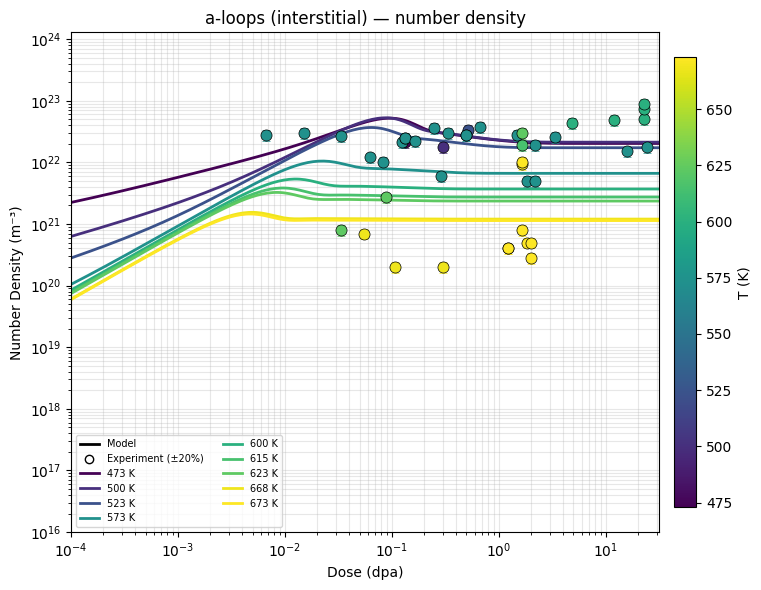

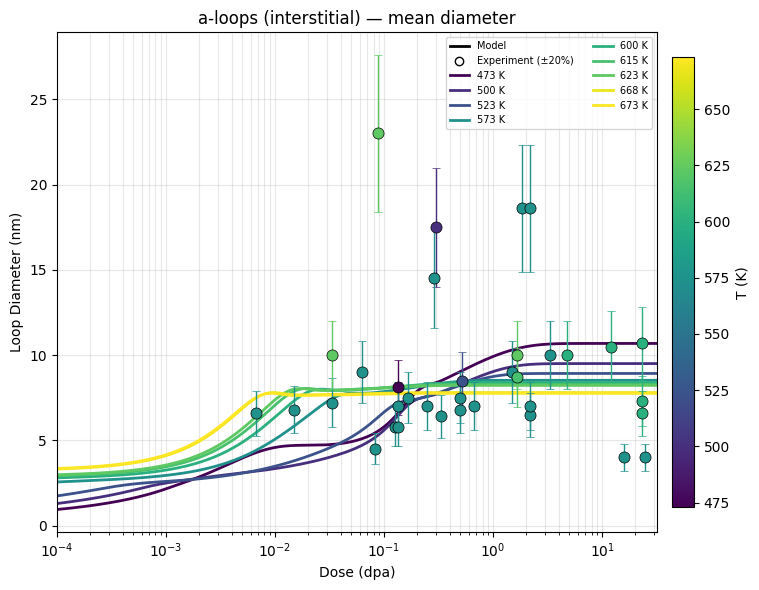

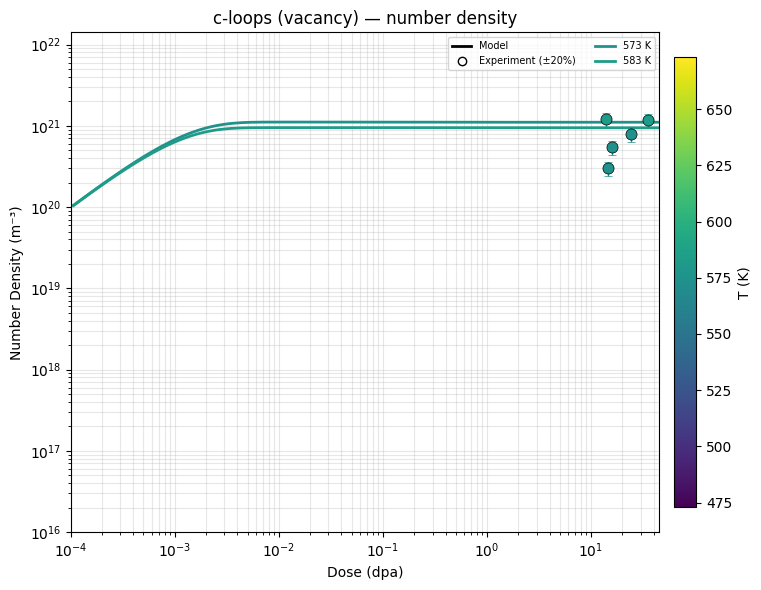

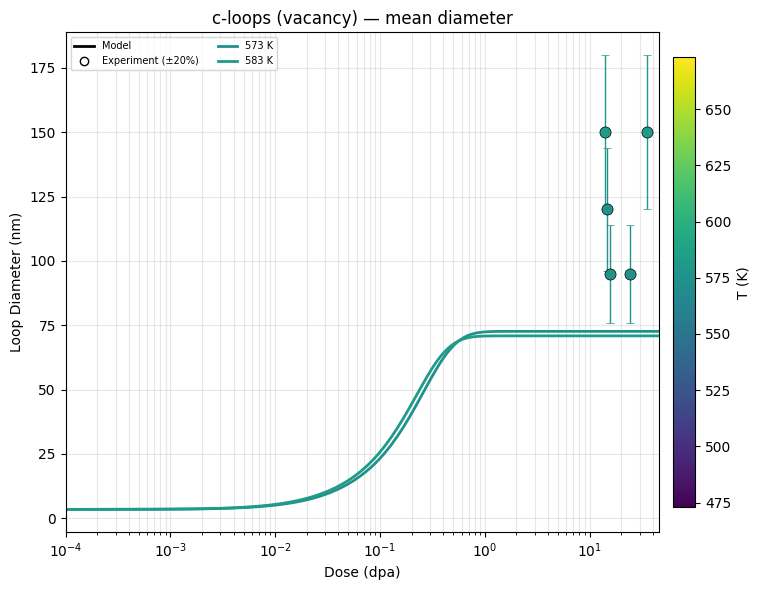

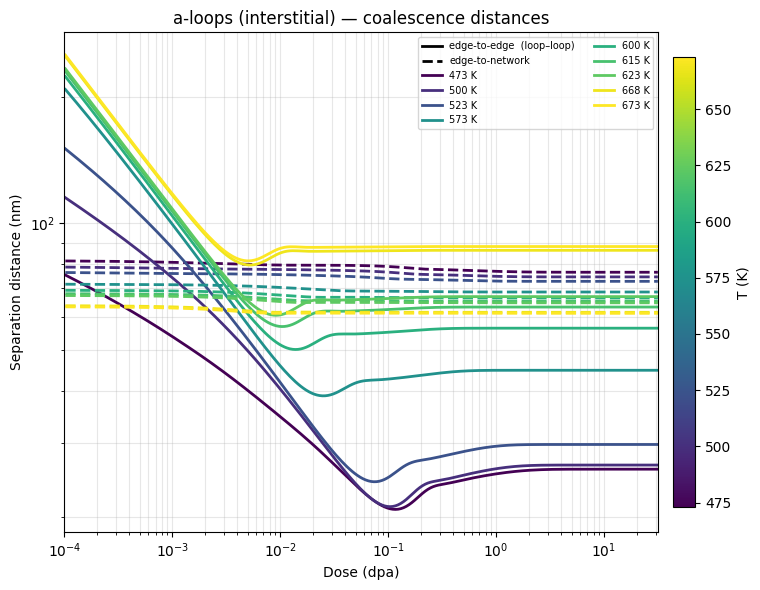

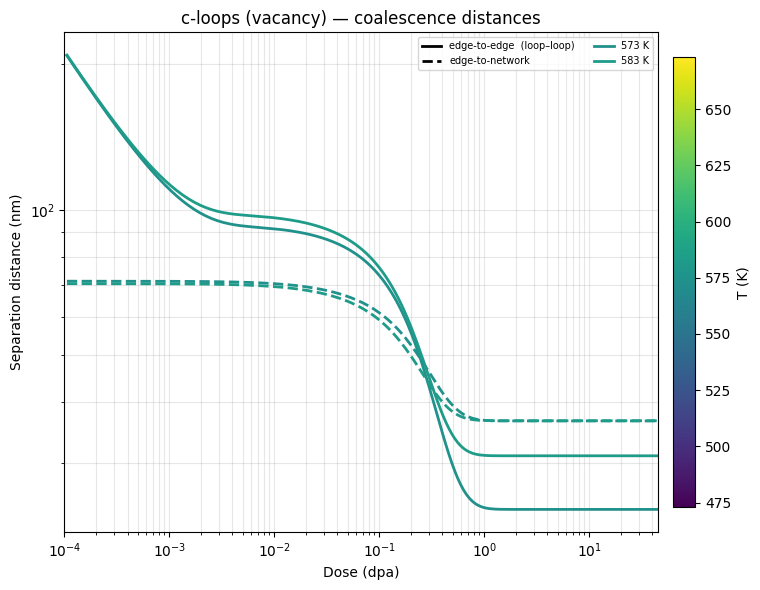

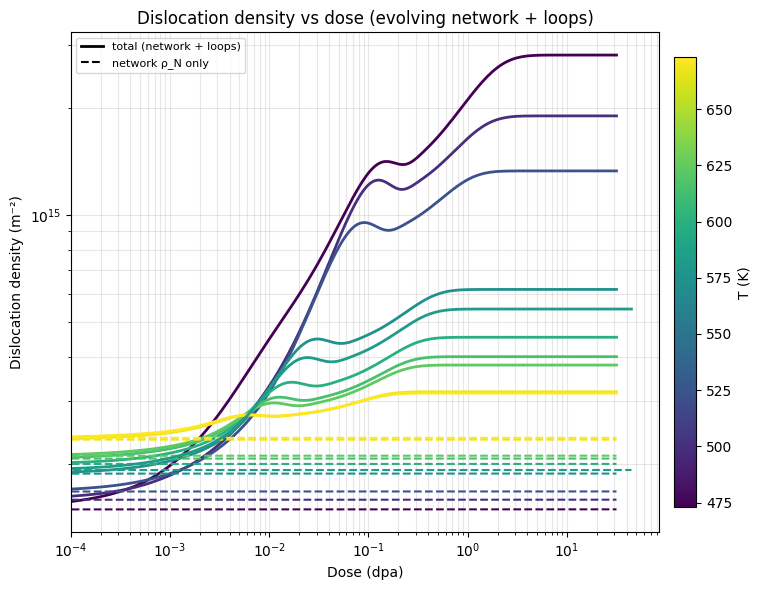


✓ Saved 7 figures to D:\GitHub\ZrClusterDynamics\ZrMicro\output\fiteval_20260622_144015_7959445
    • loops_A_density_vs_experiment.png
    • loops_A_diameter_vs_experiment.png
    • loops_C_density_vs_experiment.png
    • loops_C_diameter_vs_experiment.png
    • loops_A_coalescence_distances.png
    • loops_C_coalescence_distances.png
    • dislocation_density_vs_dose.png


In [3]:
# ZrMicro: OPTIMIZED MODEL vs EXPERIMENT  —  a-loops and c-loops SEPARATELY
# =========================================================================
# Using the optimized parameter set (`best_params`), integrate the model once
# per experimental temperature and overlay the measured data on the continuous
# model curves — plotted as SEPARATE figures for each loop family:
#
#   a-loops (interstitial) : N_A = (CiL+CaiL)/Omega , d_A = 2*<r> over (iL, aiL)
#   c-loops (vacancy)      : N_C = (CvL+CavL)/Omega , d_C = 2*<r> over (vL, avL)
#
# Six independent figures are produced:
#   1. a-loop number density vs dose            (+ experiment)
#   2. a-loop mean diameter  vs dose            (+ experiment)
#   3. c-loop number density vs dose            (+ experiment)
#   4. c-loop mean diameter  vs dose            (+ experiment)
#   5. a-loop COALESCENCE distances vs dose     (edge-to-edge & edge-to-network)
#   6. c-loop COALESCENCE distances vs dose     (edge-to-edge & edge-to-network)
#
# The coalescence figures expose the two geometric gates that drive the model's
# loop-merging mechanism (see ReactionRates.loop_coalescence_rates):
#   edge-to-edge    = N^(-1/3) - d          (loop-loop spacing minus diameter)
#   edge-to-network = rho_N^(-1/2) - d/2    (network spacing minus loop radius)
# As either distance collapses toward zero the corresponding coalescence channel
# (like-loop coarsening / loop-network absorption) switches on, saturating the
# loop number density and capping the loop size.
#
# Each temperature has its own colour (viridis); solid line = model, circles =
# experiment for that loop type at the measured doses (±20% error bars).
#
# Requires the parameter-identification cell above to have run (defines
# `best_params`, `_configure`, `_SIM`, `GROUPS`, `TARGETS`, `LOOP_TYPES`,
# `LOOP_LABEL`, `OPT_CONFIG`, `_DEVNULL`).

import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

ERR_FRAC = 0.20  # two-sided fractional error bar on the experimental data
# Integrate each temperature out to cover its experimental doses (+headroom),
# per loop type, so both the small-dose a-loop data and the high-dose c-loop
# data (up to ~35 dpa) are spanned.
DPA_MAX = {k: float(max(TARGETS[k]['dpa'].max() * 1.3, 1.0)) for k in LOOP_TYPES}


def model_curves_types(pdict, T, dpa_max, n_points=400):
    """Continuous optimized-model curves at temperature T for BOTH loop types.

    Returns (dose, {type: (N_L[1/m^3], d[nm])}, rho_N[1/m^2]) truncated to
    dpa_max, or None if the integration fails. rho_N is the EVOLVING network
    dislocation density array [1/m^2] (grows as loops join the network).
    Uses the SAME backend as the fit (C++ SUNDIALS by default — robust across
    the full temperature range), falling back to the scipy LSODA/BDF path when
    the C++ backend is unavailable.
    """
    _configure(pdict, T)
    rho_N = float(_SIM.input_data.material_params['rho'])   # T-dependent [m^-2]
    G = float(pdict.get('G', _SIM.input_data.material_params['G']))
    t_end = min(10.0 ** np.ceil(np.log10(max(dpa_max / G * 3.0, 1e6))), 1e10)
    r = None
    if OPT_CONFIG.get('backend', 'python') == 'cpp':
        solver_config = {'t_begin': 1e-1, 't_end': t_end, 'n_points': n_points,
                         'rtol': OPT_CONFIG['rtol'], 'atol': OPT_CONFIG['atol'],
                         'log_time': True, 'solver_method': _FIT_SOLVER_METHOD}
        with _DEVNULL:
            r = run_cpp_solver(_SIM, solver_config, base_dir=BASE_DIR)
    if r is None:   # python backend, or C++ failed -> scipy fallback
        for _method in ('LSODA', 'BDF'):
            with _DEVNULL:
                r = _SIM.run_simulation(t_begin=1e-1, t_end=t_end, n_points=n_points,
                                        method=_method, rtol=OPT_CONFIG['rtol'],
                                        atol=OPT_CONFIG['atol'], log_time=True)
            if r is not None:
                break
    if r is None:
        return None
    c, ls = r['concentrations'], r['loop_sizes']
    Om = _SIM.input_data.physical_props['Omega']
    dose = G * r['time']
    Na, Nc = c['CiL'] + c['CaiL'], c['CvL'] + c['CavL']
    d_A = 2.0 * (c['CiL'] * ls['r_iL'] + c['CaiL'] * ls['r_aiL']) / np.maximum(Na, 1e-30) * 1e9
    d_C = 2.0 * (c['CvL'] * ls['r_vL'] + c['CavL'] * ls['r_avL']) / np.maximum(Nc, 1e-30) * 1e9
    rho_N_evol = np.asarray(r.get('rho_N', np.full_like(dose, rho_N)))
    # Loop dislocation line density [m^-2] = 2*pi * sum_k r_k * N_k, and the
    # TOTAL dislocation density = evolving network + loops.
    rho_loops = 2.0 * np.pi * (
        c['CiL'] * ls['r_iL'] + c['CaiL'] * ls['r_aiL'] +
        c['CvL'] * ls['r_vL'] + c['CavL'] * ls['r_avL']) / Om
    rho_total = rho_N_evol + rho_loops
    m = dose <= dpa_max
    return (dose[m], {'A': (np.maximum(Na[m] / Om, 1e-30), d_A[m]),
                      'C': (np.maximum(Nc[m] / Om, 1e-30), d_C[m])},
            rho_N_evol[m], rho_total[m])


# -- Run the optimized model once per (loop type, temperature) ----------------
print("=" * 72)
print("OPTIMIZED MODEL vs EXPERIMENT  —  a-loops and c-loops separately")
print("=" * 72)
CURVES = {k: {} for k in LOOP_TYPES}     # CURVES[type][T] = (dose, N_L, d, rho_N)
for k in LOOP_TYPES:
    for T in GROUPS[k]:
        crv = model_curves_types(best_params, T, DPA_MAX[k])
        if crv is None:
            print(f"⚠️  {LOOP_LABEL[k]} {T:.0f}K: integration failed — skipped")
            continue
        dose, series, rho_N, rho_total = crv
        CURVES[k][T] = (dose, series[k][0], series[k][1], rho_N, rho_total)
    print(f"✓ {LOOP_LABEL[k]}: integrated {len(CURVES[k])}/{len(GROUPS[k])} "
          f"temperatures ({', '.join(f'{T:.0f}K' for T in sorted(CURVES[k]))})")

# Shared temperature colour map over ALL temperatures appearing in either set
_all_T = sorted(set(GROUPS['A']) | set(GROUPS['C']))
_norm  = mcolors.Normalize(vmin=min(_all_T), vmax=max(_all_T))
_cmap  = plt.cm.viridis
_tcol  = lambda T: _cmap(_norm(T))
_dpa_lo = 1e-4           # left edge of the dose axis
_N_L_lo = 1e16           # bottom edge of the number-density axis
_legend = [Line2D([0], [0], color='k', lw=2, label='Model'),
           Line2D([0], [0], marker='o', color='k', ls='none',
                  mfc='w', mec='k', label='Experiment (±20%)')]


def _temp_legend(ax, k, extra=None):
    """Per-figure legend: model/experiment proxies (or `extra`) + temperature key."""
    base = extra if extra is not None else _legend
    handles = base + [Line2D([0], [0], color=_tcol(T), lw=2, label=f'{T:.0f} K')
                      for T in sorted(GROUPS[k])]
    ax.legend(handles=handles, loc='best', fontsize=7, ncol=2)


def _add_tbar(fig, ax):
    sm = plt.cm.ScalarMappable(norm=_norm, cmap=_cmap); sm.set_array([])
    fig.colorbar(sm, ax=ax, label='T (K)', shrink=0.9, pad=0.02)


FIGS = []   # (fig, filename) pairs saved at the end


# -- Figures 1-4: number density and mean diameter, one figure per panel ------
for k in LOOP_TYPES:
    xhi = DPA_MAX[k]

    # --- number density (log-log) -------------------------------------------
    figN, axN = plt.subplots(figsize=(8, 6))
    for T in GROUPS[k]:
        if T in CURVES[k]:
            dose, N_L, _, _, _ = CURVES[k][T]
            sel = dose >= _dpa_lo
            axN.loglog(dose[sel], N_L[sel], '-', color=_tcol(T), lw=2)
        g = GROUPS[k][T]
        ge = g[g['N_L'].notna() & (g['dpa'] <= xhi)]
        axN.errorbar(ge['dpa'], ge['N_L'], yerr=ERR_FRAC * ge['N_L'],
                     fmt='o', ms=8, color=_tcol(T), mec='k', mew=0.5,
                     ecolor=_tcol(T), elinewidth=1, capsize=3, zorder=5)
    axN.set(xlabel='Dose (dpa)', ylabel='Number Density (m⁻³)',
            title=f'{LOOP_LABEL[k]} — number density', xlim=(_dpa_lo, xhi))
    axN.set_ylim(bottom=_N_L_lo)
    axN.grid(True, which='both', alpha=0.3)
    _temp_legend(axN, k)
    _add_tbar(figN, axN)
    figN.tight_layout()
    FIGS.append((figN, f'loops_{k}_density_vs_experiment.png'))

    # --- mean diameter (semilog-x) ------------------------------------------
    figD, axD = plt.subplots(figsize=(8, 6))
    for T in GROUPS[k]:
        if T in CURVES[k]:
            dose, _, d_mean, _, _ = CURVES[k][T]
            sel = dose >= _dpa_lo
            axD.semilogx(dose[sel], d_mean[sel], '-', color=_tcol(T), lw=2)
        g = GROUPS[k][T]
        ge = g[g['d'].notna() & (g['dpa'] <= xhi)]
        axD.errorbar(ge['dpa'], ge['d'], yerr=ERR_FRAC * ge['d'],
                     fmt='o', ms=8, color=_tcol(T), mec='k', mew=0.5,
                     ecolor=_tcol(T), elinewidth=1, capsize=3, zorder=5)
    axD.set(xlabel='Dose (dpa)', ylabel='Loop Diameter (nm)',
            title=f'{LOOP_LABEL[k]} — mean diameter', xlim=(_dpa_lo, xhi))
    axD.grid(True, which='both', alpha=0.3)
    _temp_legend(axD, k)
    _add_tbar(figD, axD)
    figD.tight_layout()
    FIGS.append((figD, f'loops_{k}_diameter_vs_experiment.png'))


# -- Figures 5-6: coalescence distances vs dose, one figure per loop family ---
# Two distances per temperature trace how each coalescence gate closes:
#   edge-to-edge    (solid)  = N^(-1/3)    - d     loop-loop  contact -> coarsening
#   edge-to-network (dashed) = rho_N^(-1/2) - d/2  loop edge reaches the network
# Both are plotted in nm on a log-log axis; the curves bending down to a small
# floor mark where coalescence saturates the density/size.
_coal_proxy = [Line2D([0], [0], color='k', lw=2, ls='-',  label='edge-to-edge  (loop–loop)'),
               Line2D([0], [0], color='k', lw=2, ls='--', label='edge-to-network')]
for k in LOOP_TYPES:
    xhi = DPA_MAX[k]
    figC, axC = plt.subplots(figsize=(8, 6))
    for T in GROUPS[k]:
        if T not in CURVES[k]:
            continue
        dose, N_L, d, rho_N, _ = CURVES[k][T]
        sel = dose >= _dpa_lo
        ds, Ns, dd, rhos = dose[sel], N_L[sel], d[sel], np.asarray(rho_N)[sel]
        spacing_LL = Ns ** (-1.0 / 3.0) * 1e9        # loop-loop spacing  [nm]
        spacing_LN = rhos ** (-0.5) * 1e9            # loop-network spacing [nm] (evolving)
        edge_edge = spacing_LL - dd                  # edge-to-edge distance [nm]
        edge_net  = spacing_LN - dd / 2.0            # edge-to-network distance [nm]
        col = _tcol(T)
        axC.loglog(ds, np.maximum(edge_edge, 1e-3), '-',  color=col, lw=2)
        axC.loglog(ds, np.maximum(edge_net,  1e-3), '--', color=col, lw=2)
    axC.set(xlabel='Dose (dpa)', ylabel='Separation distance (nm)',
            title=f'{LOOP_LABEL[k]} — coalescence distances',
            xlim=(_dpa_lo, xhi))
    axC.grid(True, which='both', alpha=0.3)
    _temp_legend(axC, k, extra=_coal_proxy)
    _add_tbar(figC, axC)
    figC.tight_layout()
    FIGS.append((figC, f'loops_{k}_coalescence_distances.png'))


# ── Figure 7: evolving network dislocation density rho_N vs dose ──────────────
# rho_N now grows as loops are absorbed into the network (loop-network
# coalescence) and recovers first-order toward the grown-in seed, so it
# saturates. One curve per temperature (whichever loop family integrated it).
figR, axR = plt.subplots(figsize=(8, 6))
_seen_T = set()
for k in LOOP_TYPES:
    for T in sorted(GROUPS[k]):
        if T in _seen_T or T not in CURVES[k]:
            continue
        _seen_T.add(T)
        dose, _, _, rho_N, rho_total = CURVES[k][T]
        sel = dose >= _dpa_lo
        axR.loglog(dose[sel], np.asarray(rho_total)[sel], '-',  color=_tcol(T), lw=2)
        axR.loglog(dose[sel], np.asarray(rho_N)[sel],     '--', color=_tcol(T), lw=1.5)
_disloc_proxy = [Line2D([0], [0], color='k', lw=2,   ls='-',  label='total (network + loops)'),
                 Line2D([0], [0], color='k', lw=1.5, ls='--', label='network ρ_N only')]
axR.legend(handles=_disloc_proxy, loc='best', fontsize=8)
axR.set(xlabel='Dose (dpa)', ylabel='Dislocation density (m⁻²)',
        title='Dislocation density vs dose (evolving network + loops)', xlim=(_dpa_lo, None))
axR.grid(True, which='both', alpha=0.3)
_add_tbar(figR, axR)
figR.tight_layout()
FIGS.append((figR, 'dislocation_density_vs_dose.png'))

plt.show()


# -- Save every figure alongside the fit outputs ------------------------------
try:
    import subprocess
    _hash = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'],
                           capture_output=True, text=True,
                           cwd=str(BASE_DIR)).stdout.strip() or 'nogit'
except Exception:
    _hash = 'nogit'
_eval_dir = OUTPUT_DIR / f"fiteval_{datetime.now():%Y%m%d_%H%M%S}_{_hash}"
_eval_dir.mkdir(parents=True, exist_ok=True)
for _f, _name in FIGS:
    _f.savefig(_eval_dir / _name, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved {len(FIGS)} figures to {_eval_dir}")
for _, _name in FIGS:
    print(f"    • {_name}")


✓ Successfully imported ZrMicro modules
✓ Input file found: D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
✓ Output directory: D:\GitHub\ZrClusterDynamics\ZrMicro\output

ZrMicro: Cluster Dynamics Simulation for Zirconium
Solver backend  : cpp
Time span       : 1.0e-01 → 1.0e+09 s  (200 points)
Output directory: D:\GitHub\ZrClusterDynamics\ZrMicro\output

INITIALIZING SIMULATION
Initializing ZrMicro simulation...
Loading input data from D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx...
InputData: Attempting to load D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
✓ File exists: D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
Reading Excel file: D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
✓ Successfully loaded input data from Excel file
  DAD bias: Z_i_a=1.175 Z_v_a=0.832 Z_i_c=0.825 Z_v_c=1.168
Derived f: 0.051779227125179204, f_a: 0.3678528180834528, f_na: 0.6321471819165472
✓ Derived p

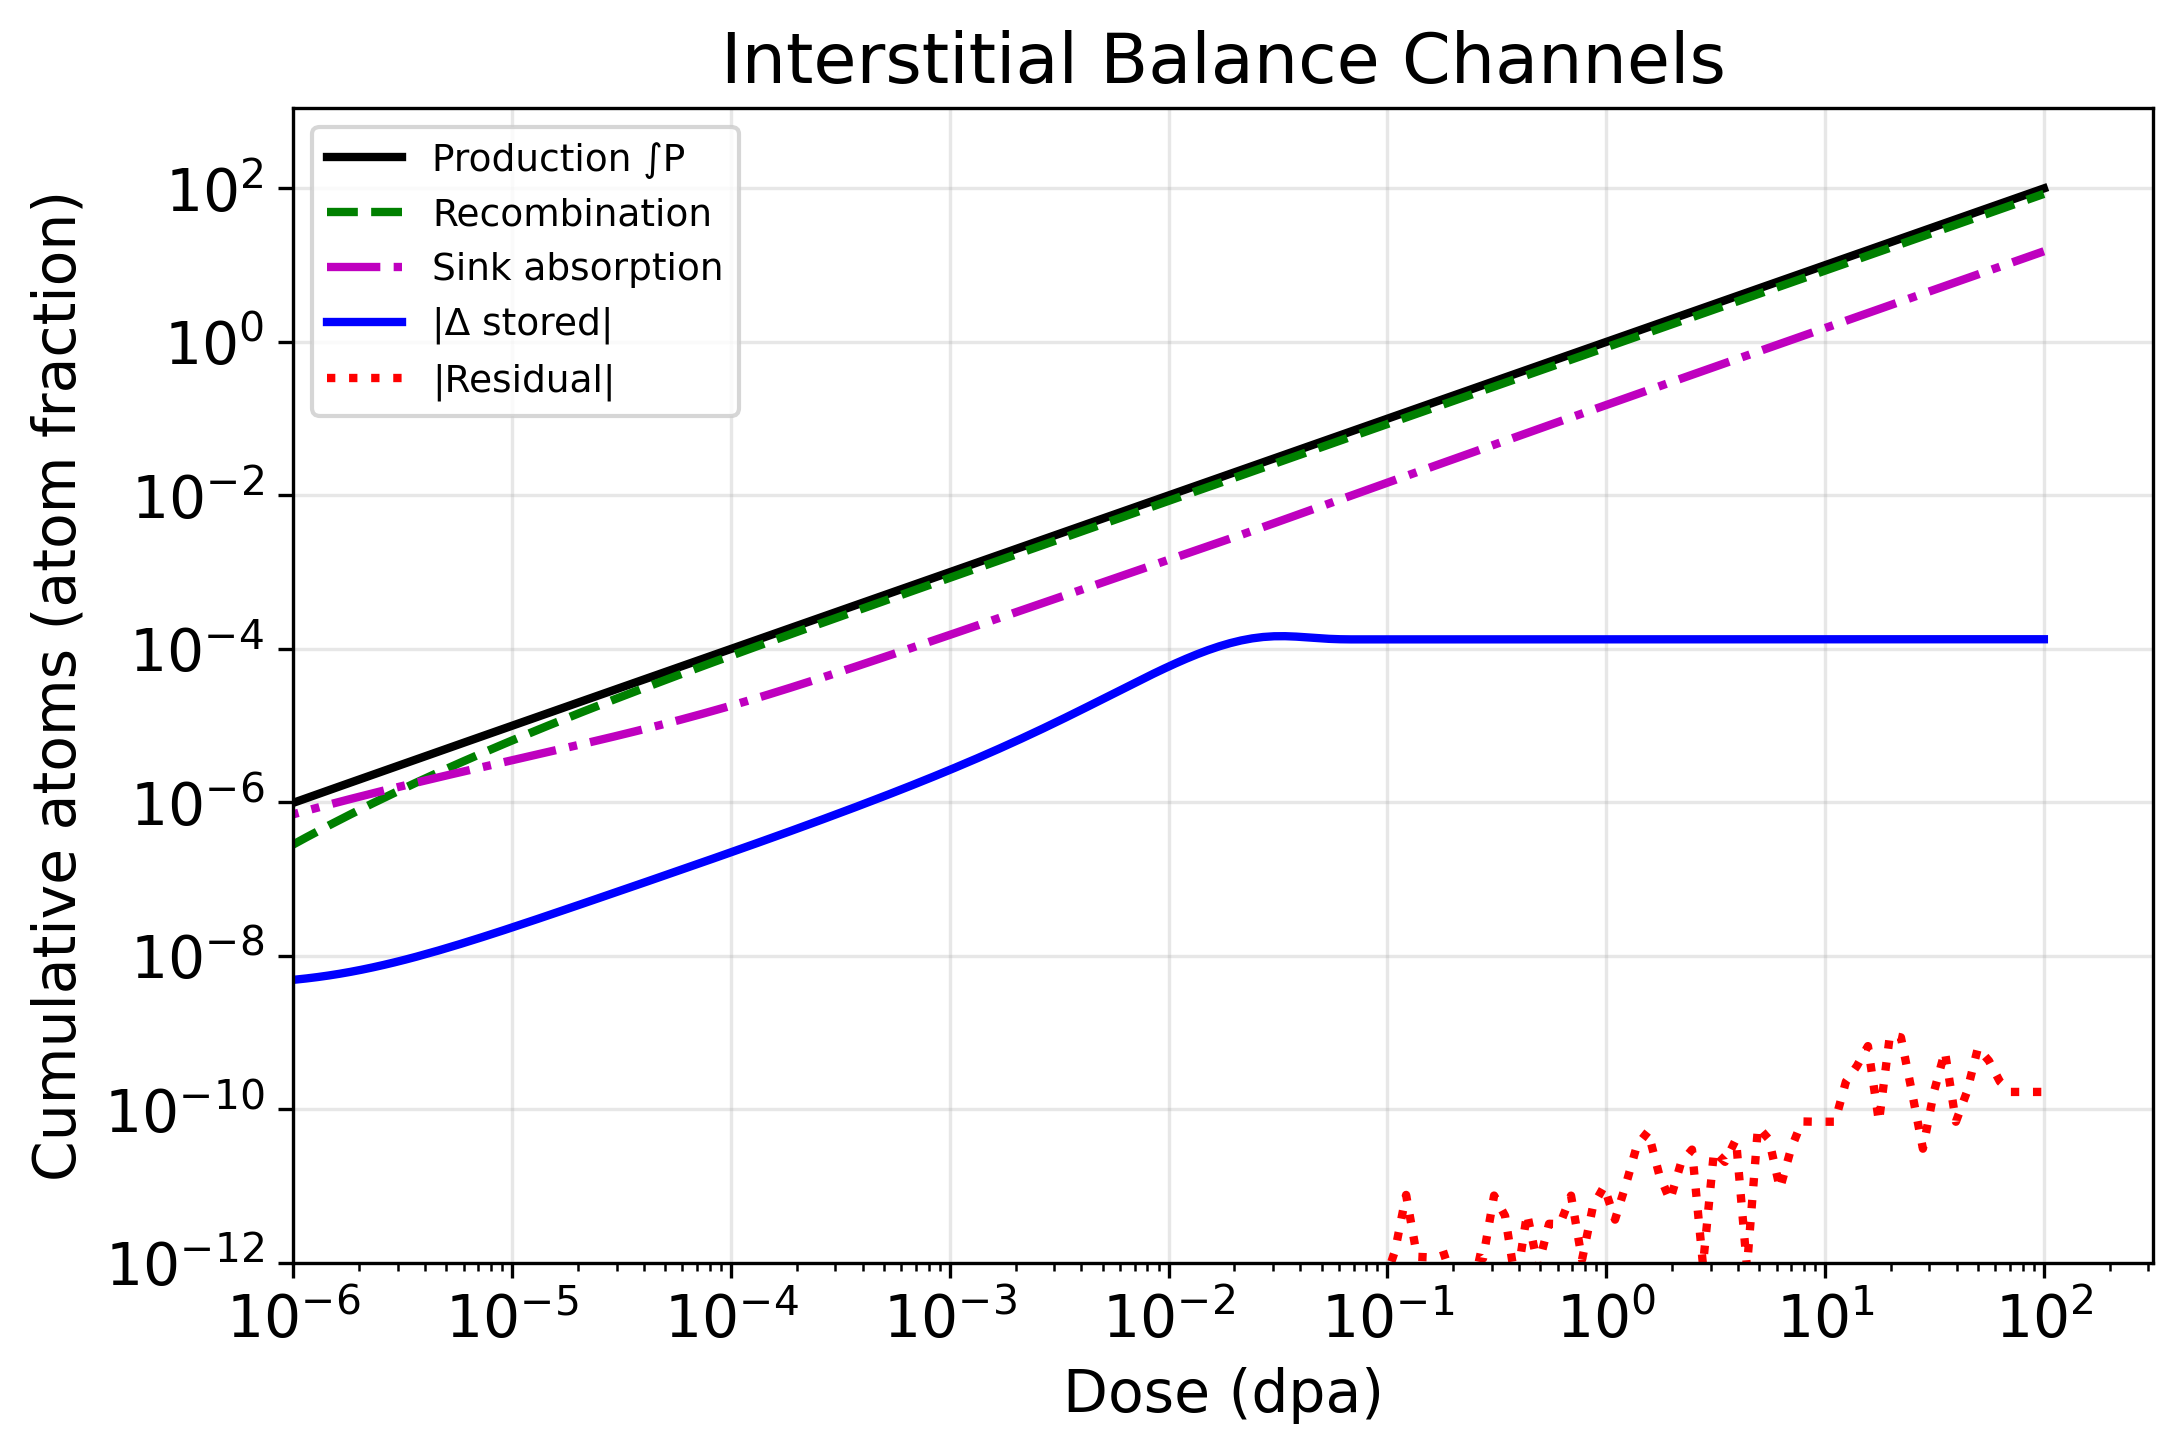


conservation_channels_v.png


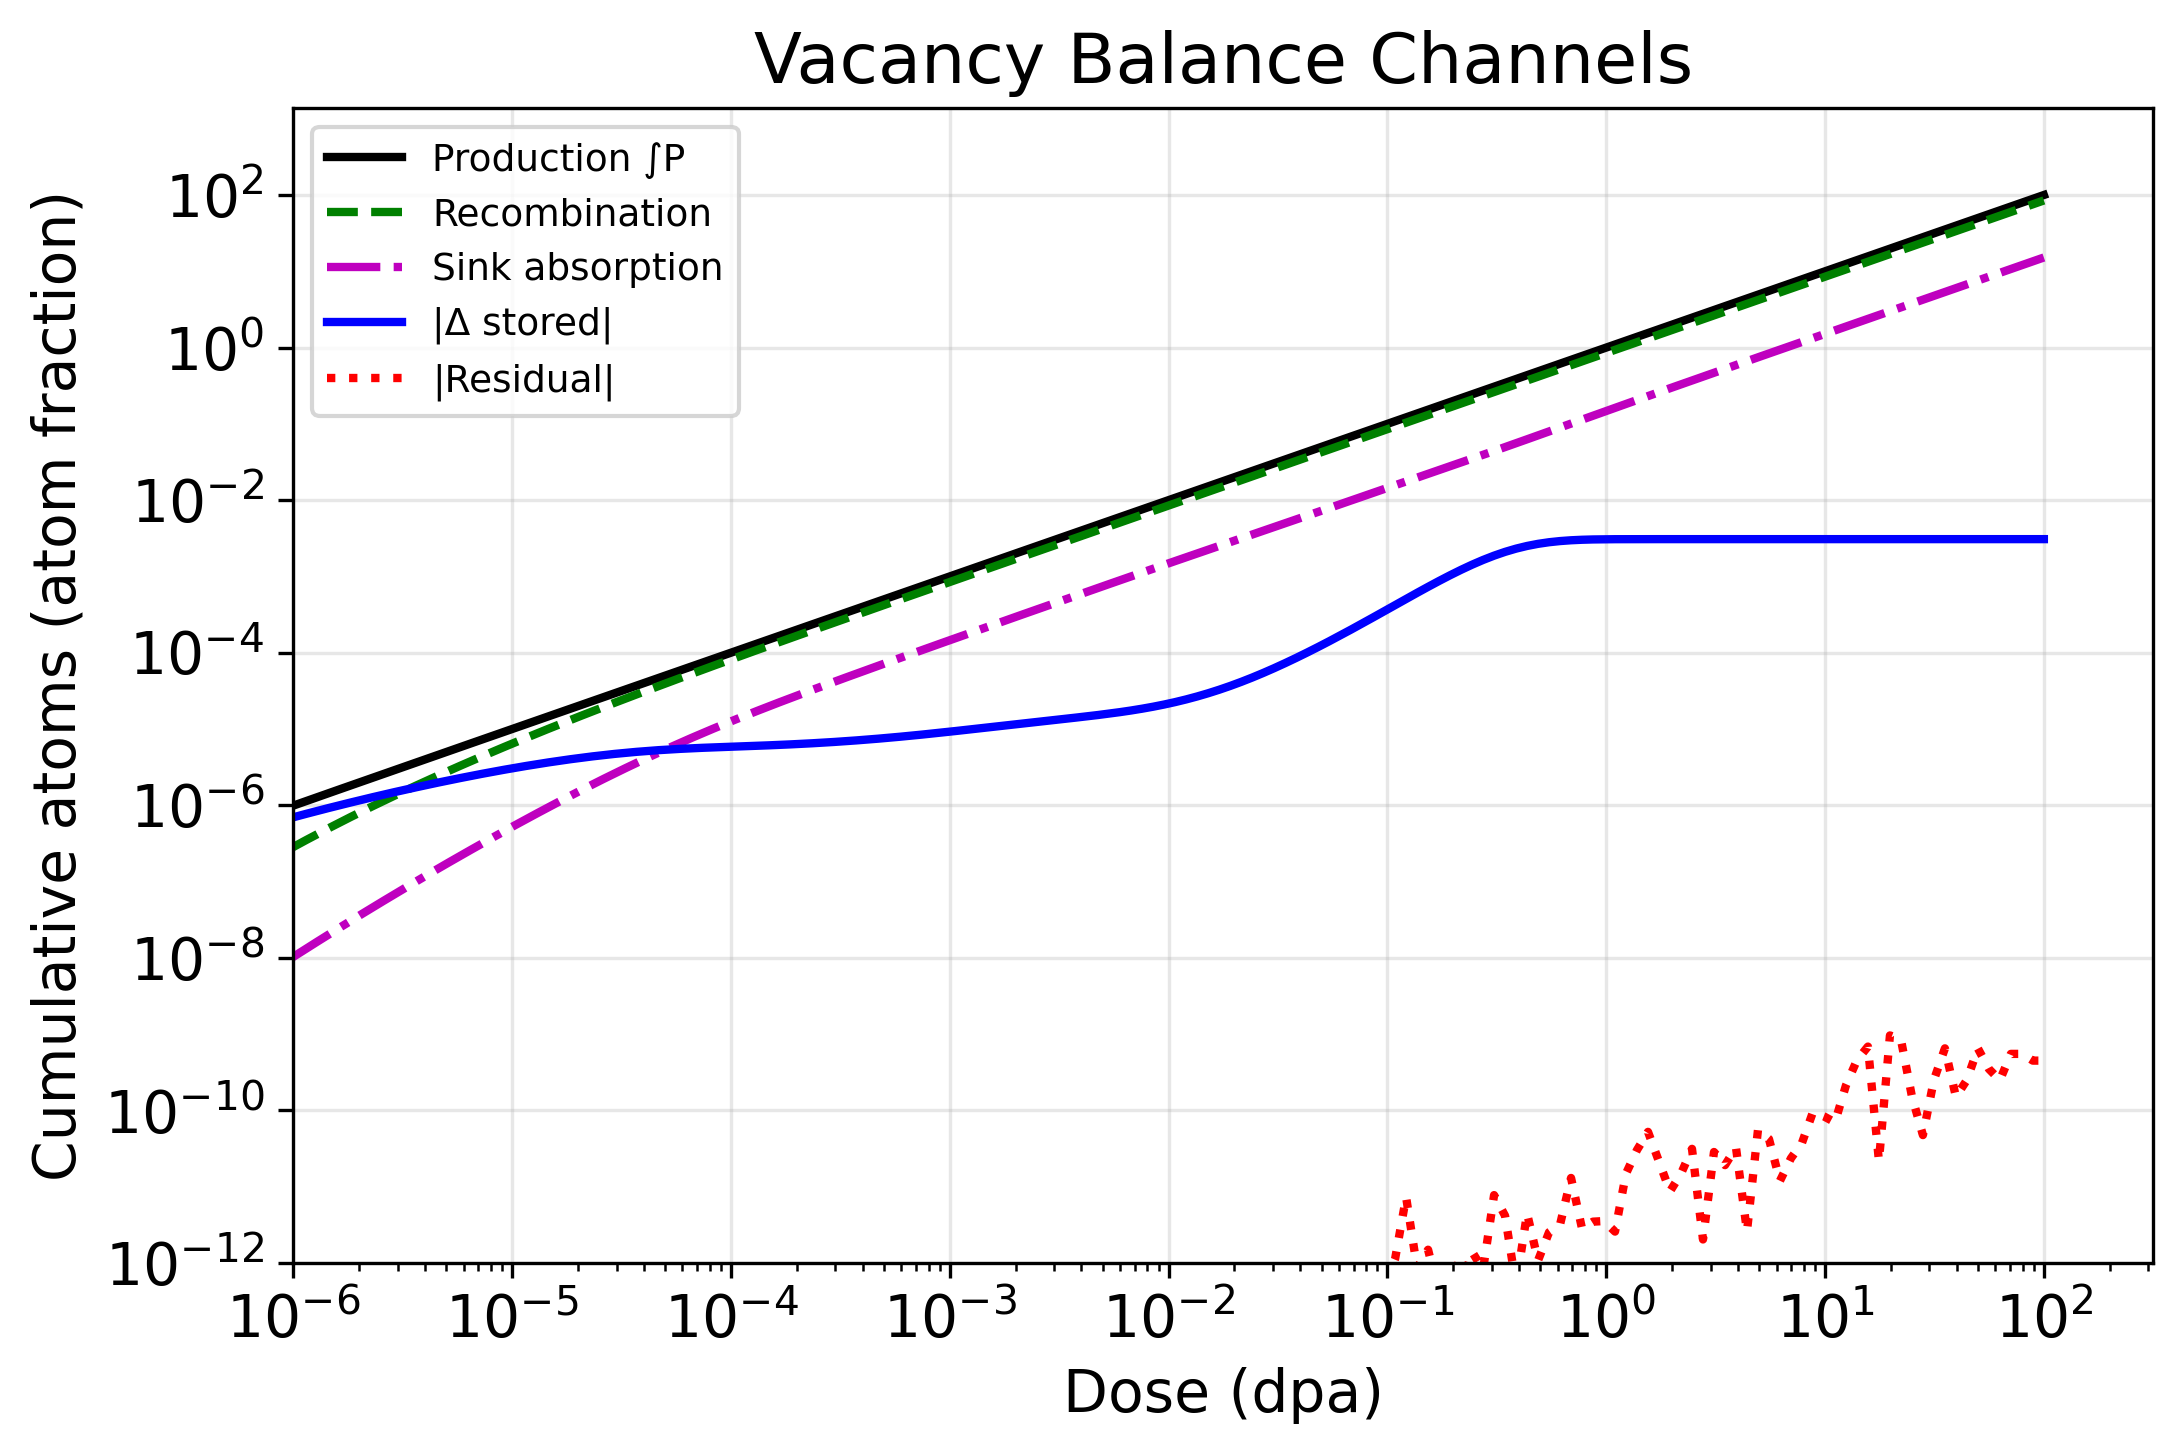


conservation_error.png


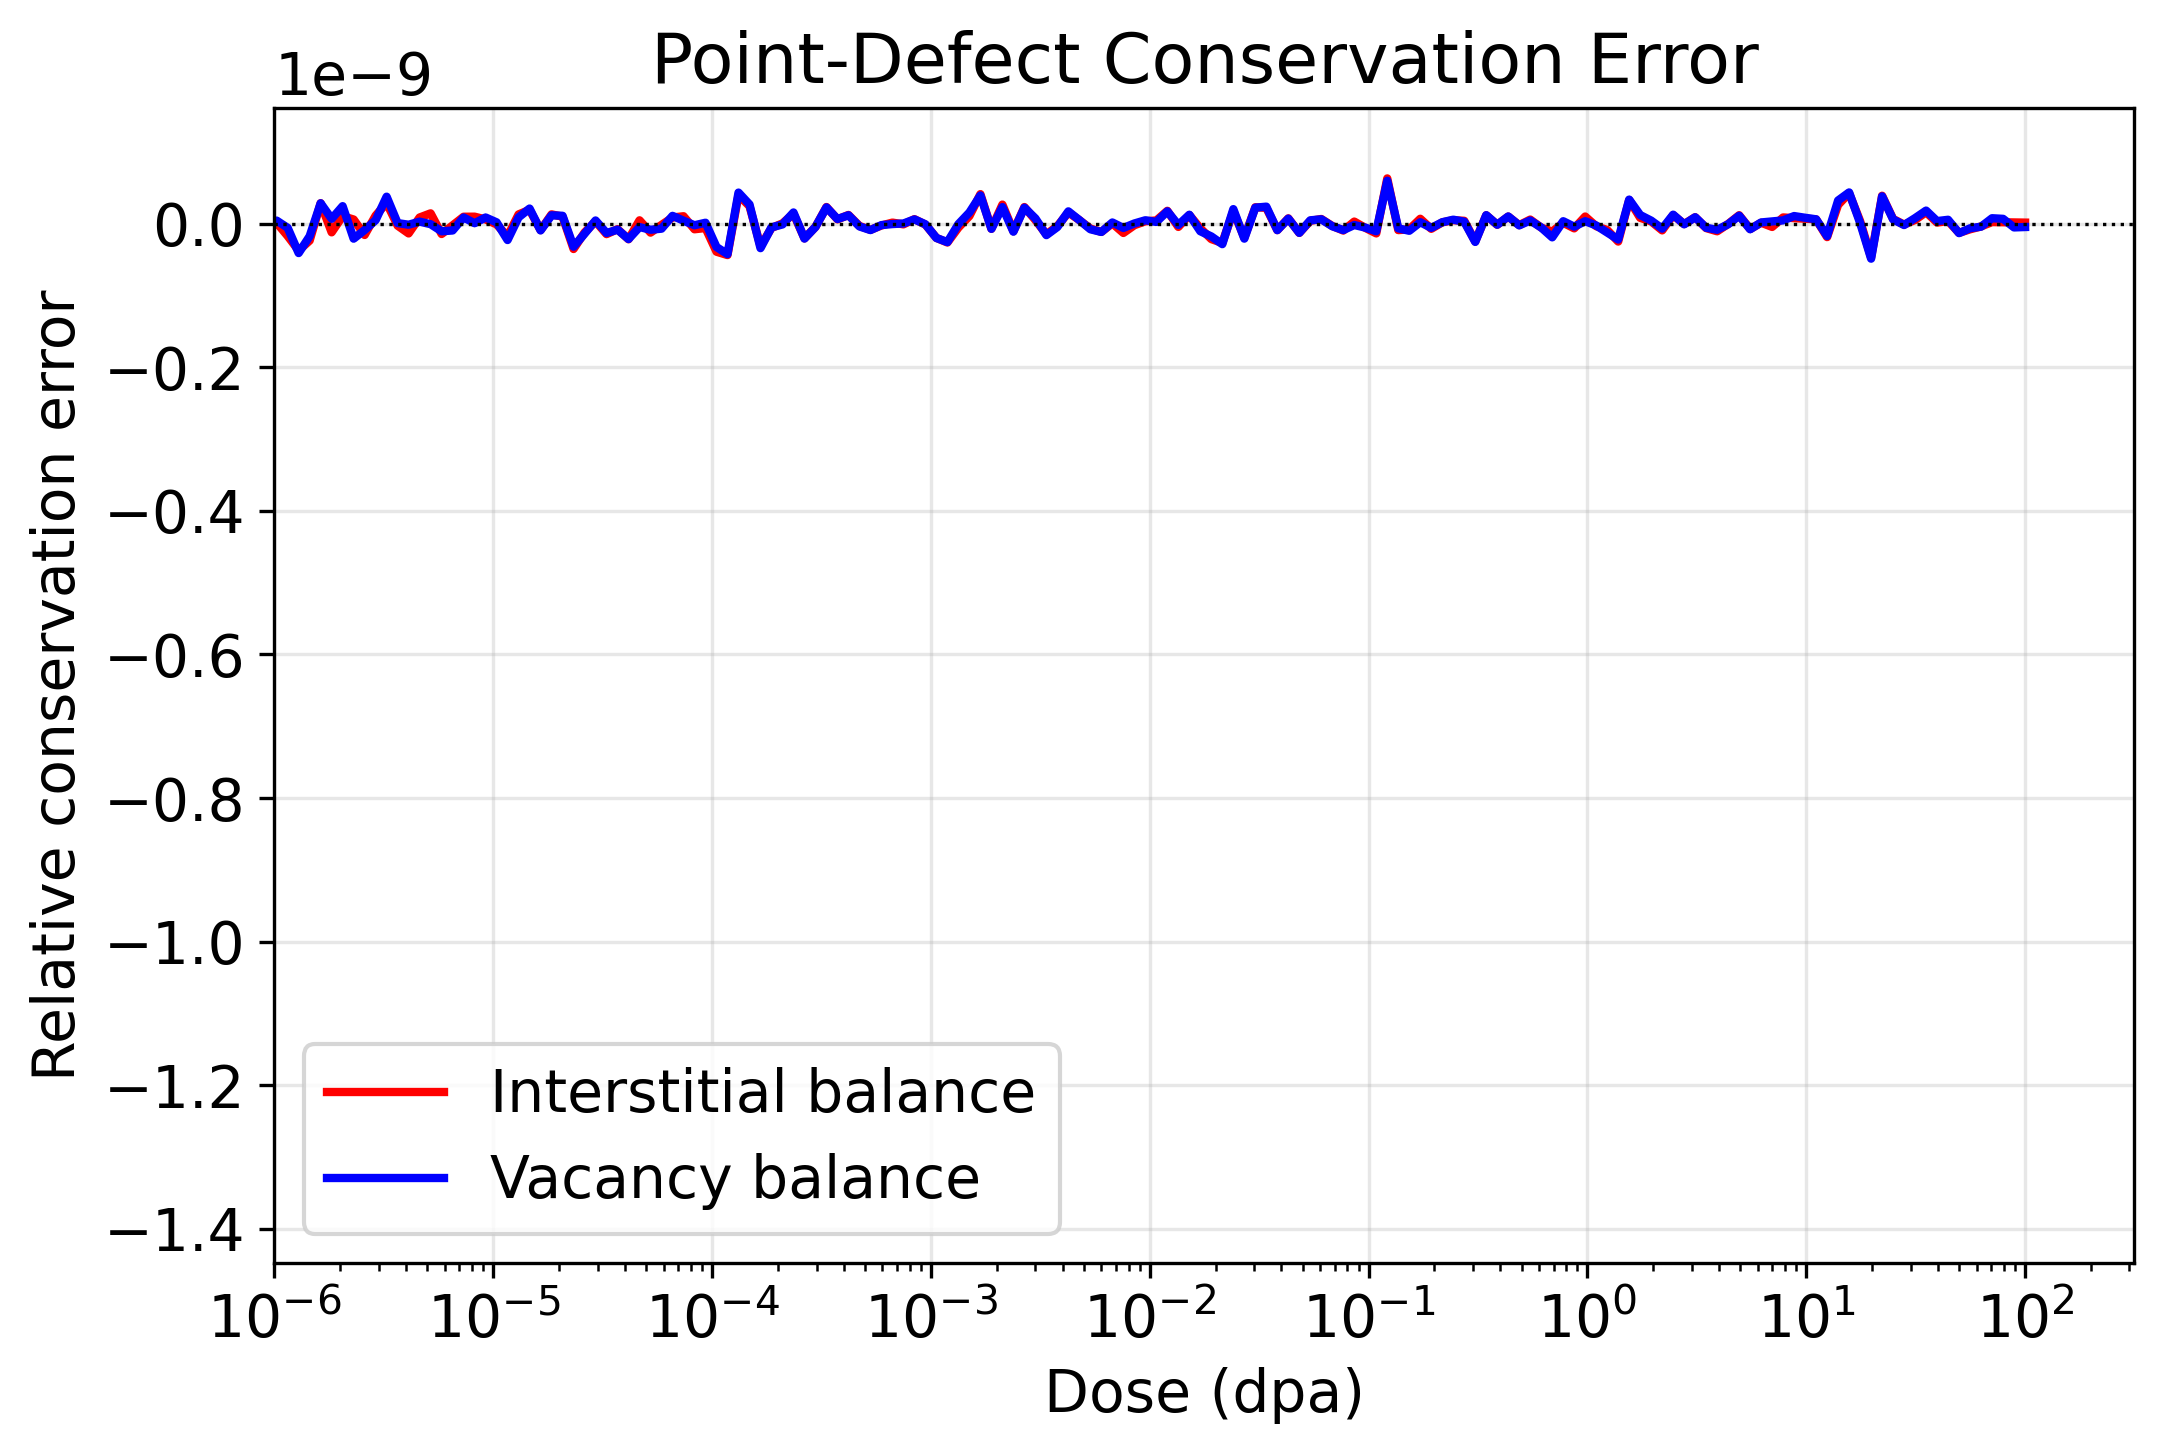


defect_imbalance.png


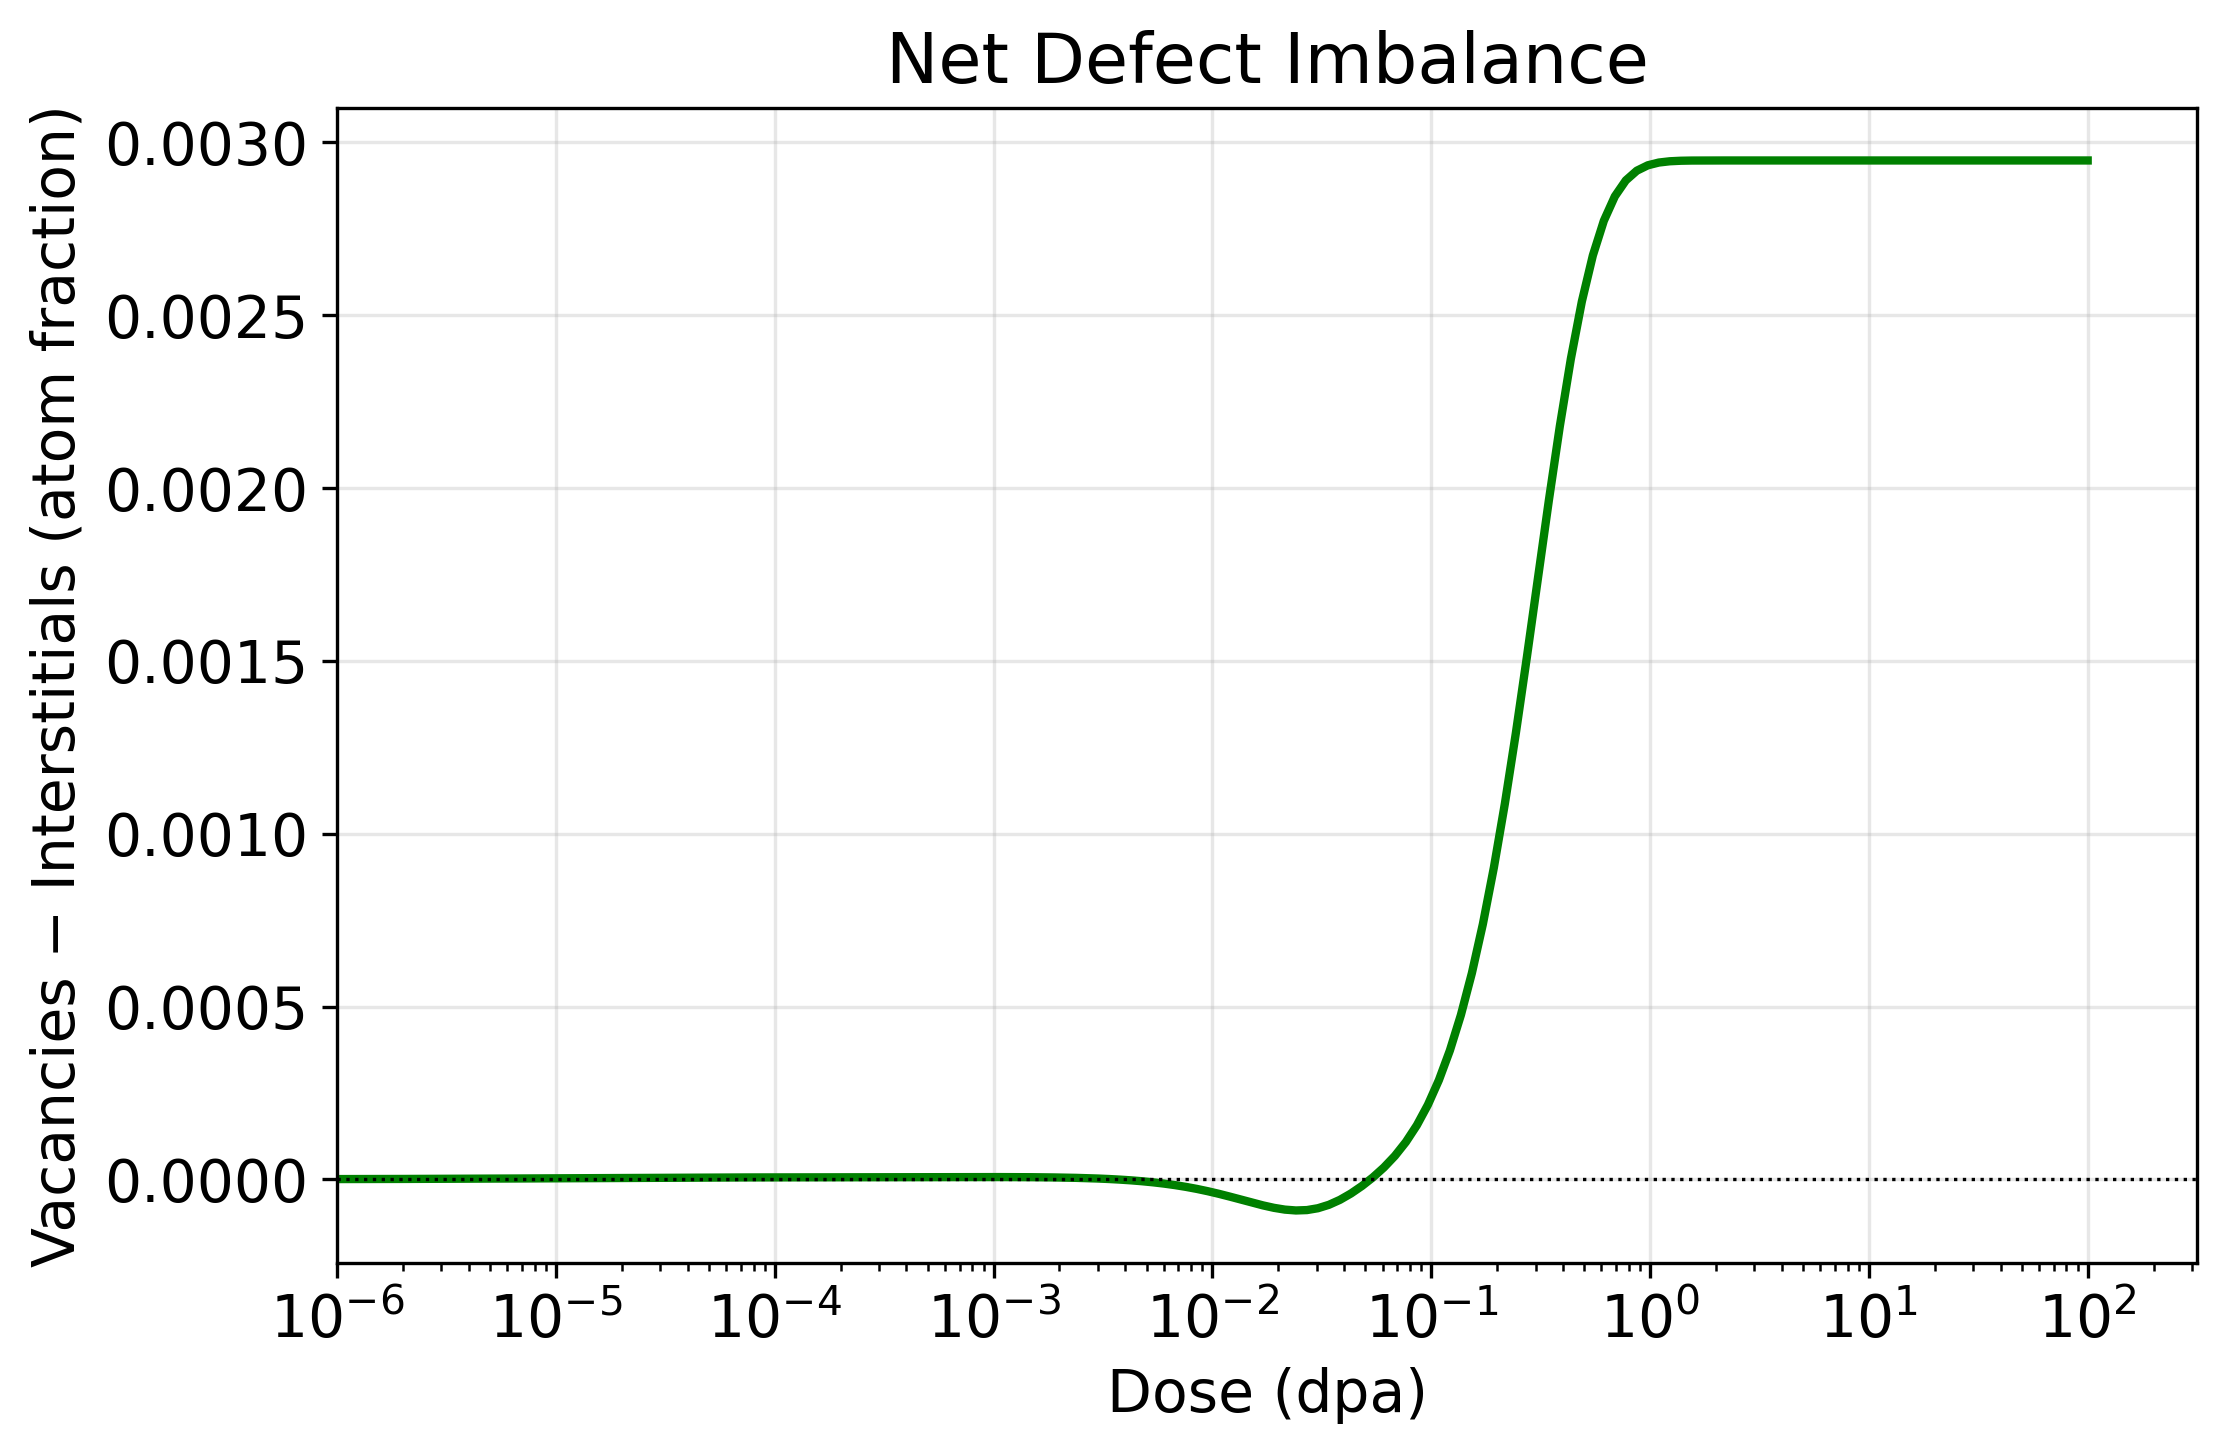


flux_evolution.png


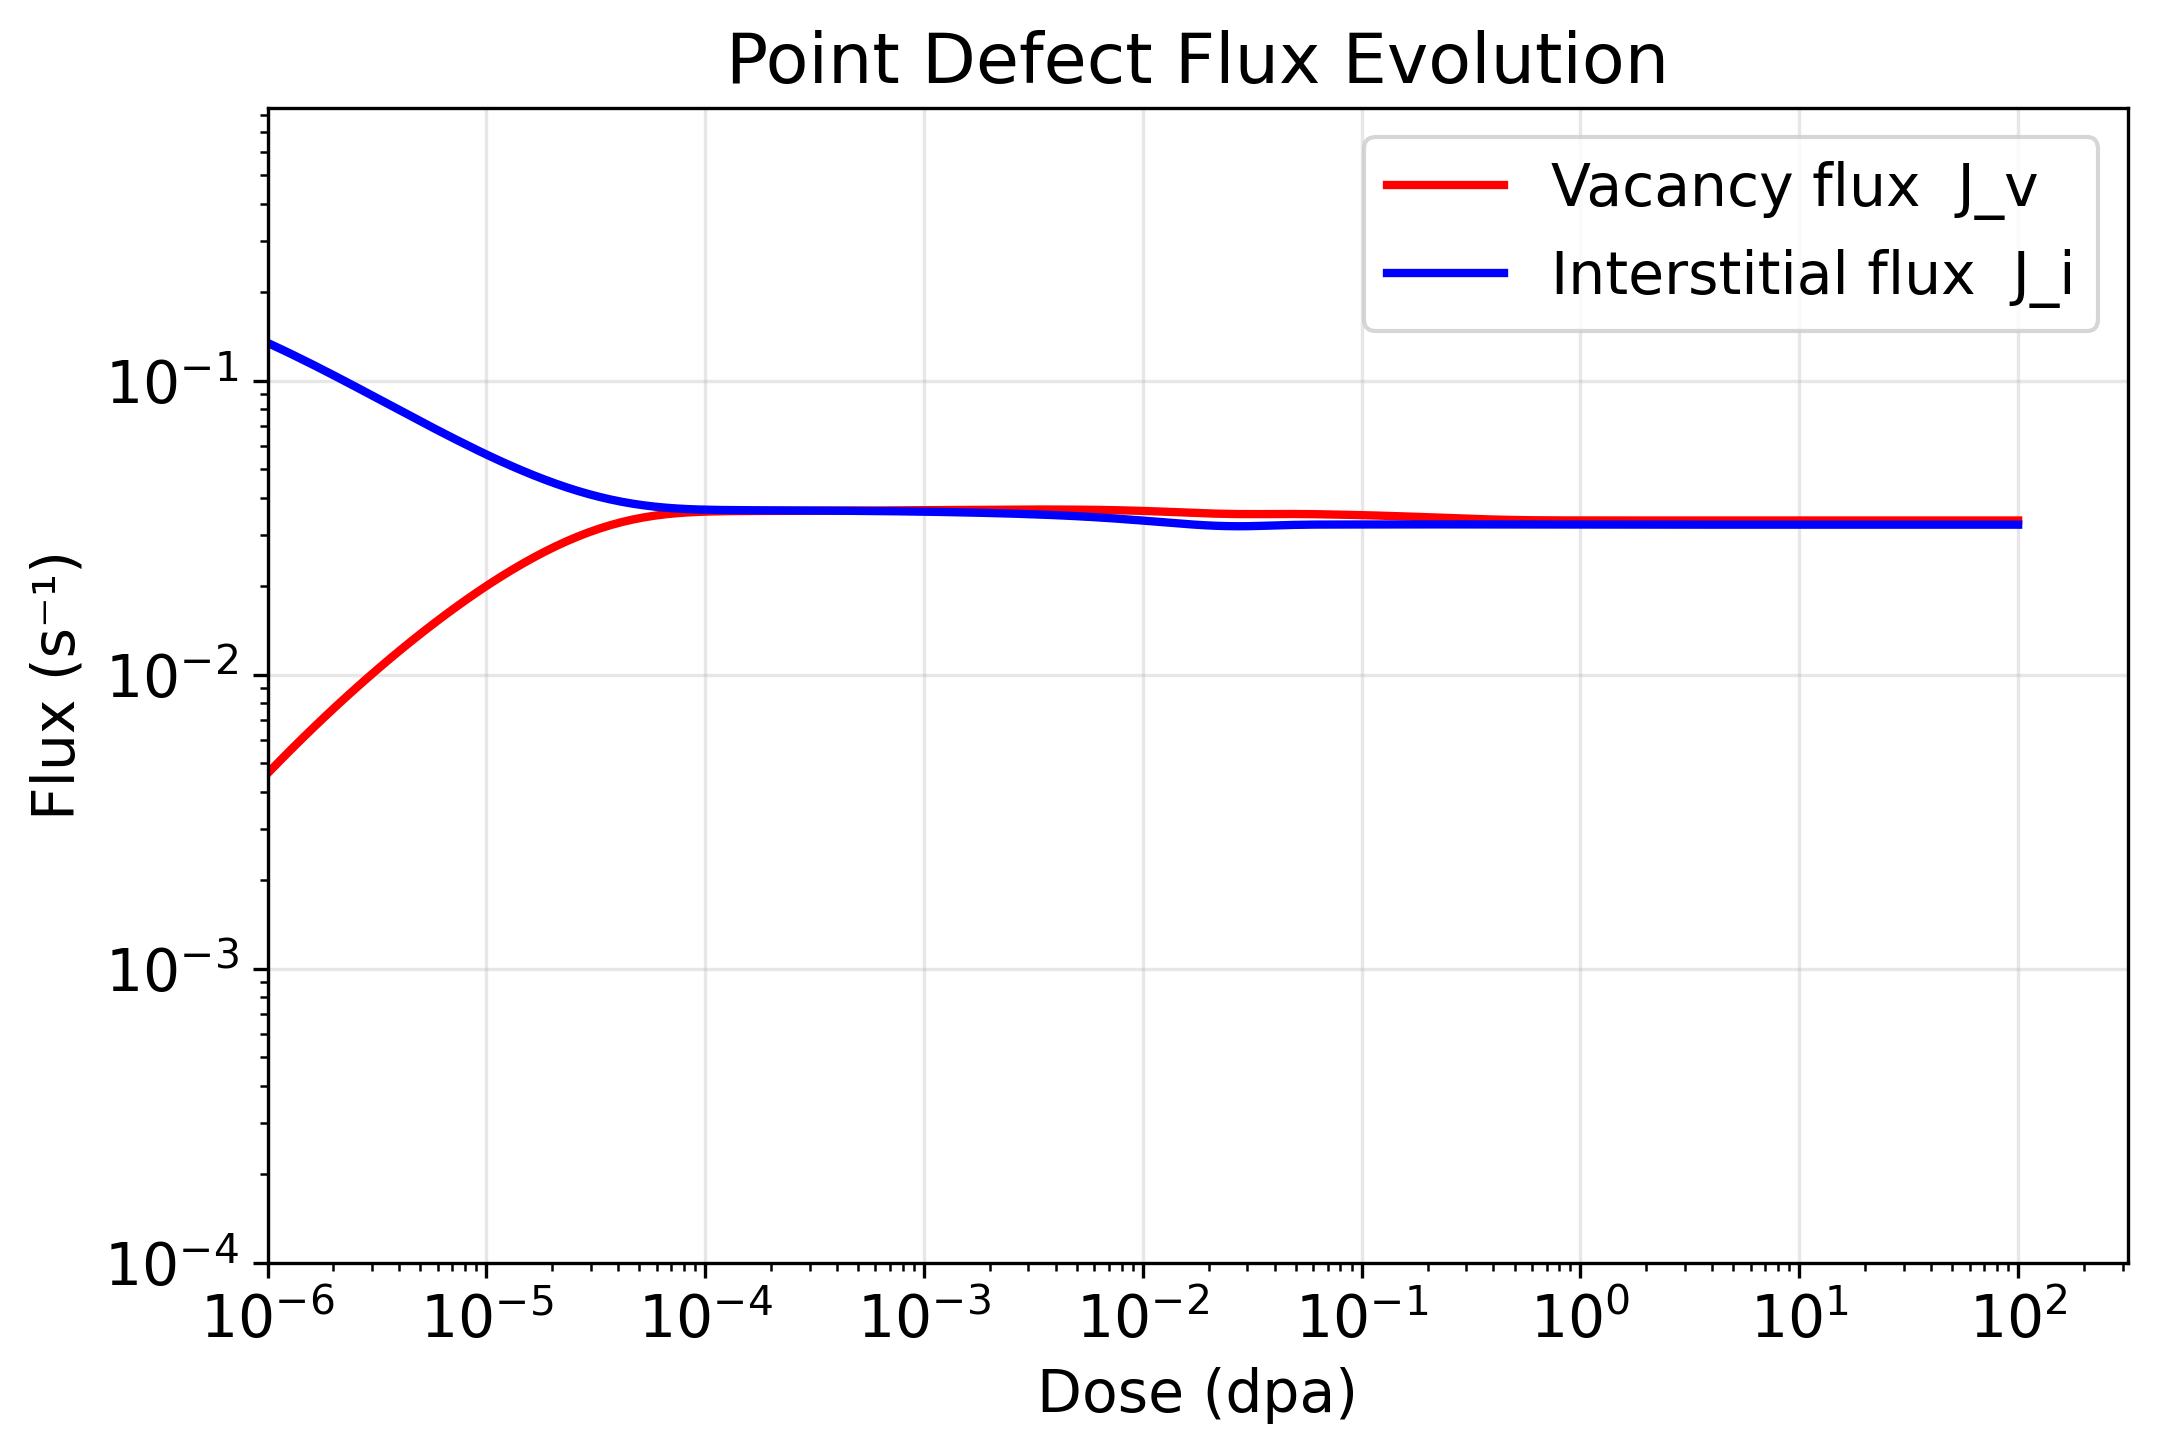


interstitial_fractions.png


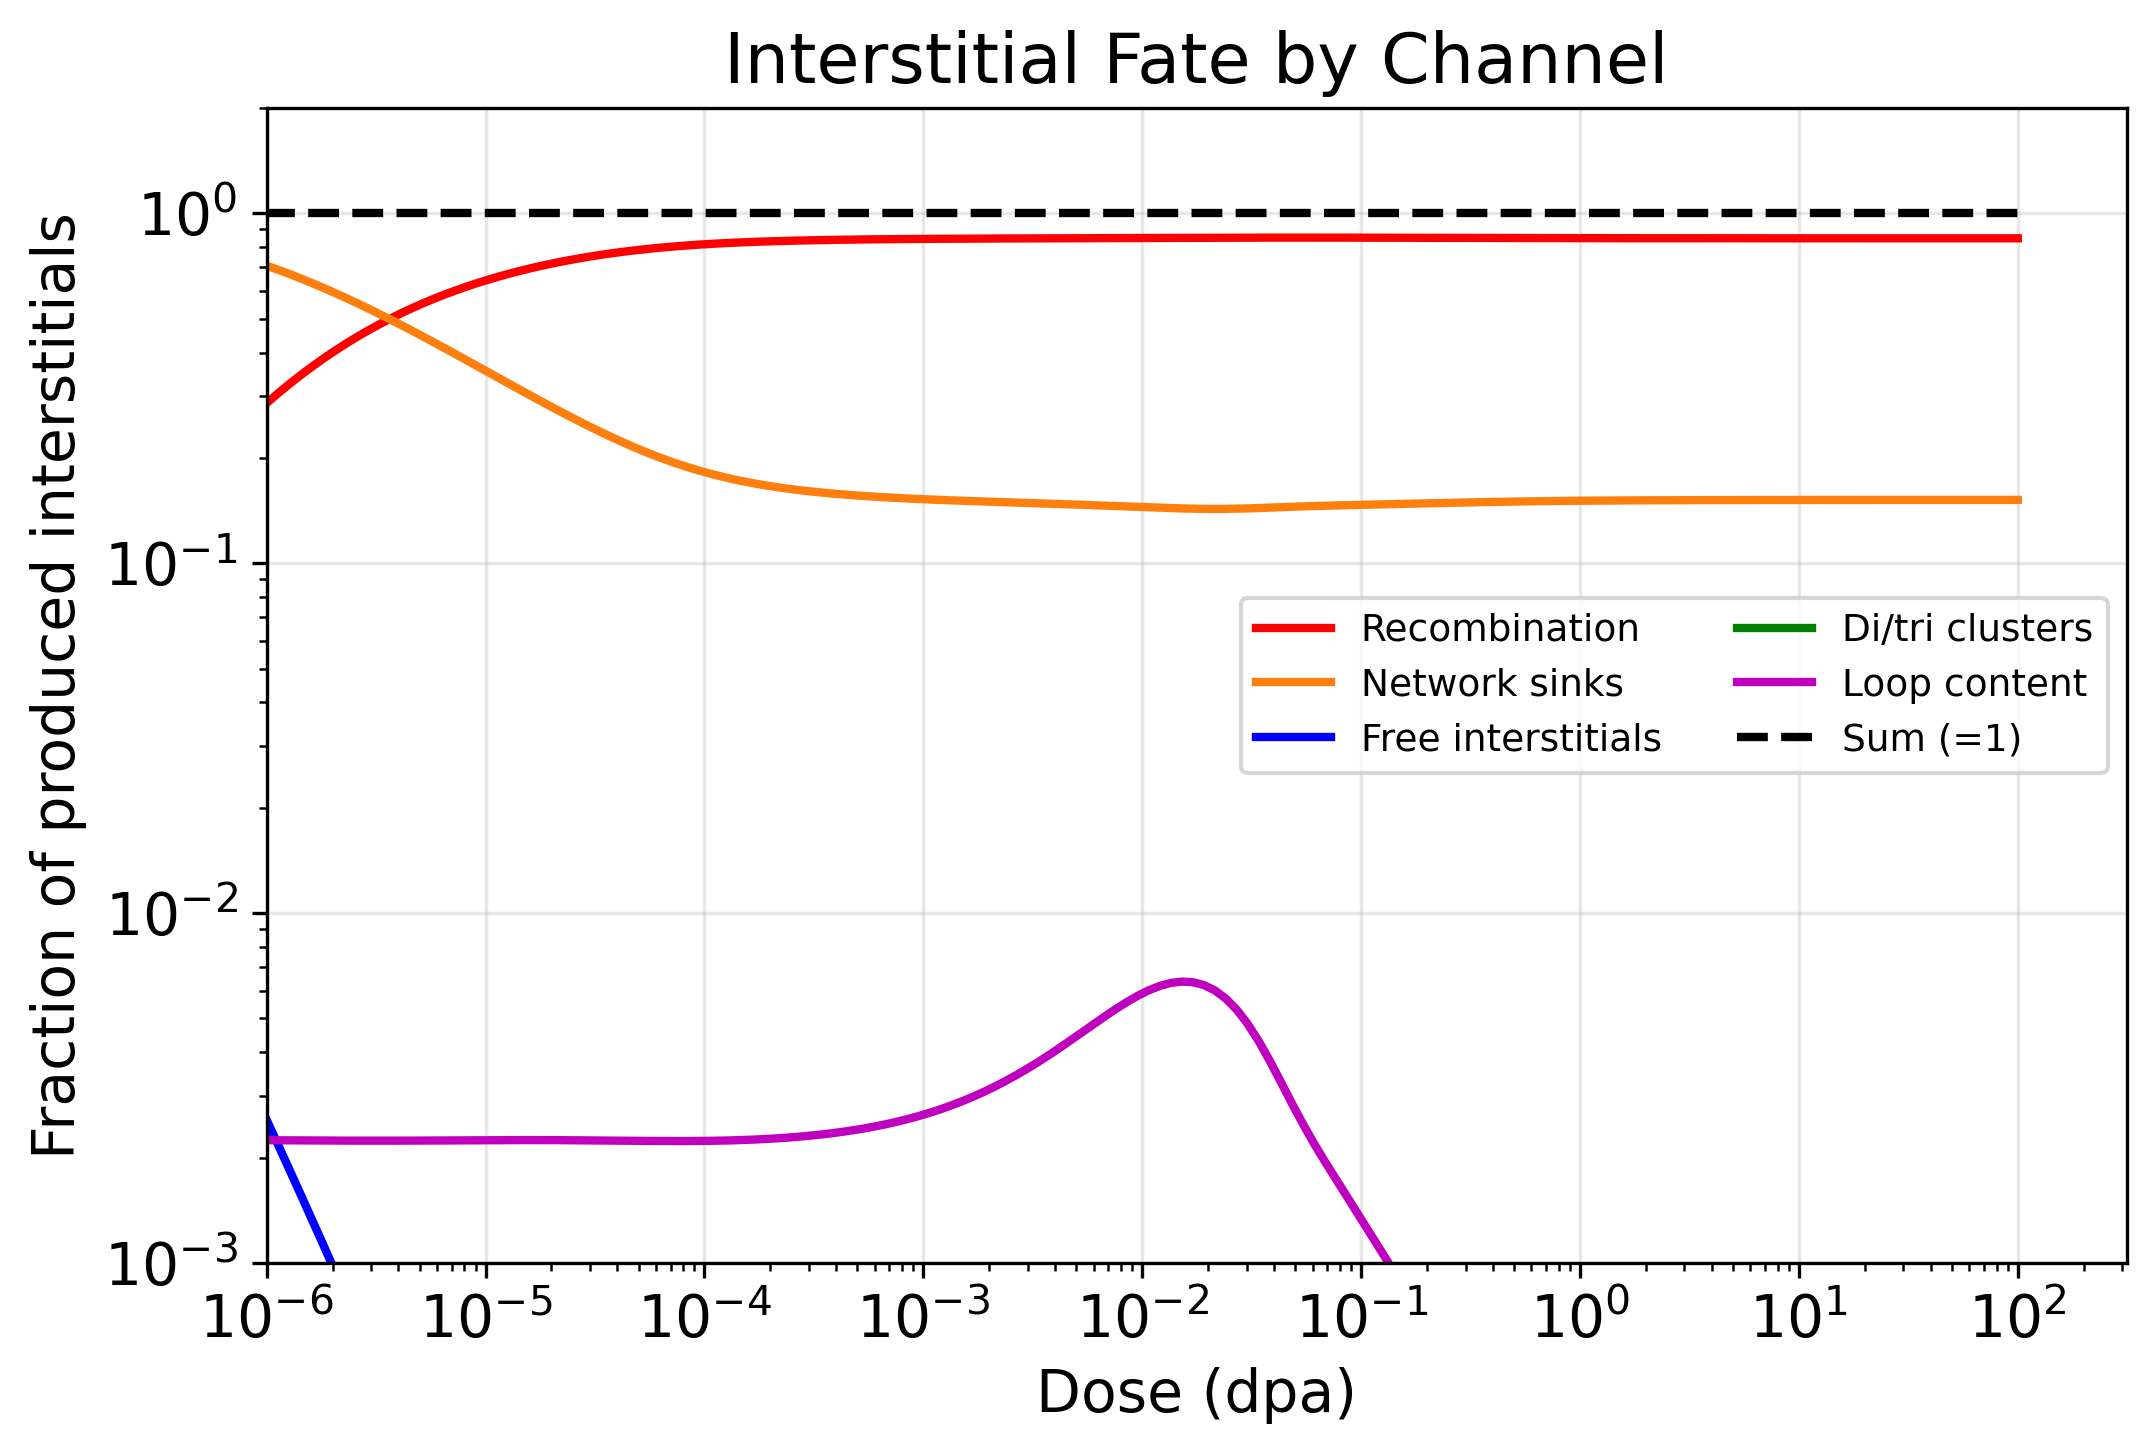


irradiation_growth.png


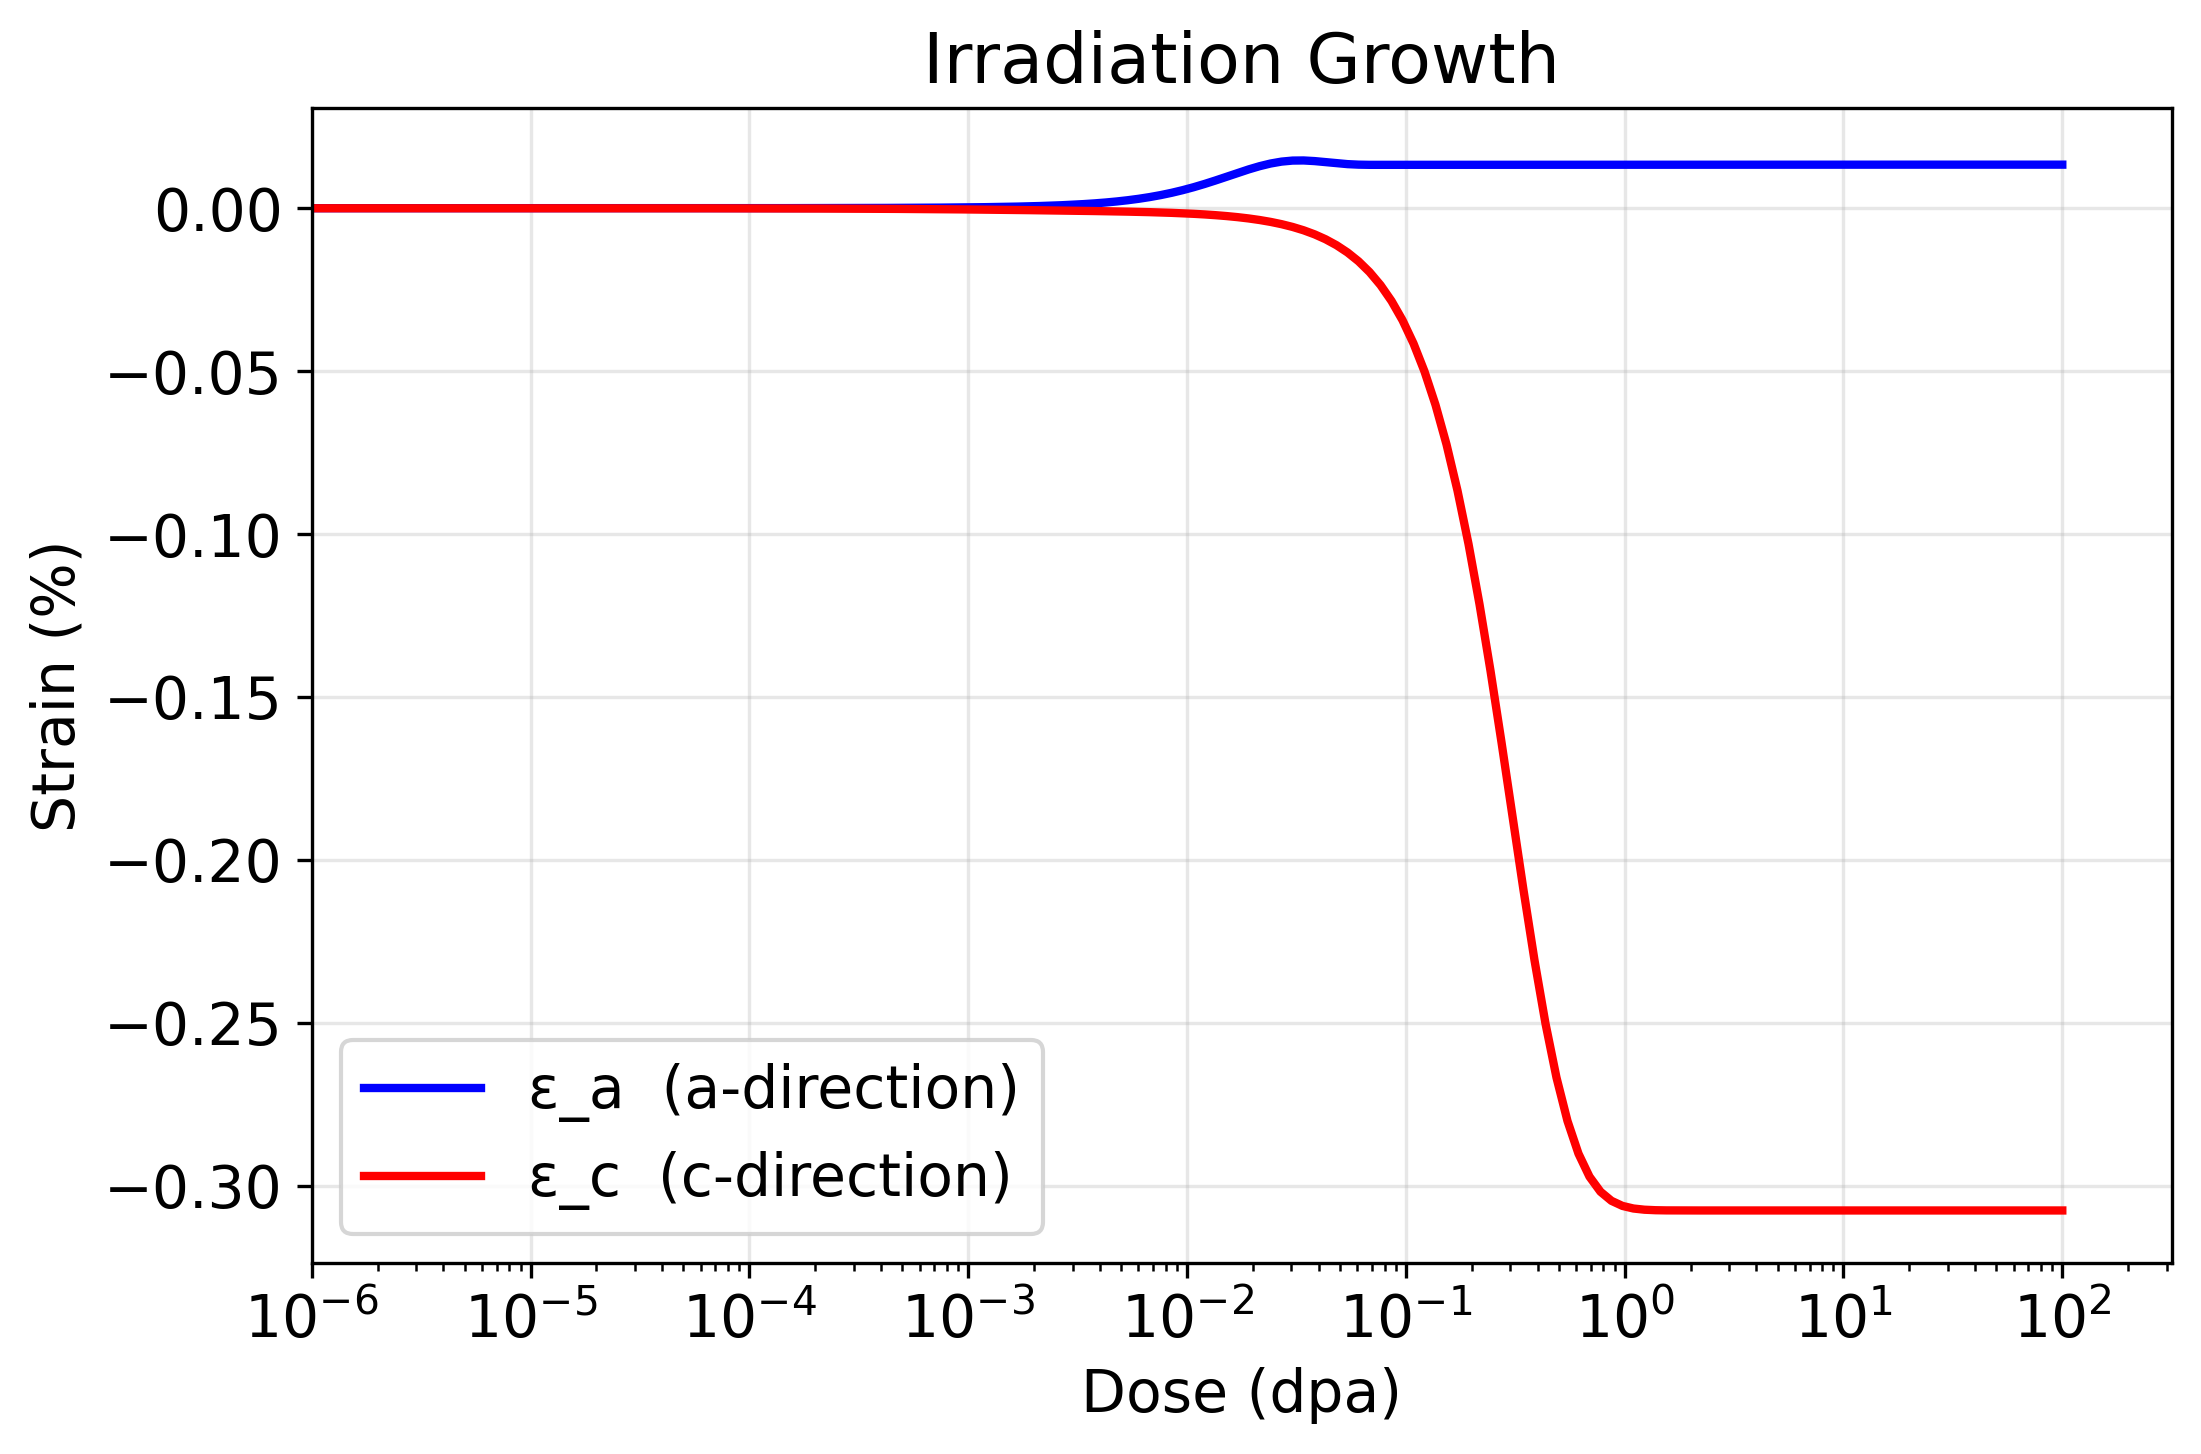


loop_density.png


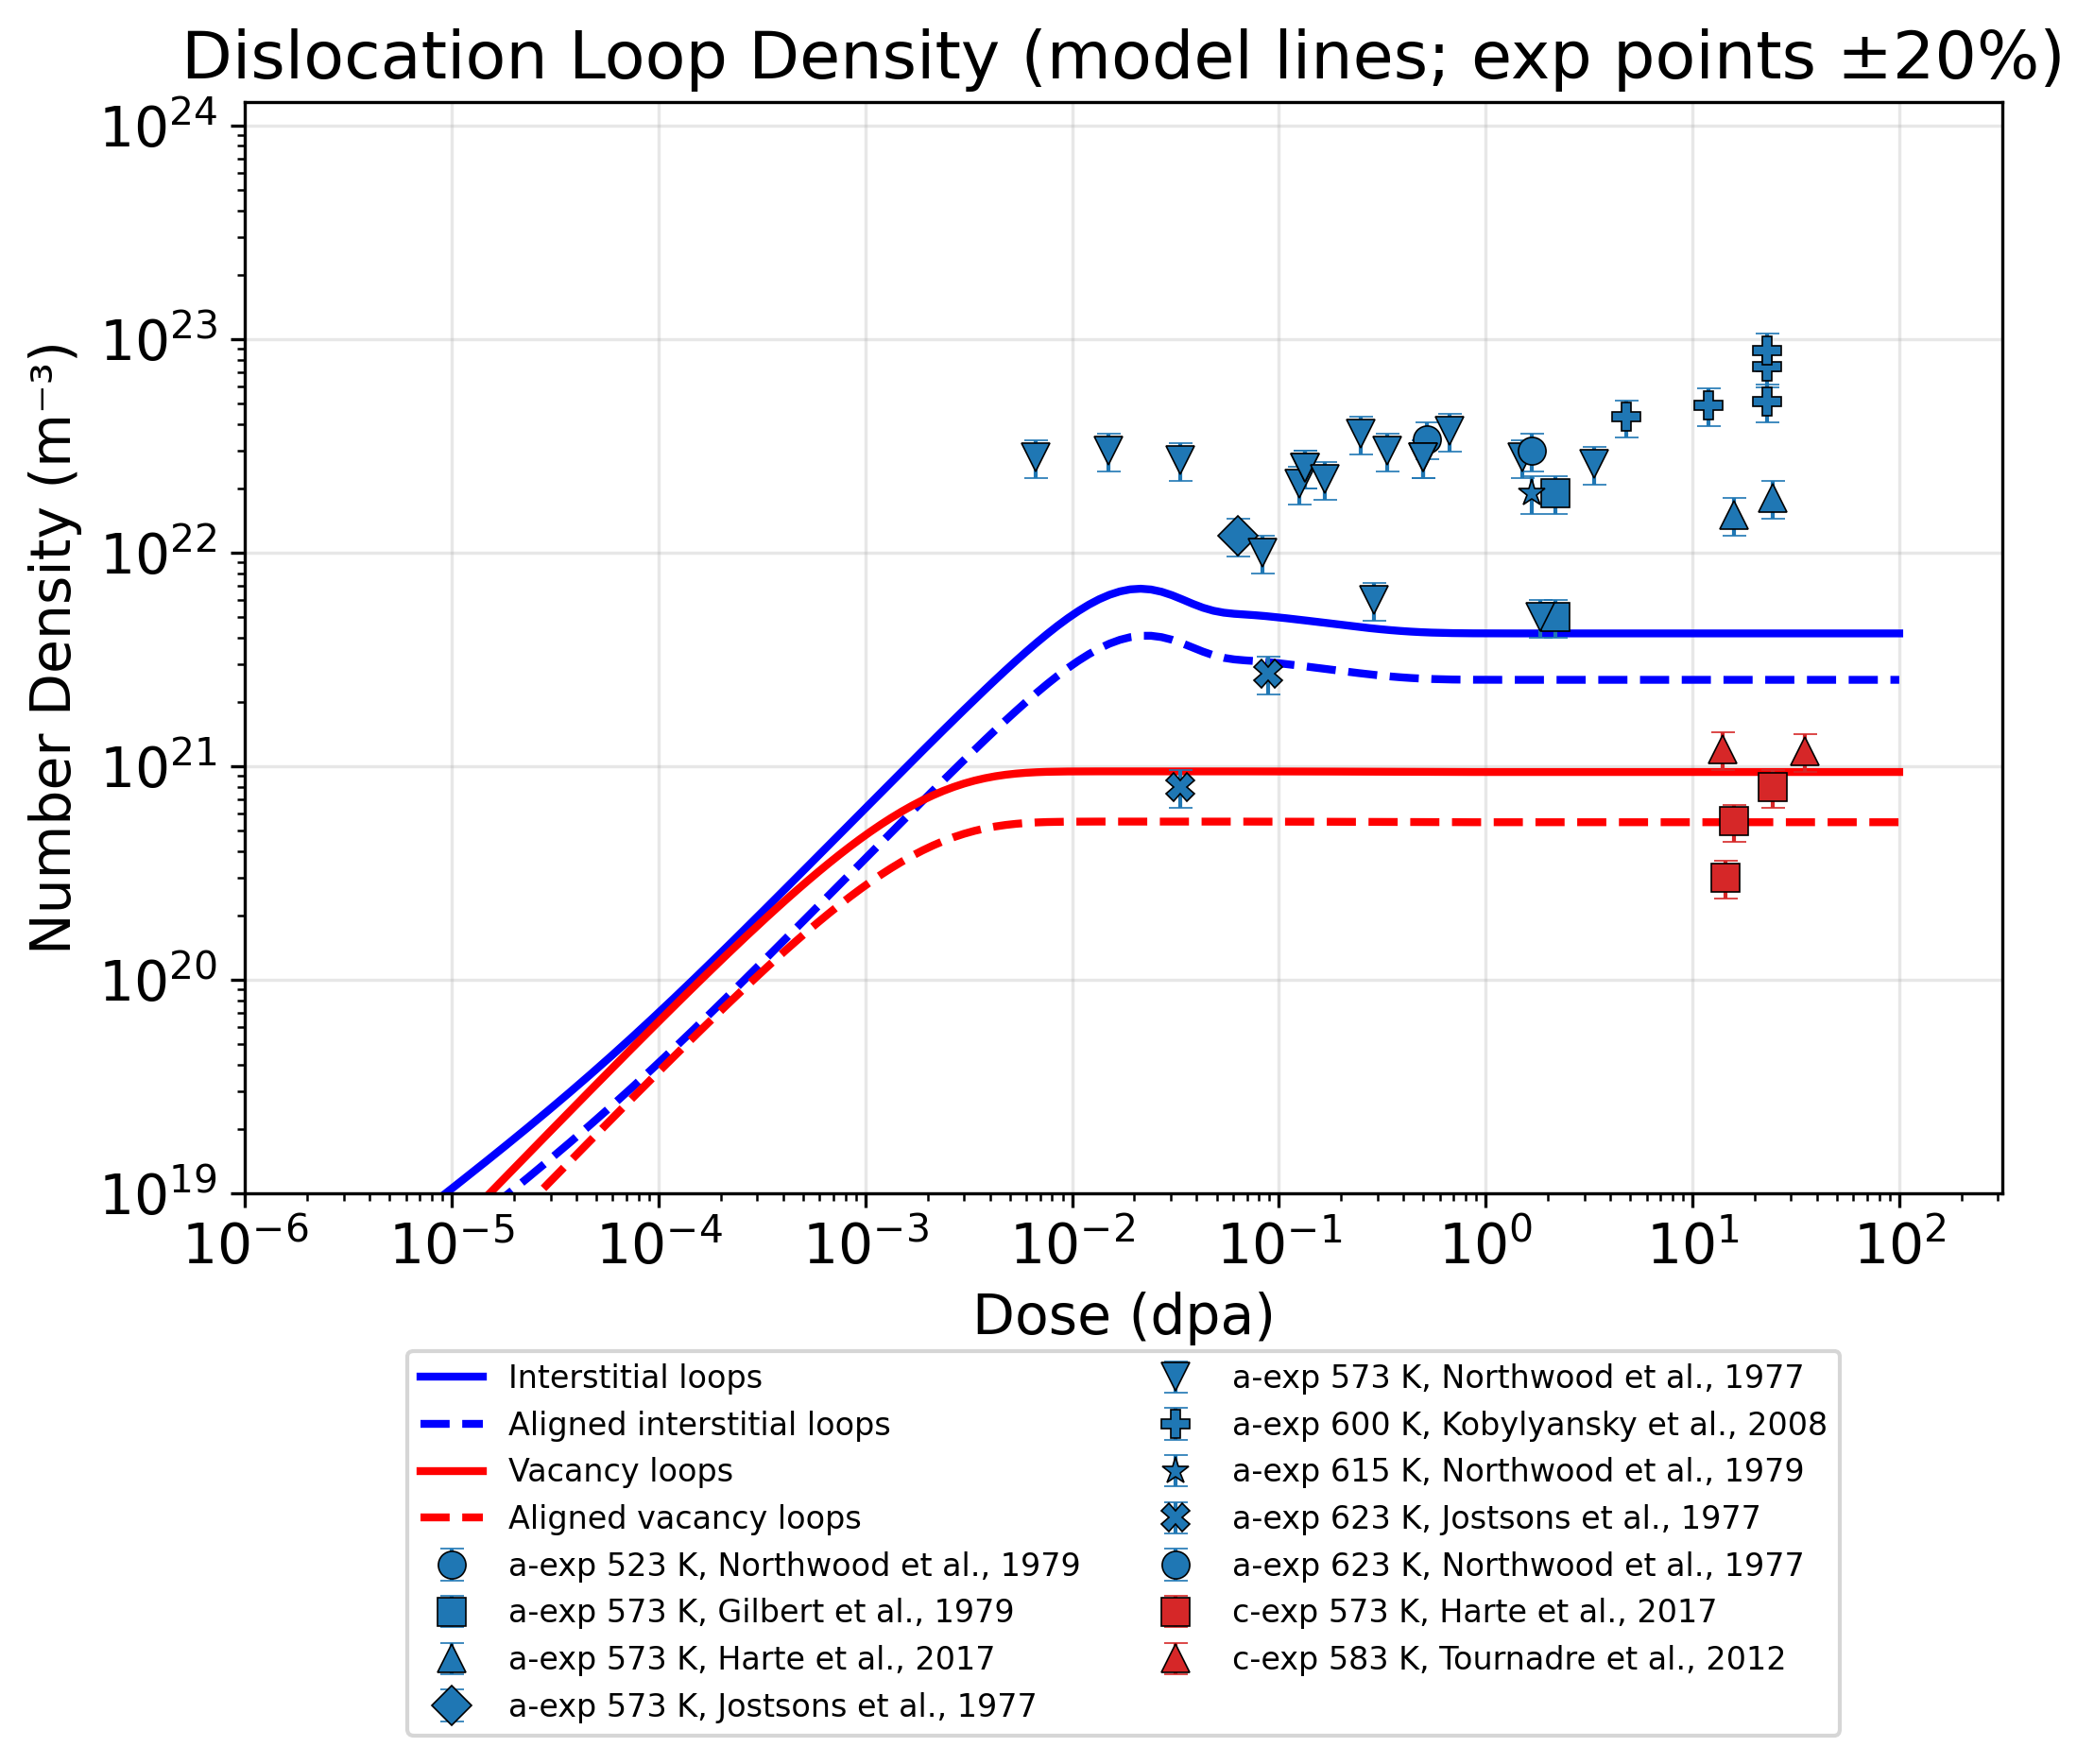


loop_density_analysis.png


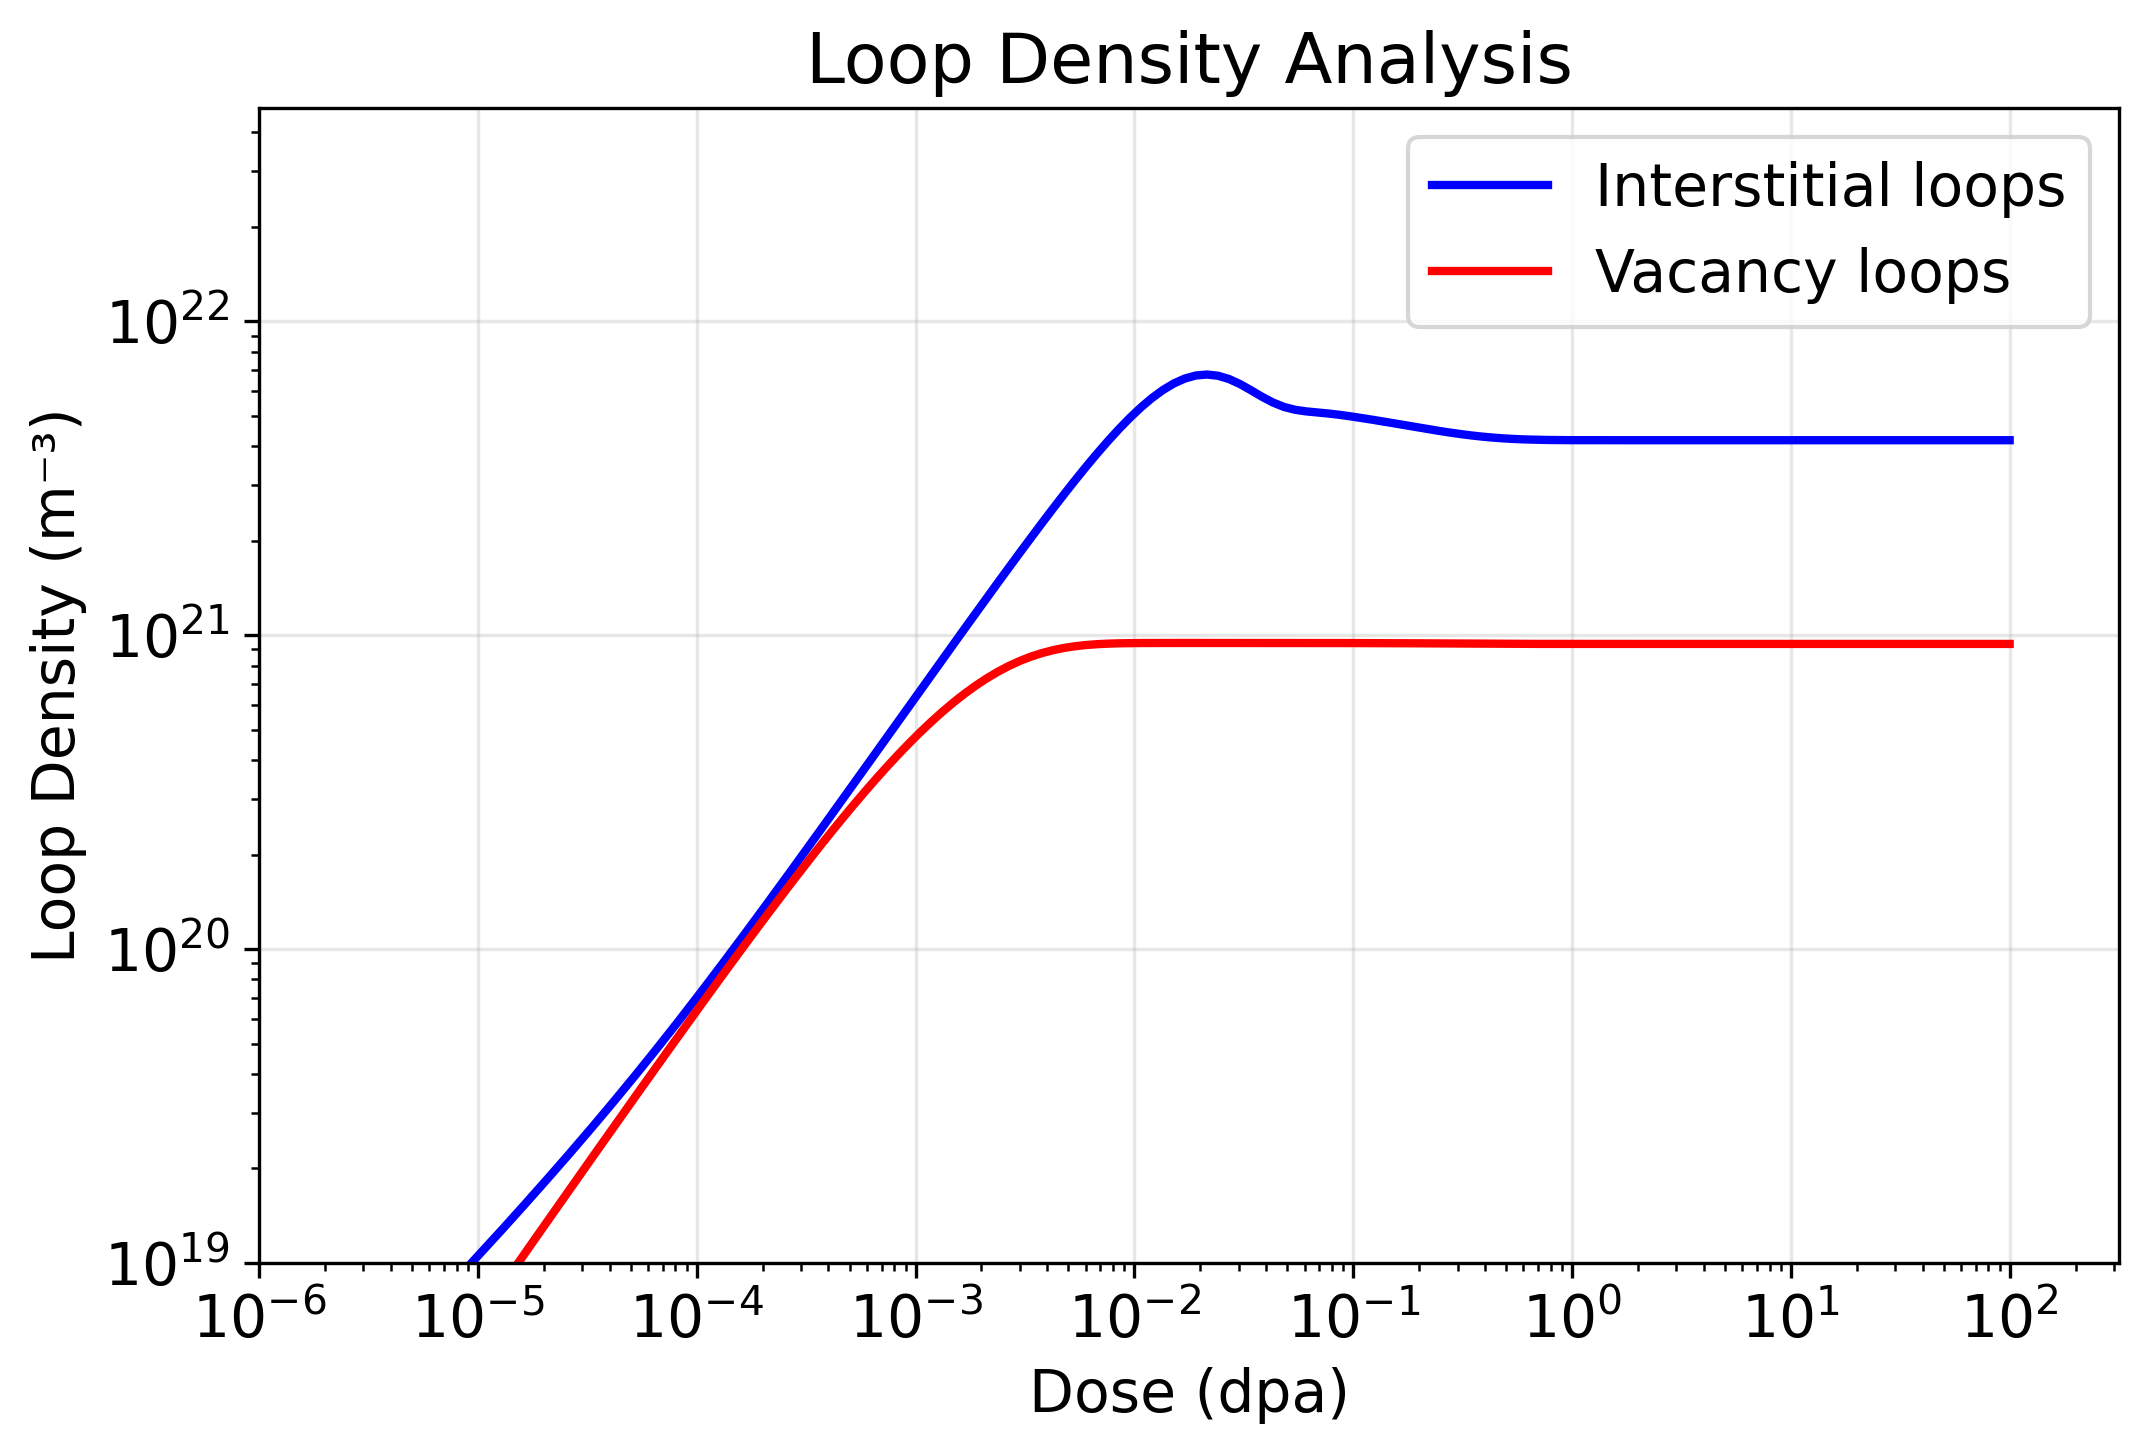


net_flux_balance.png


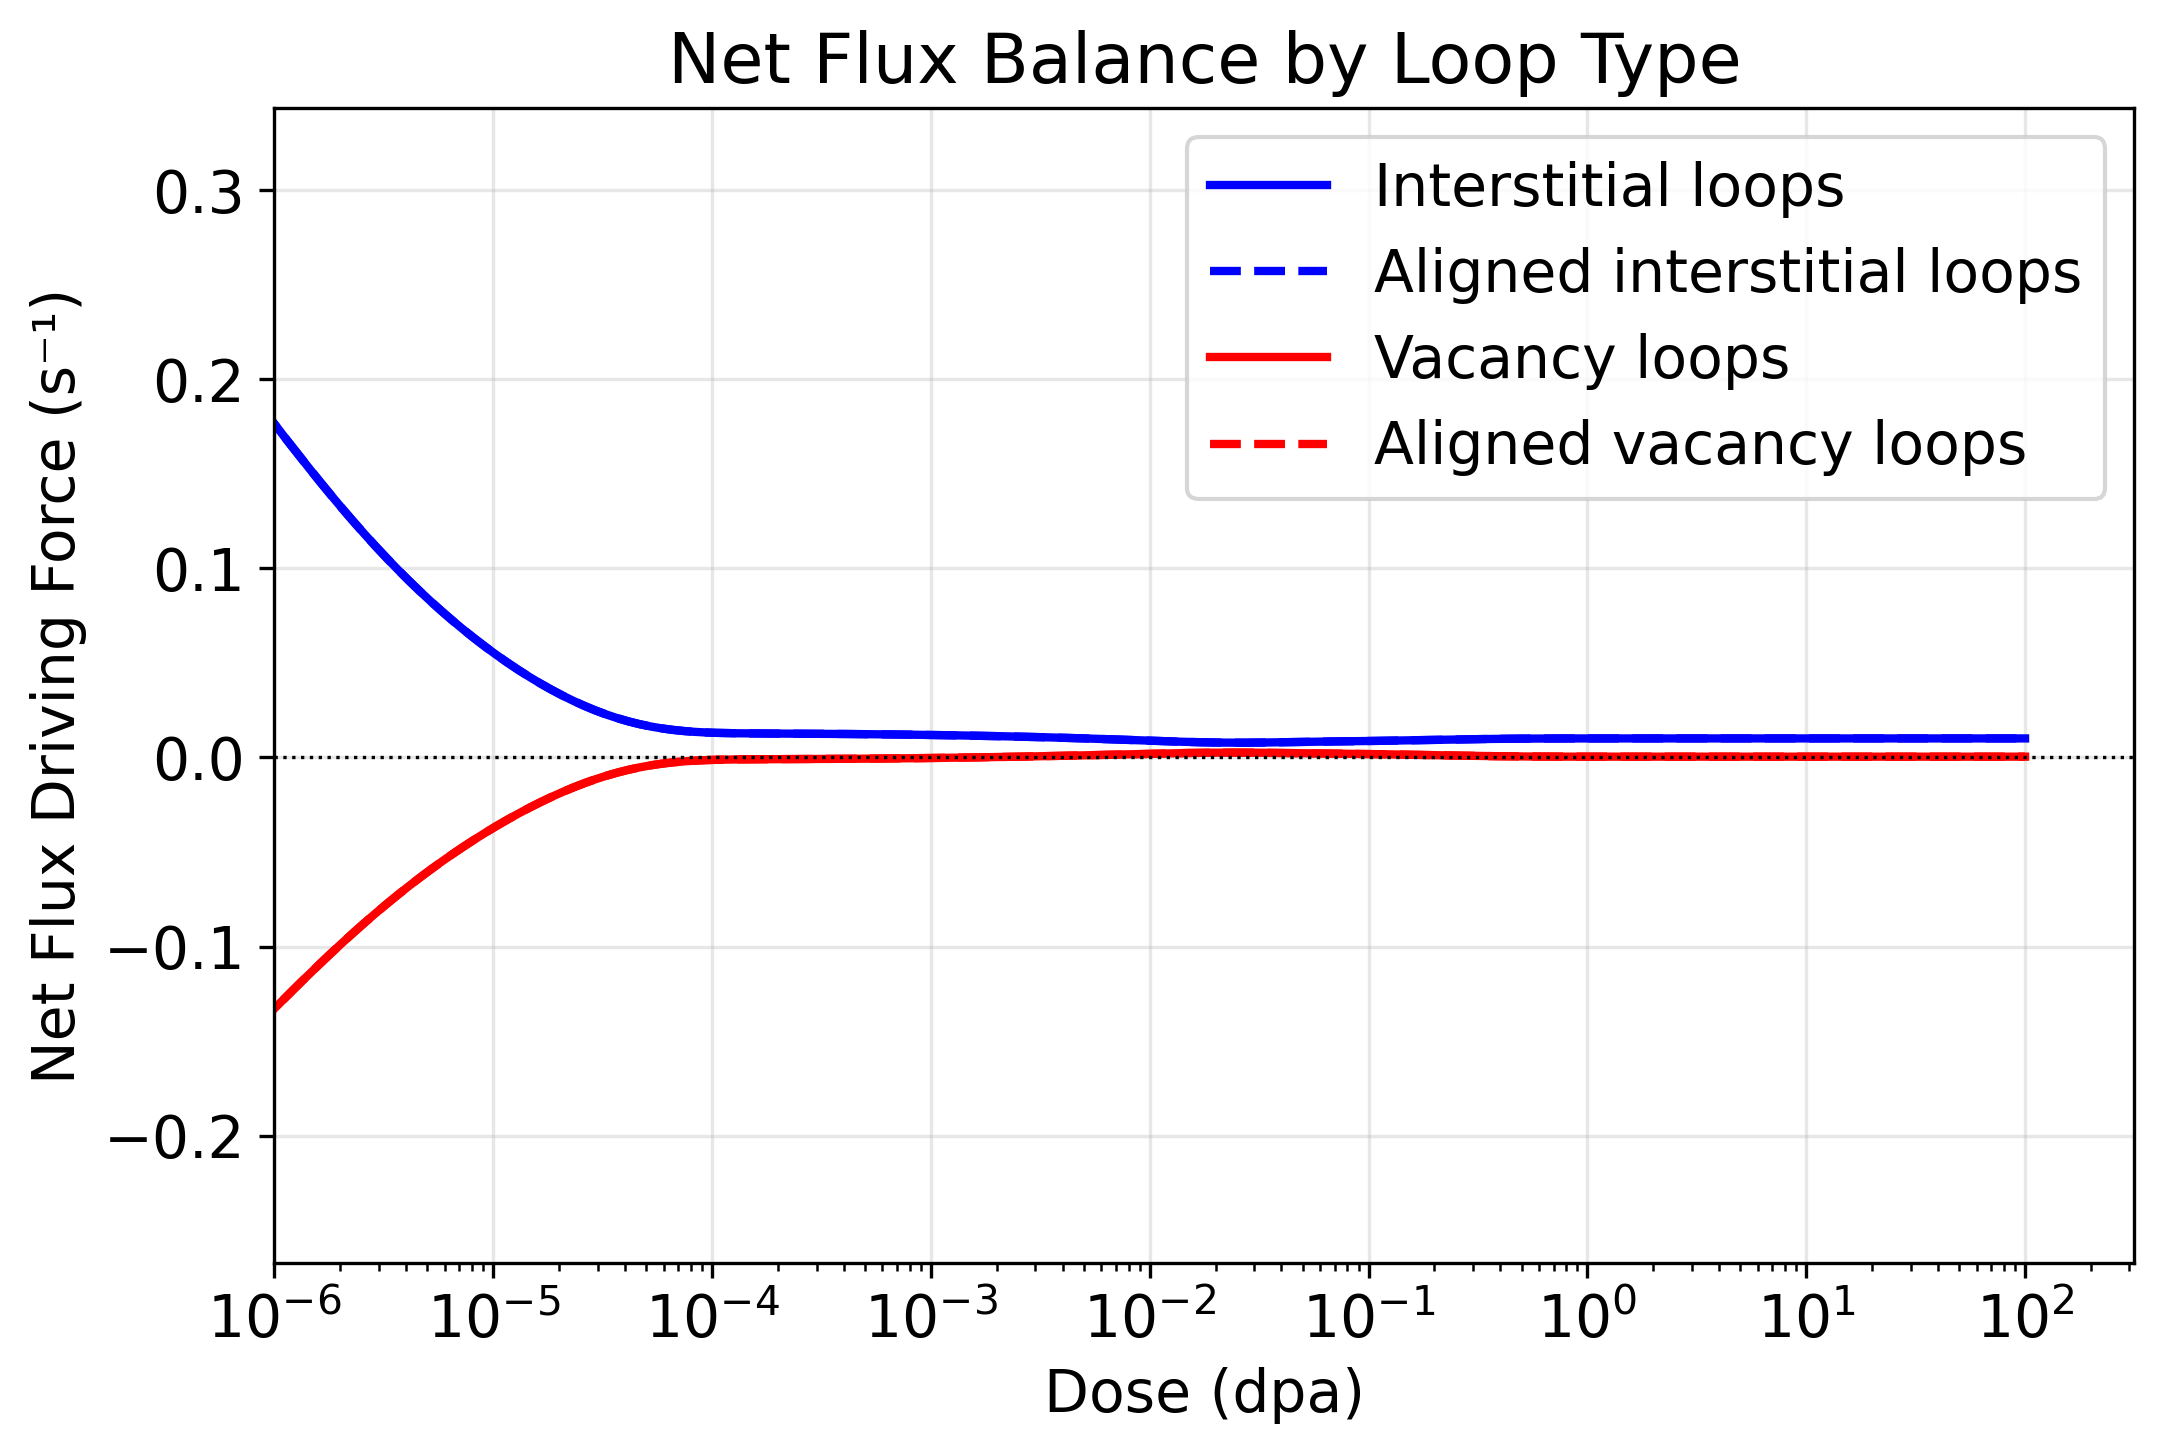


point_defects.png


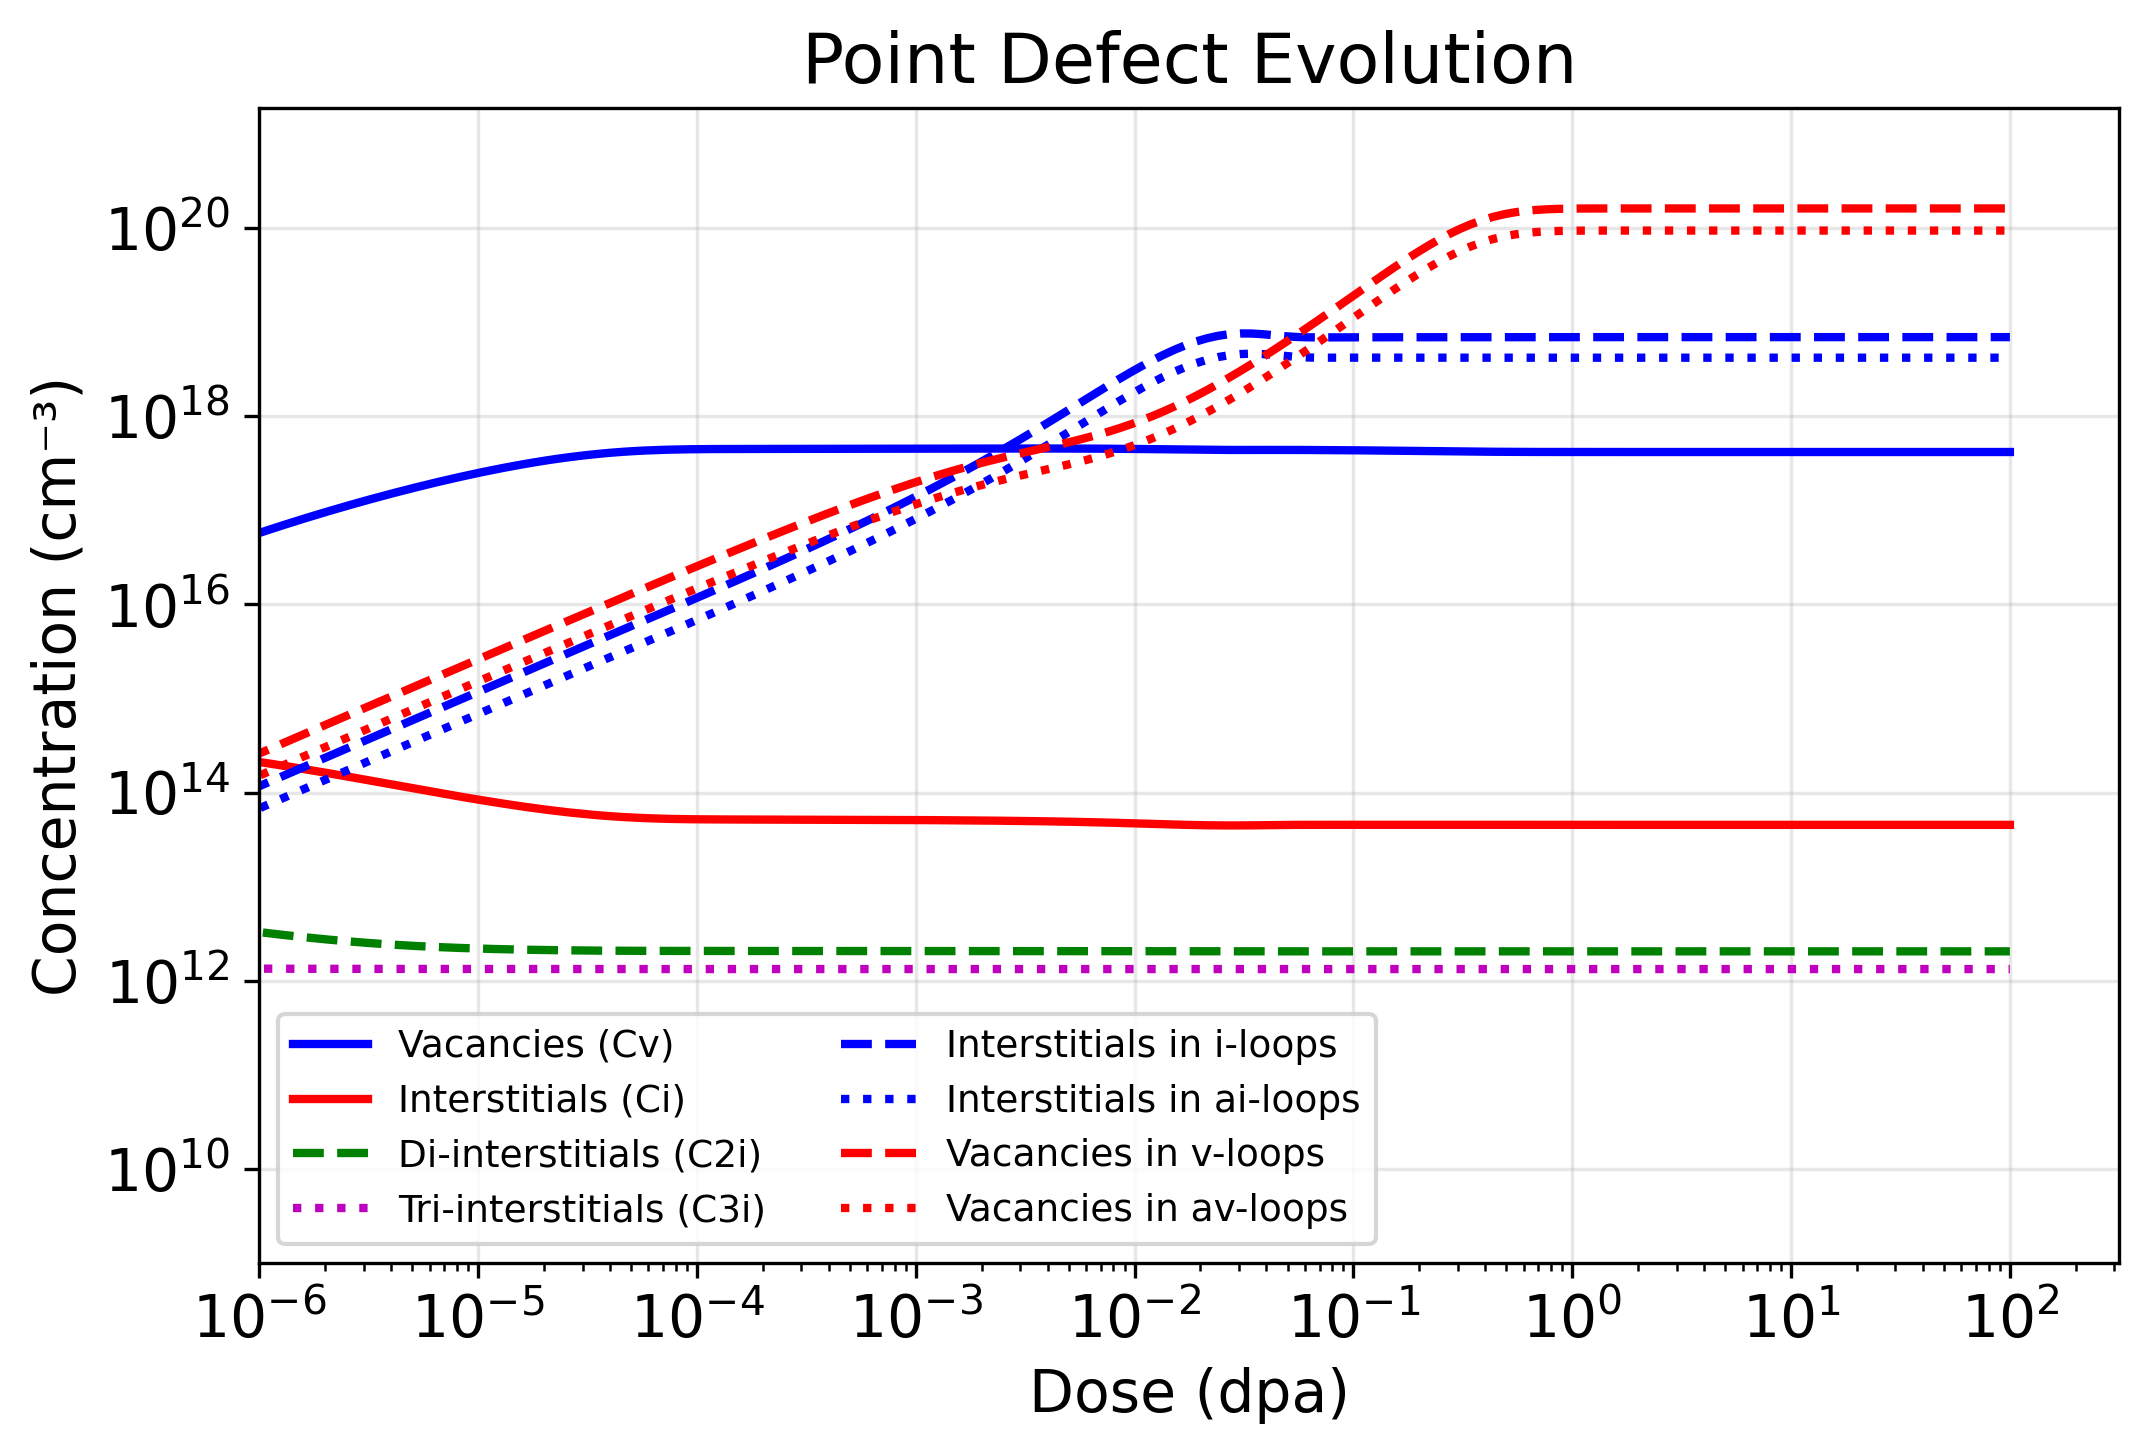


radiation_hardening.png


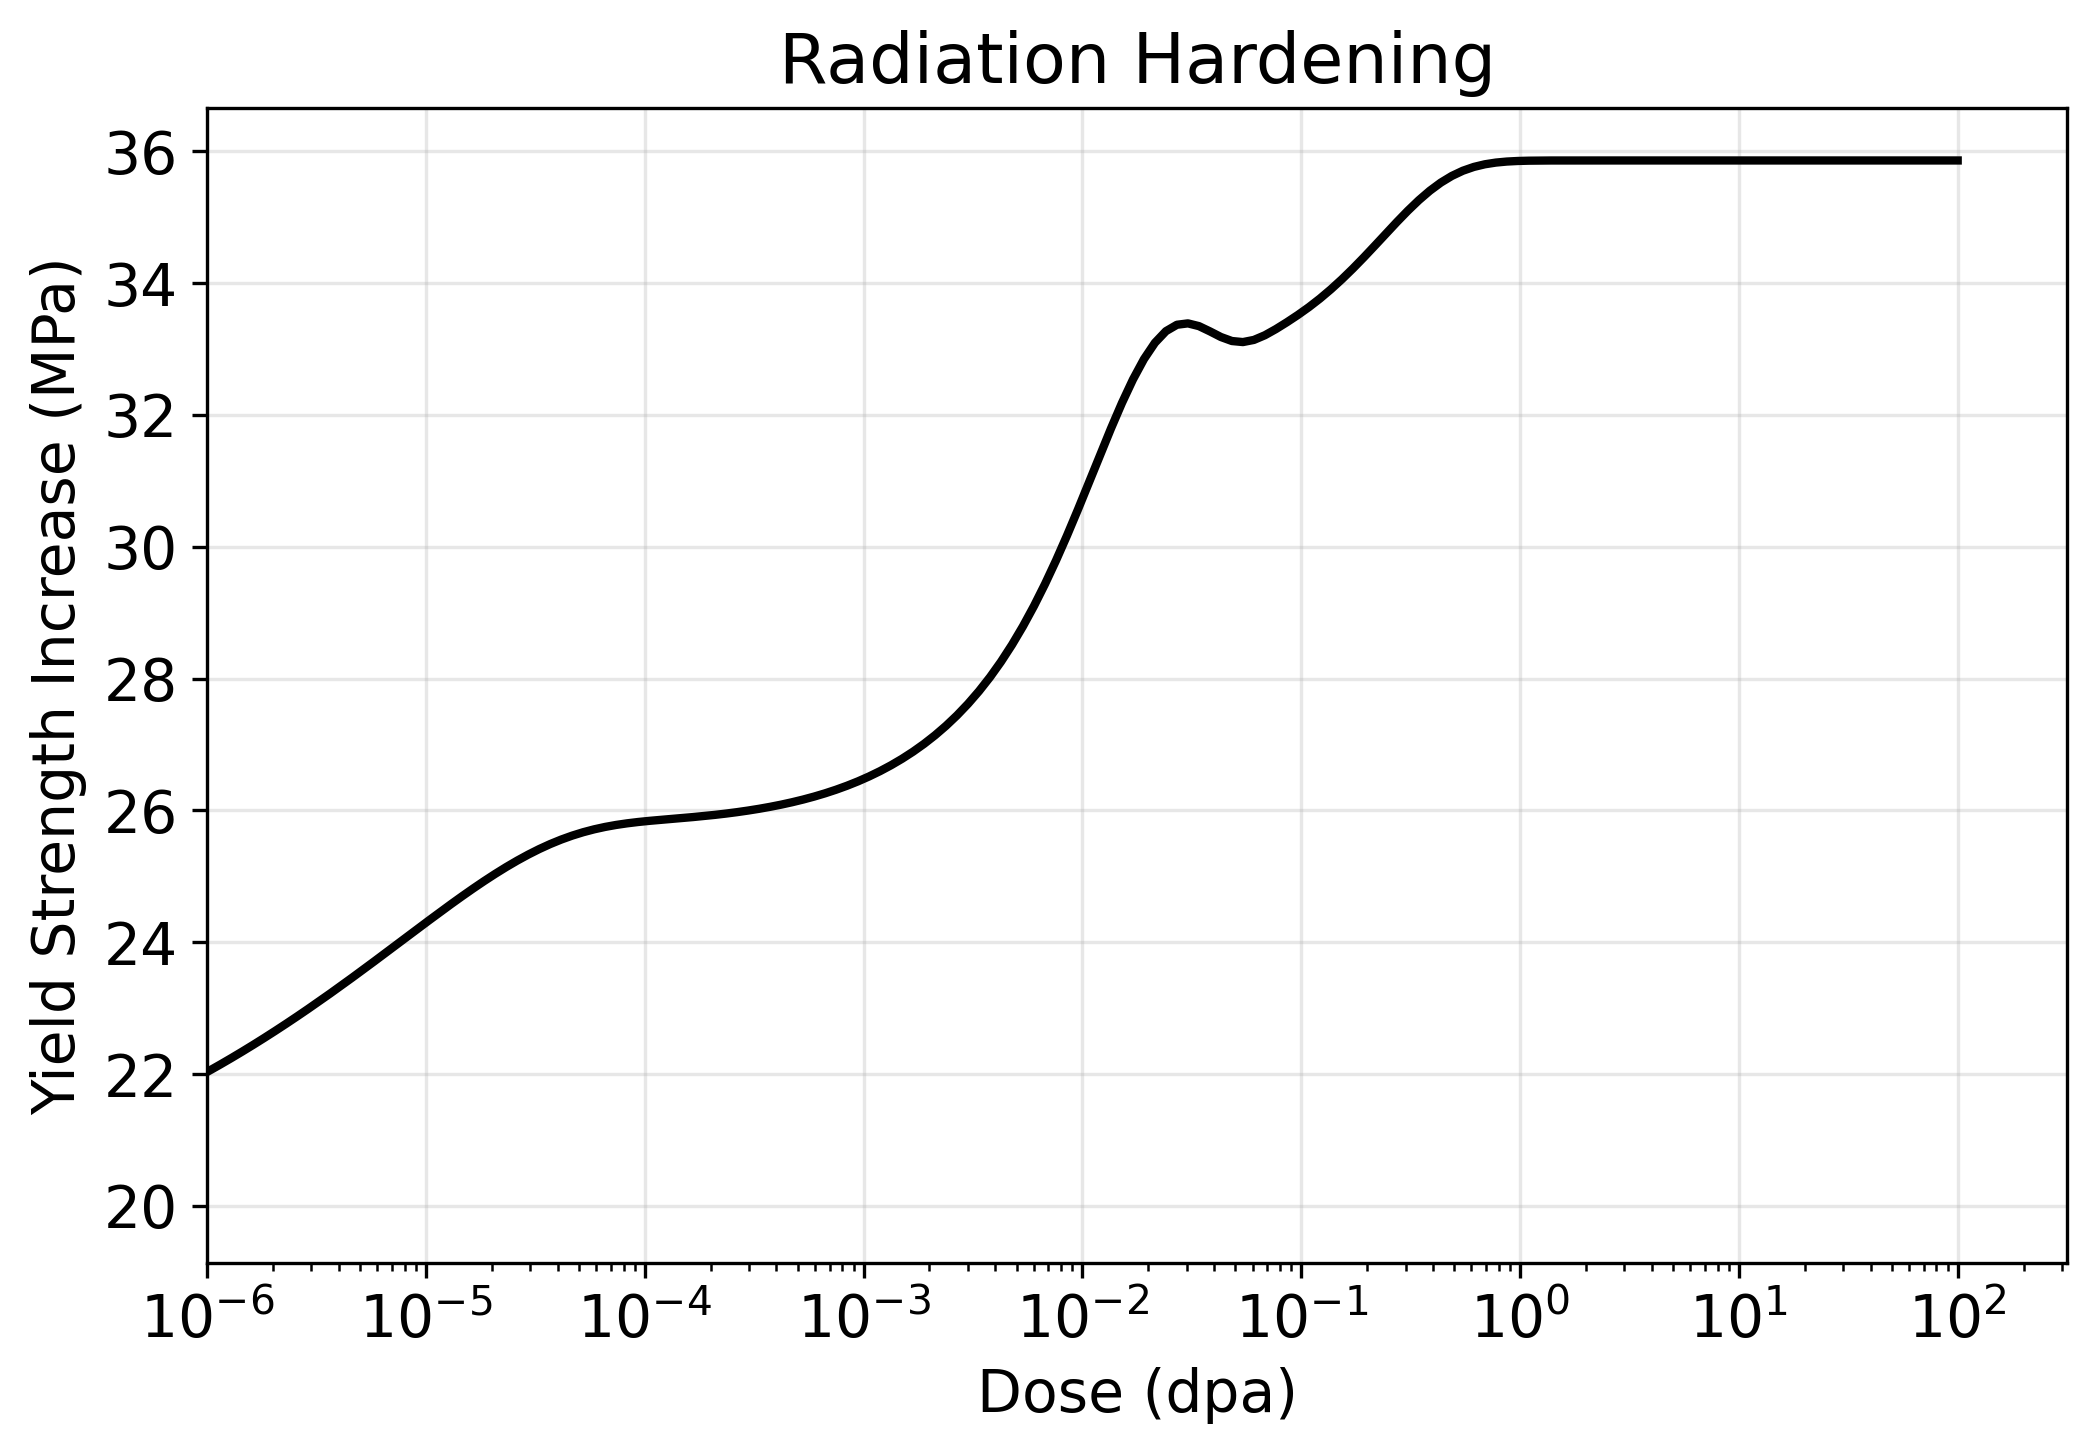


strain_rates.png


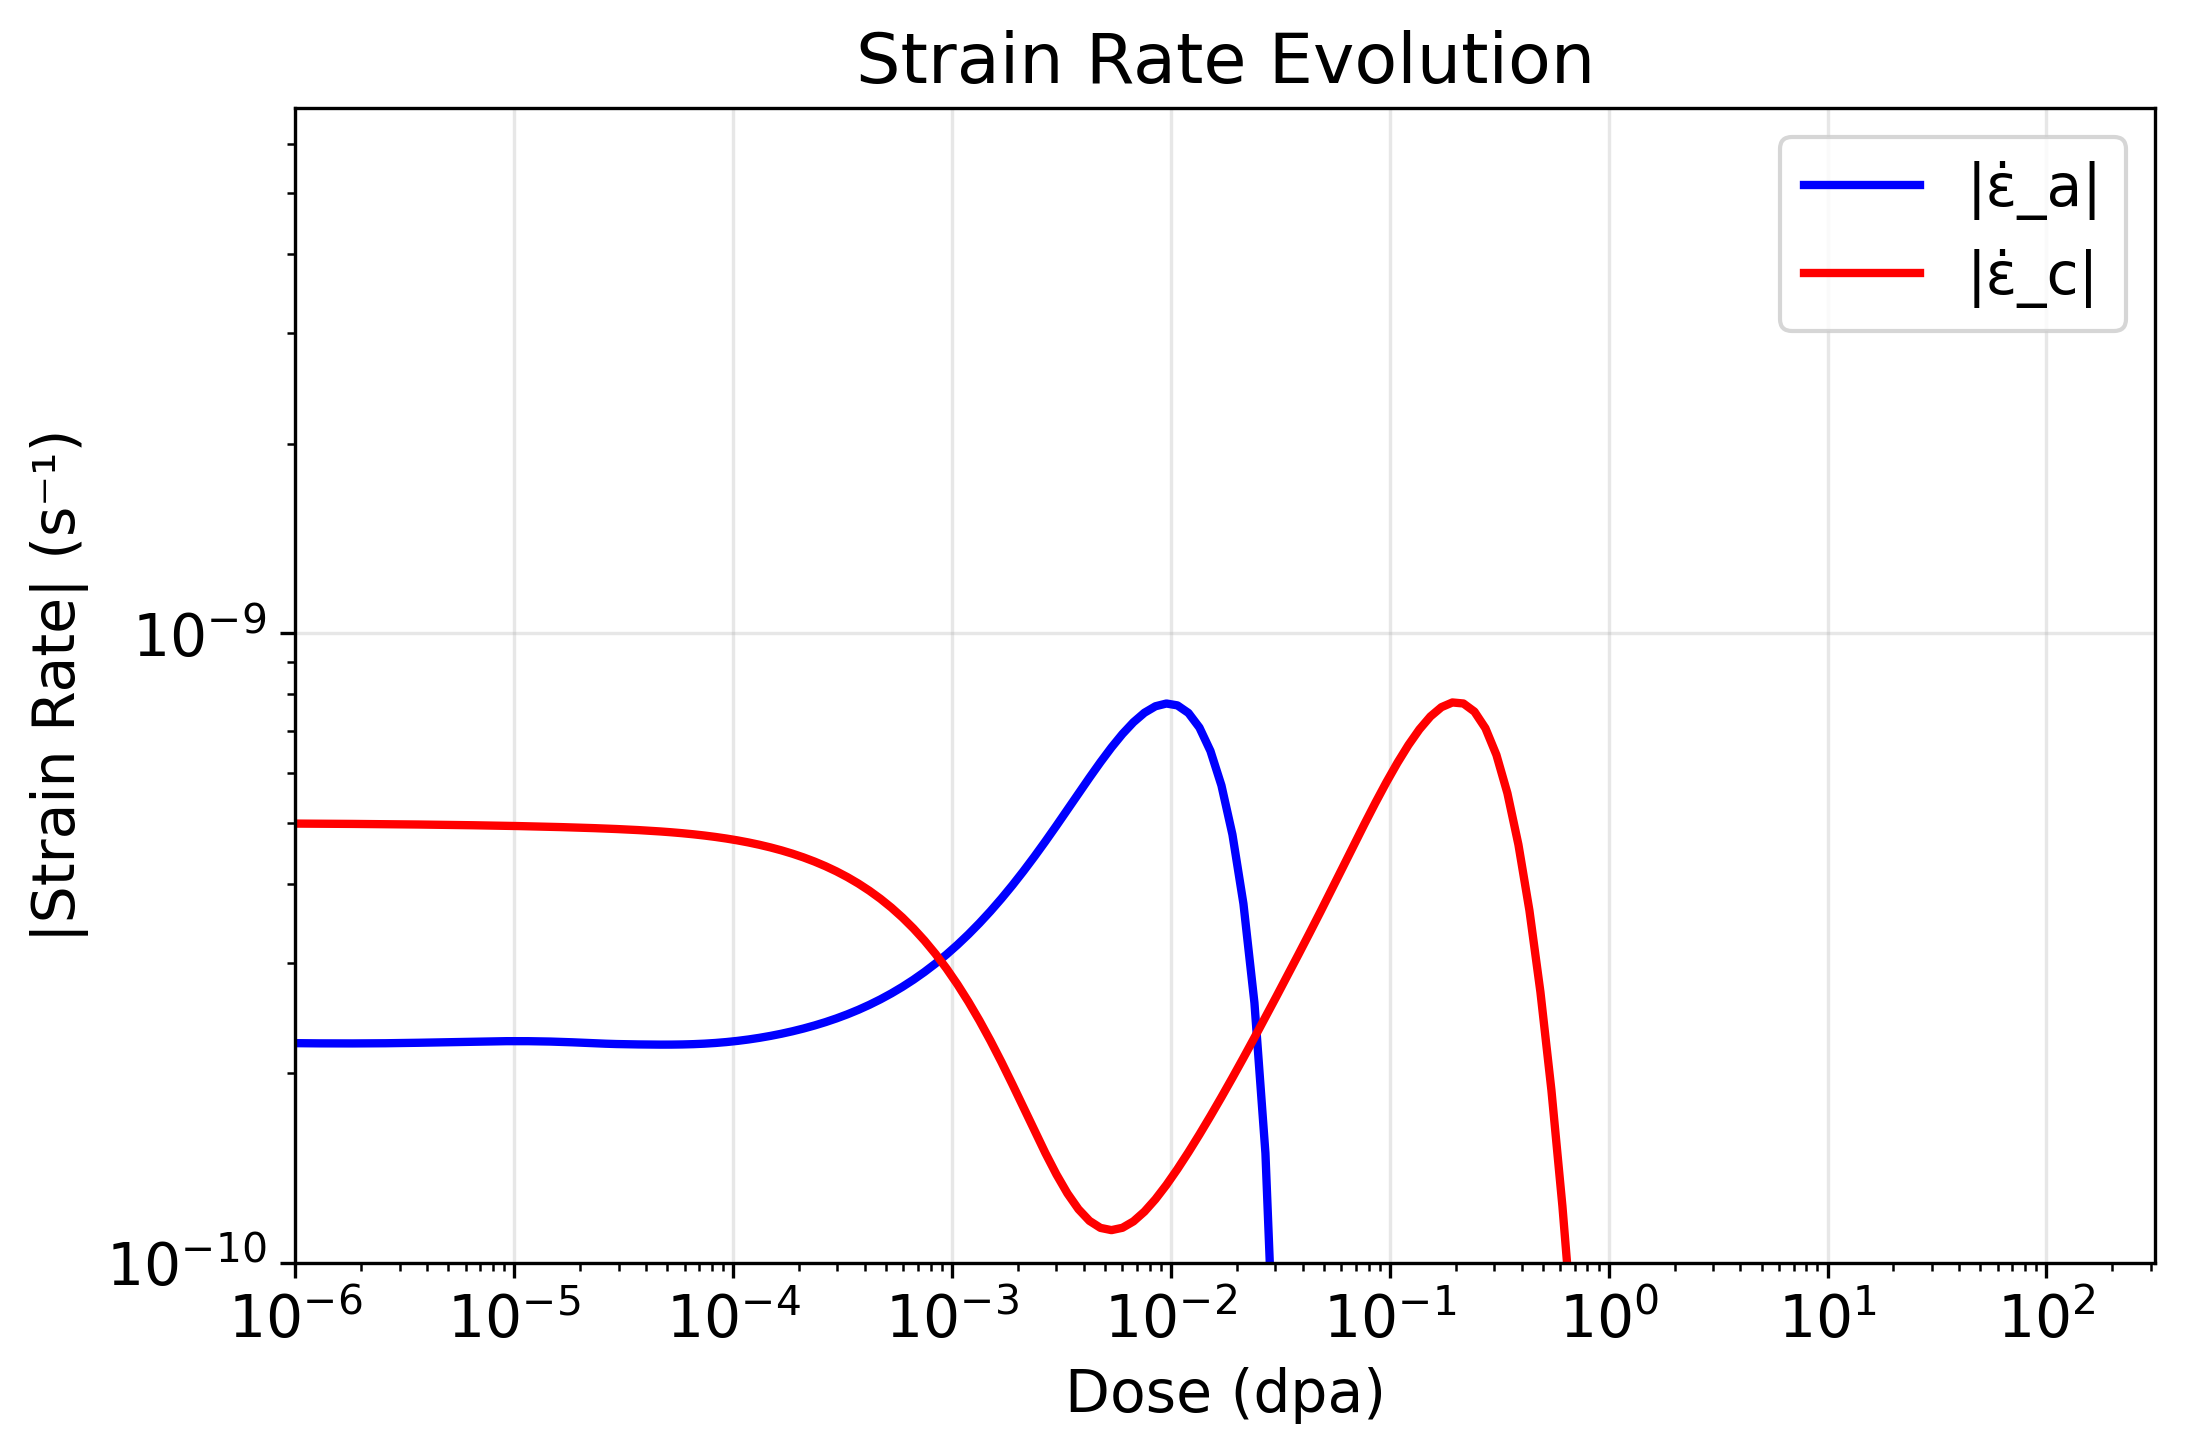


total_defect_evolution.png


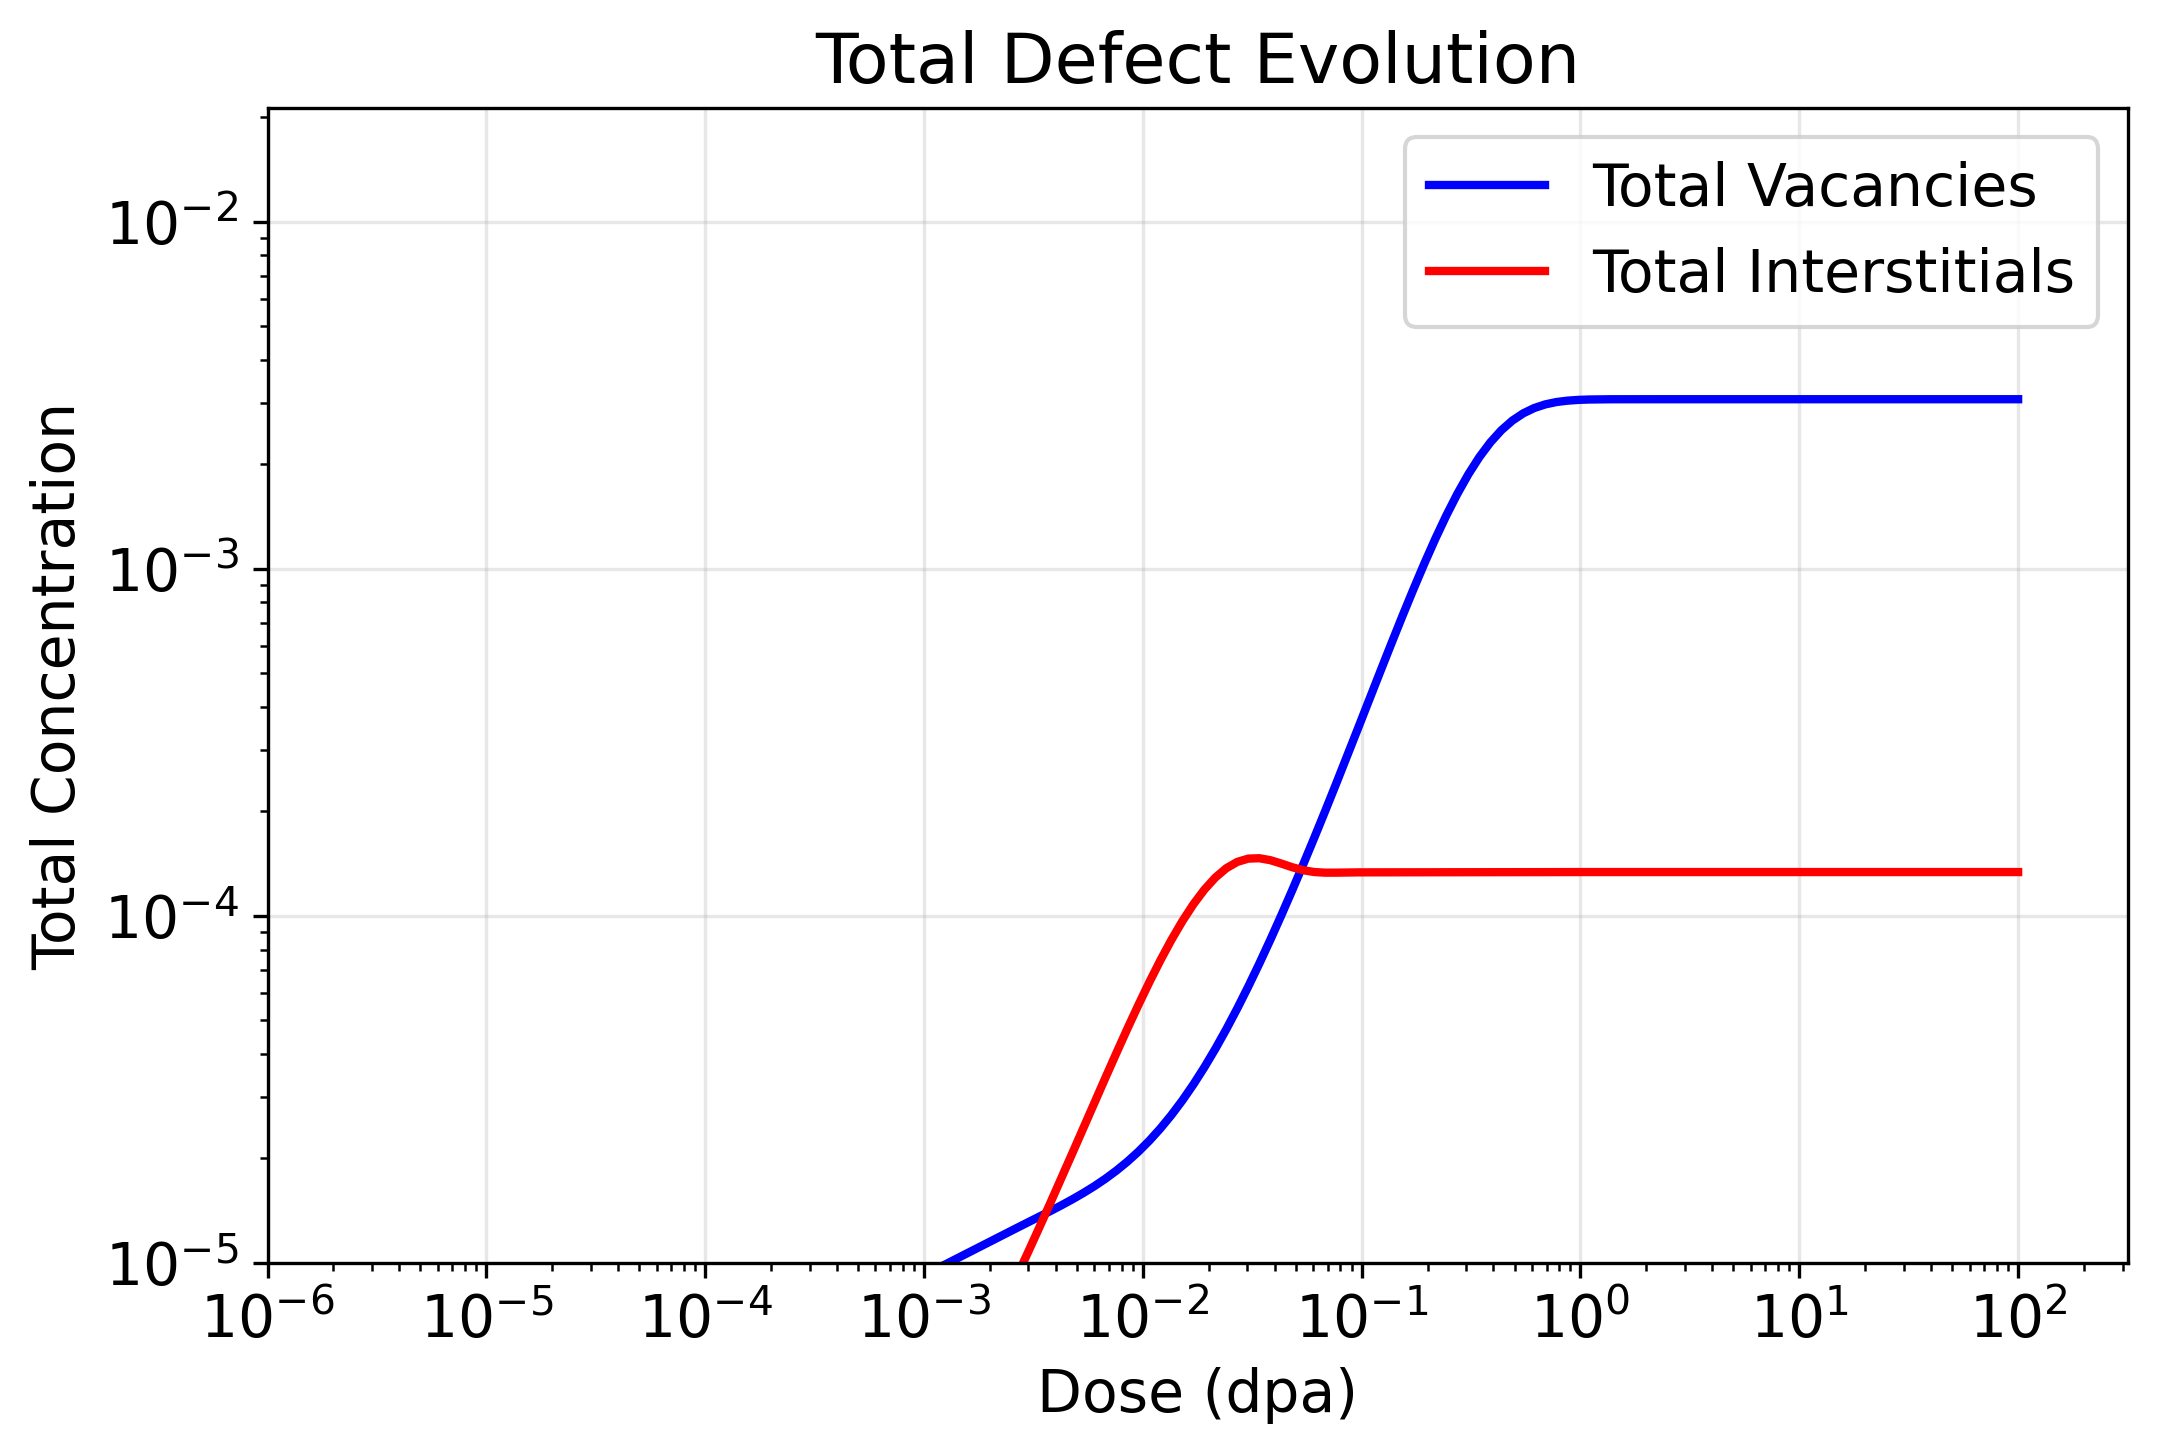


vacancy_fractions.png


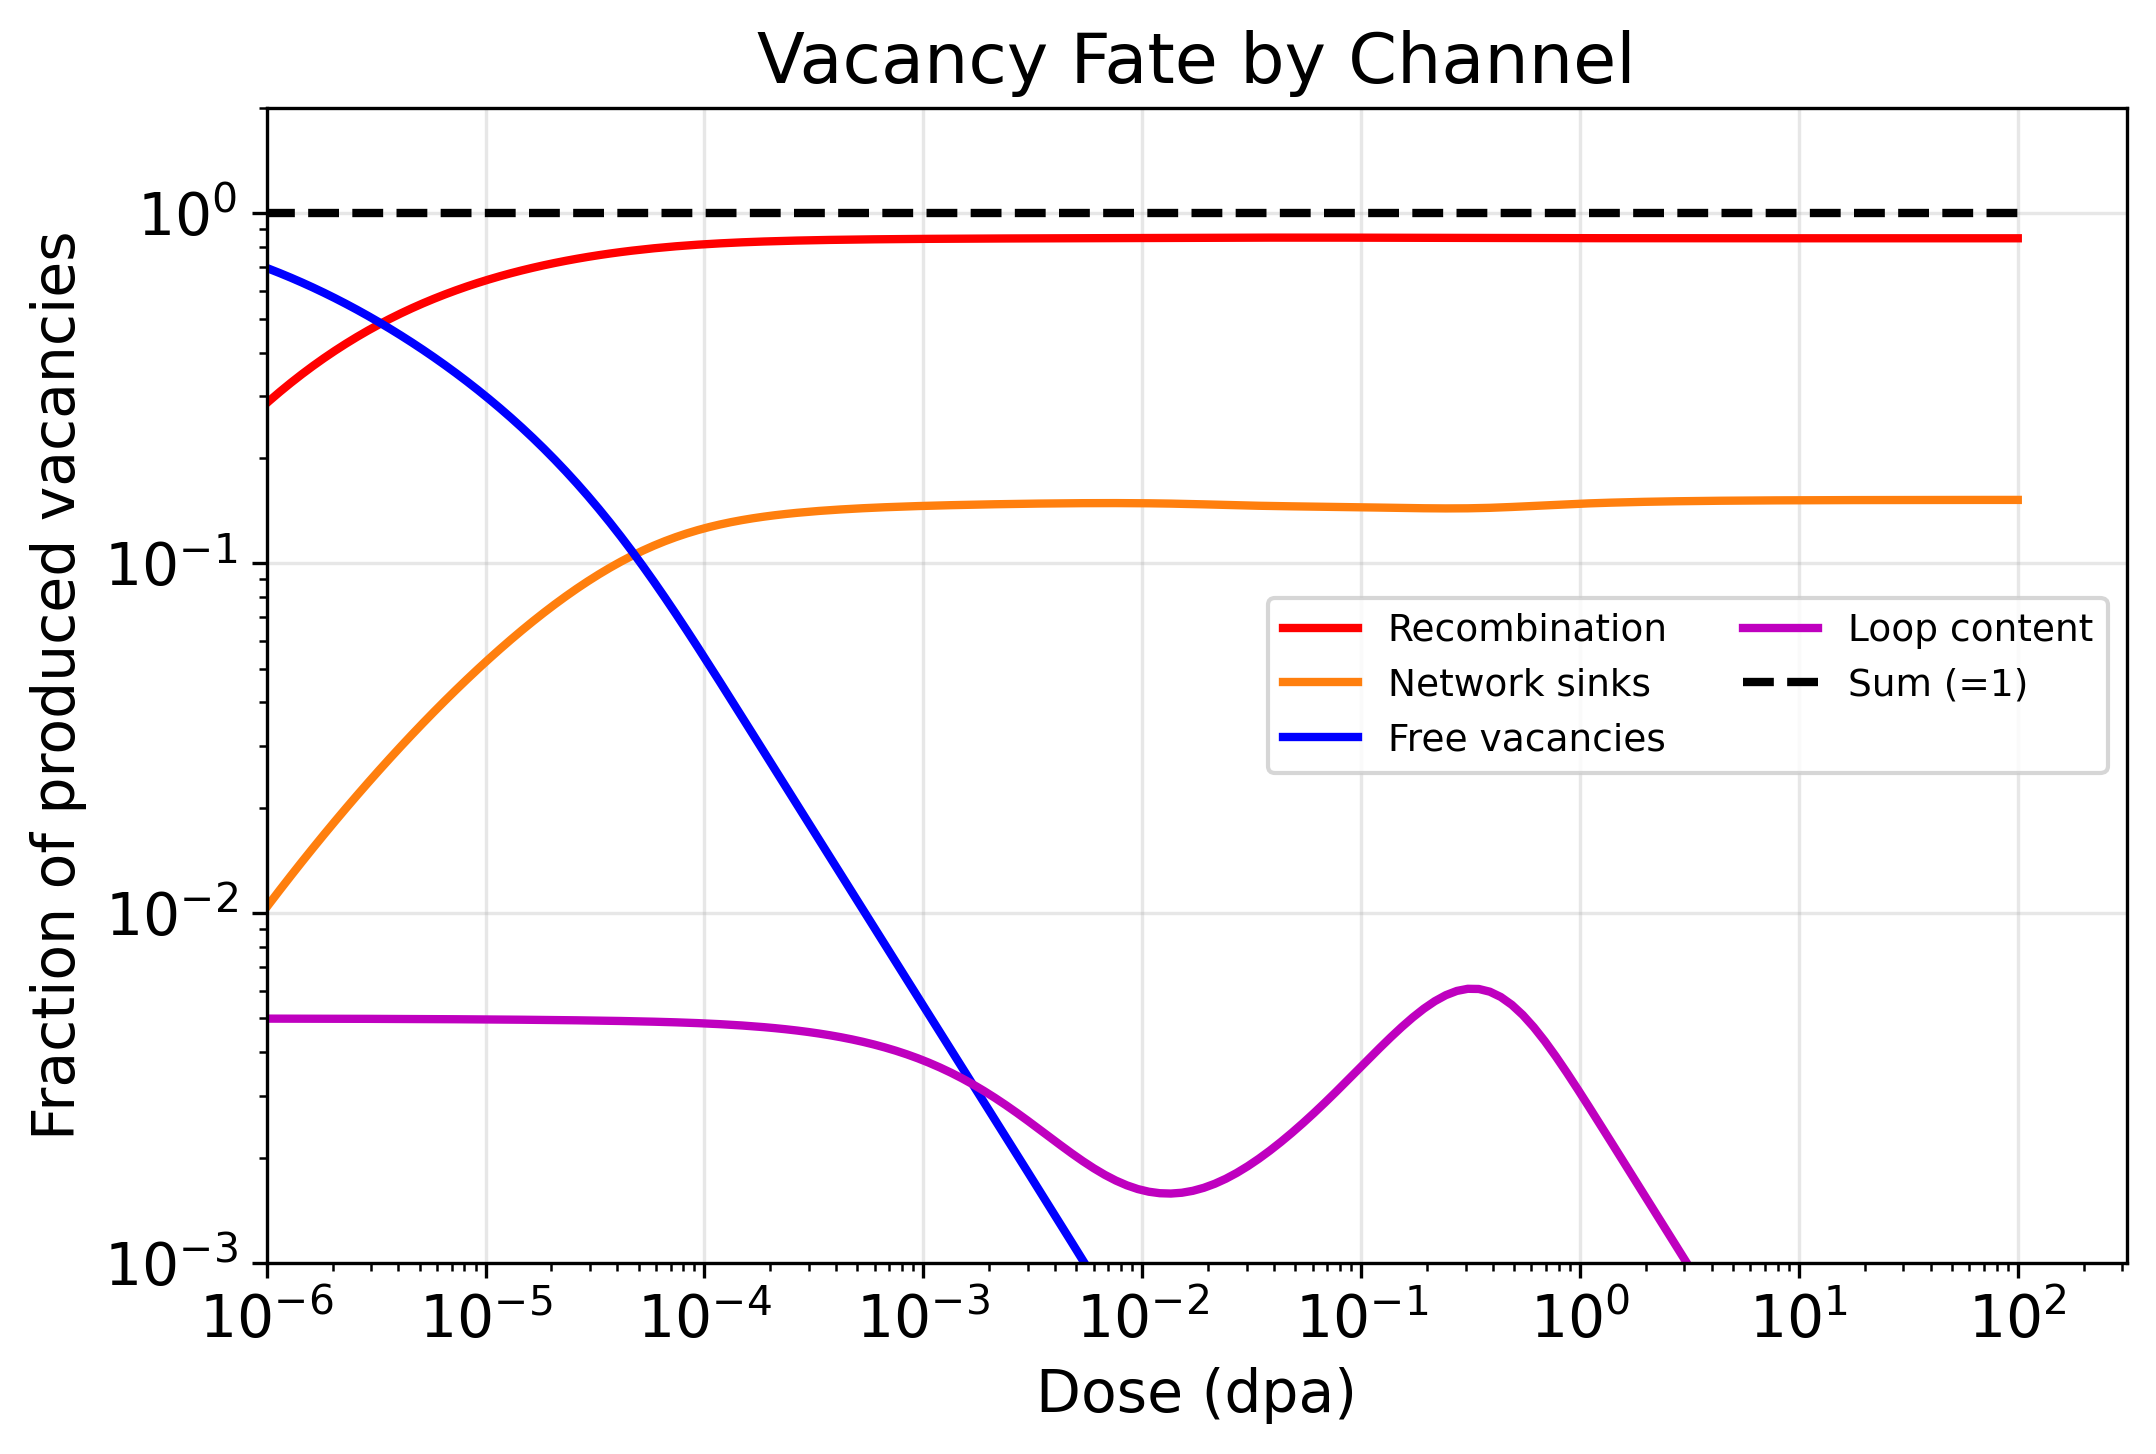


✓ All outputs saved to:
  D:\GitHub\ZrClusterDynamics\ZrMicro\output\20260622_144021_7959445

Contents:
  additional_analysis.csv
  conservation_channels_i.png
  conservation_channels_v.png
  conservation_error.png
  defect_imbalance.png
  flux_evolution.png
  interstitial_fractions.png
  irradiation_growth.png
  loop_density.png
  loop_density_analysis.png
  net_flux_balance.png
  point_defects.png
  provenance.md
  radiation_hardening.png
  strain_rates.png
  total_defect_evolution.png
  vacancy_fractions.png

Running model at representative temperatures: 473 K, 523 K, 573 K, 583 K, 623 K, 673 K
Initializing ZrMicro simulation...
Loading input data from D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx...
InputData: Attempting to load D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
✓ File exists: D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx
Reading Excel file: D:\GitHub\ZrClusterDynamics\ZrMicro\input\Zr_input_parameters.xlsx

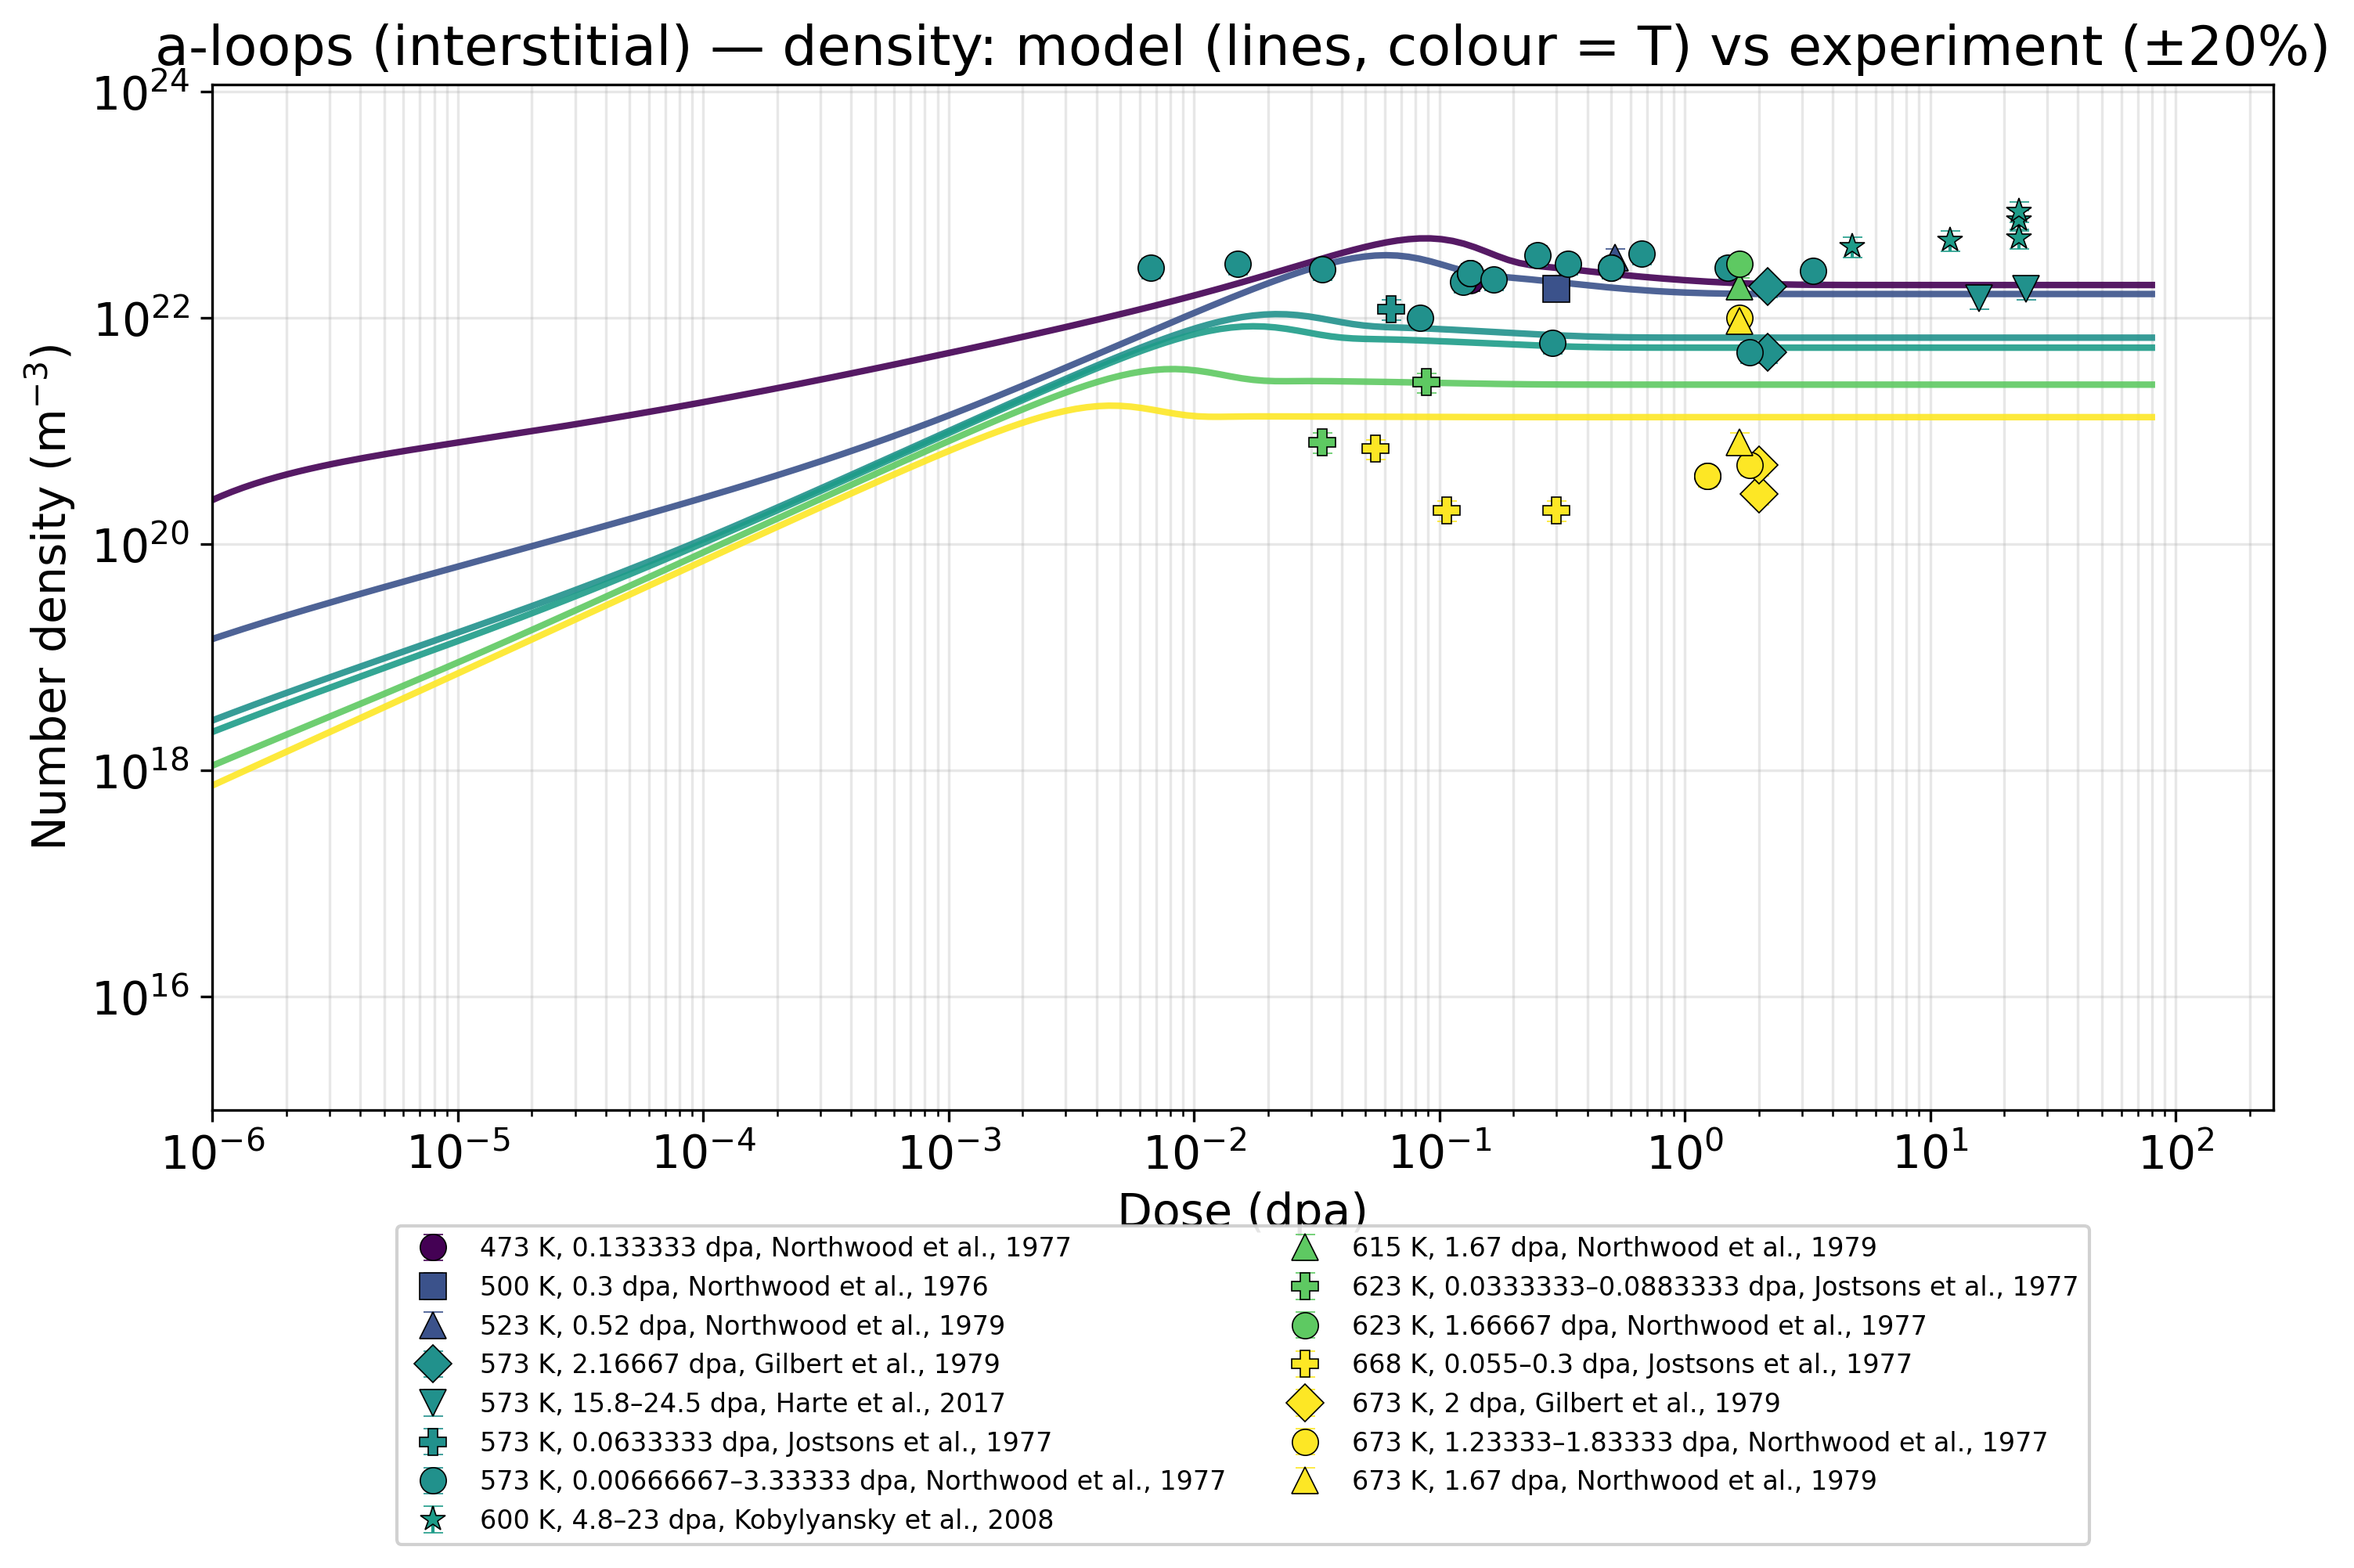

saved aloop_density_vs_experiment.png


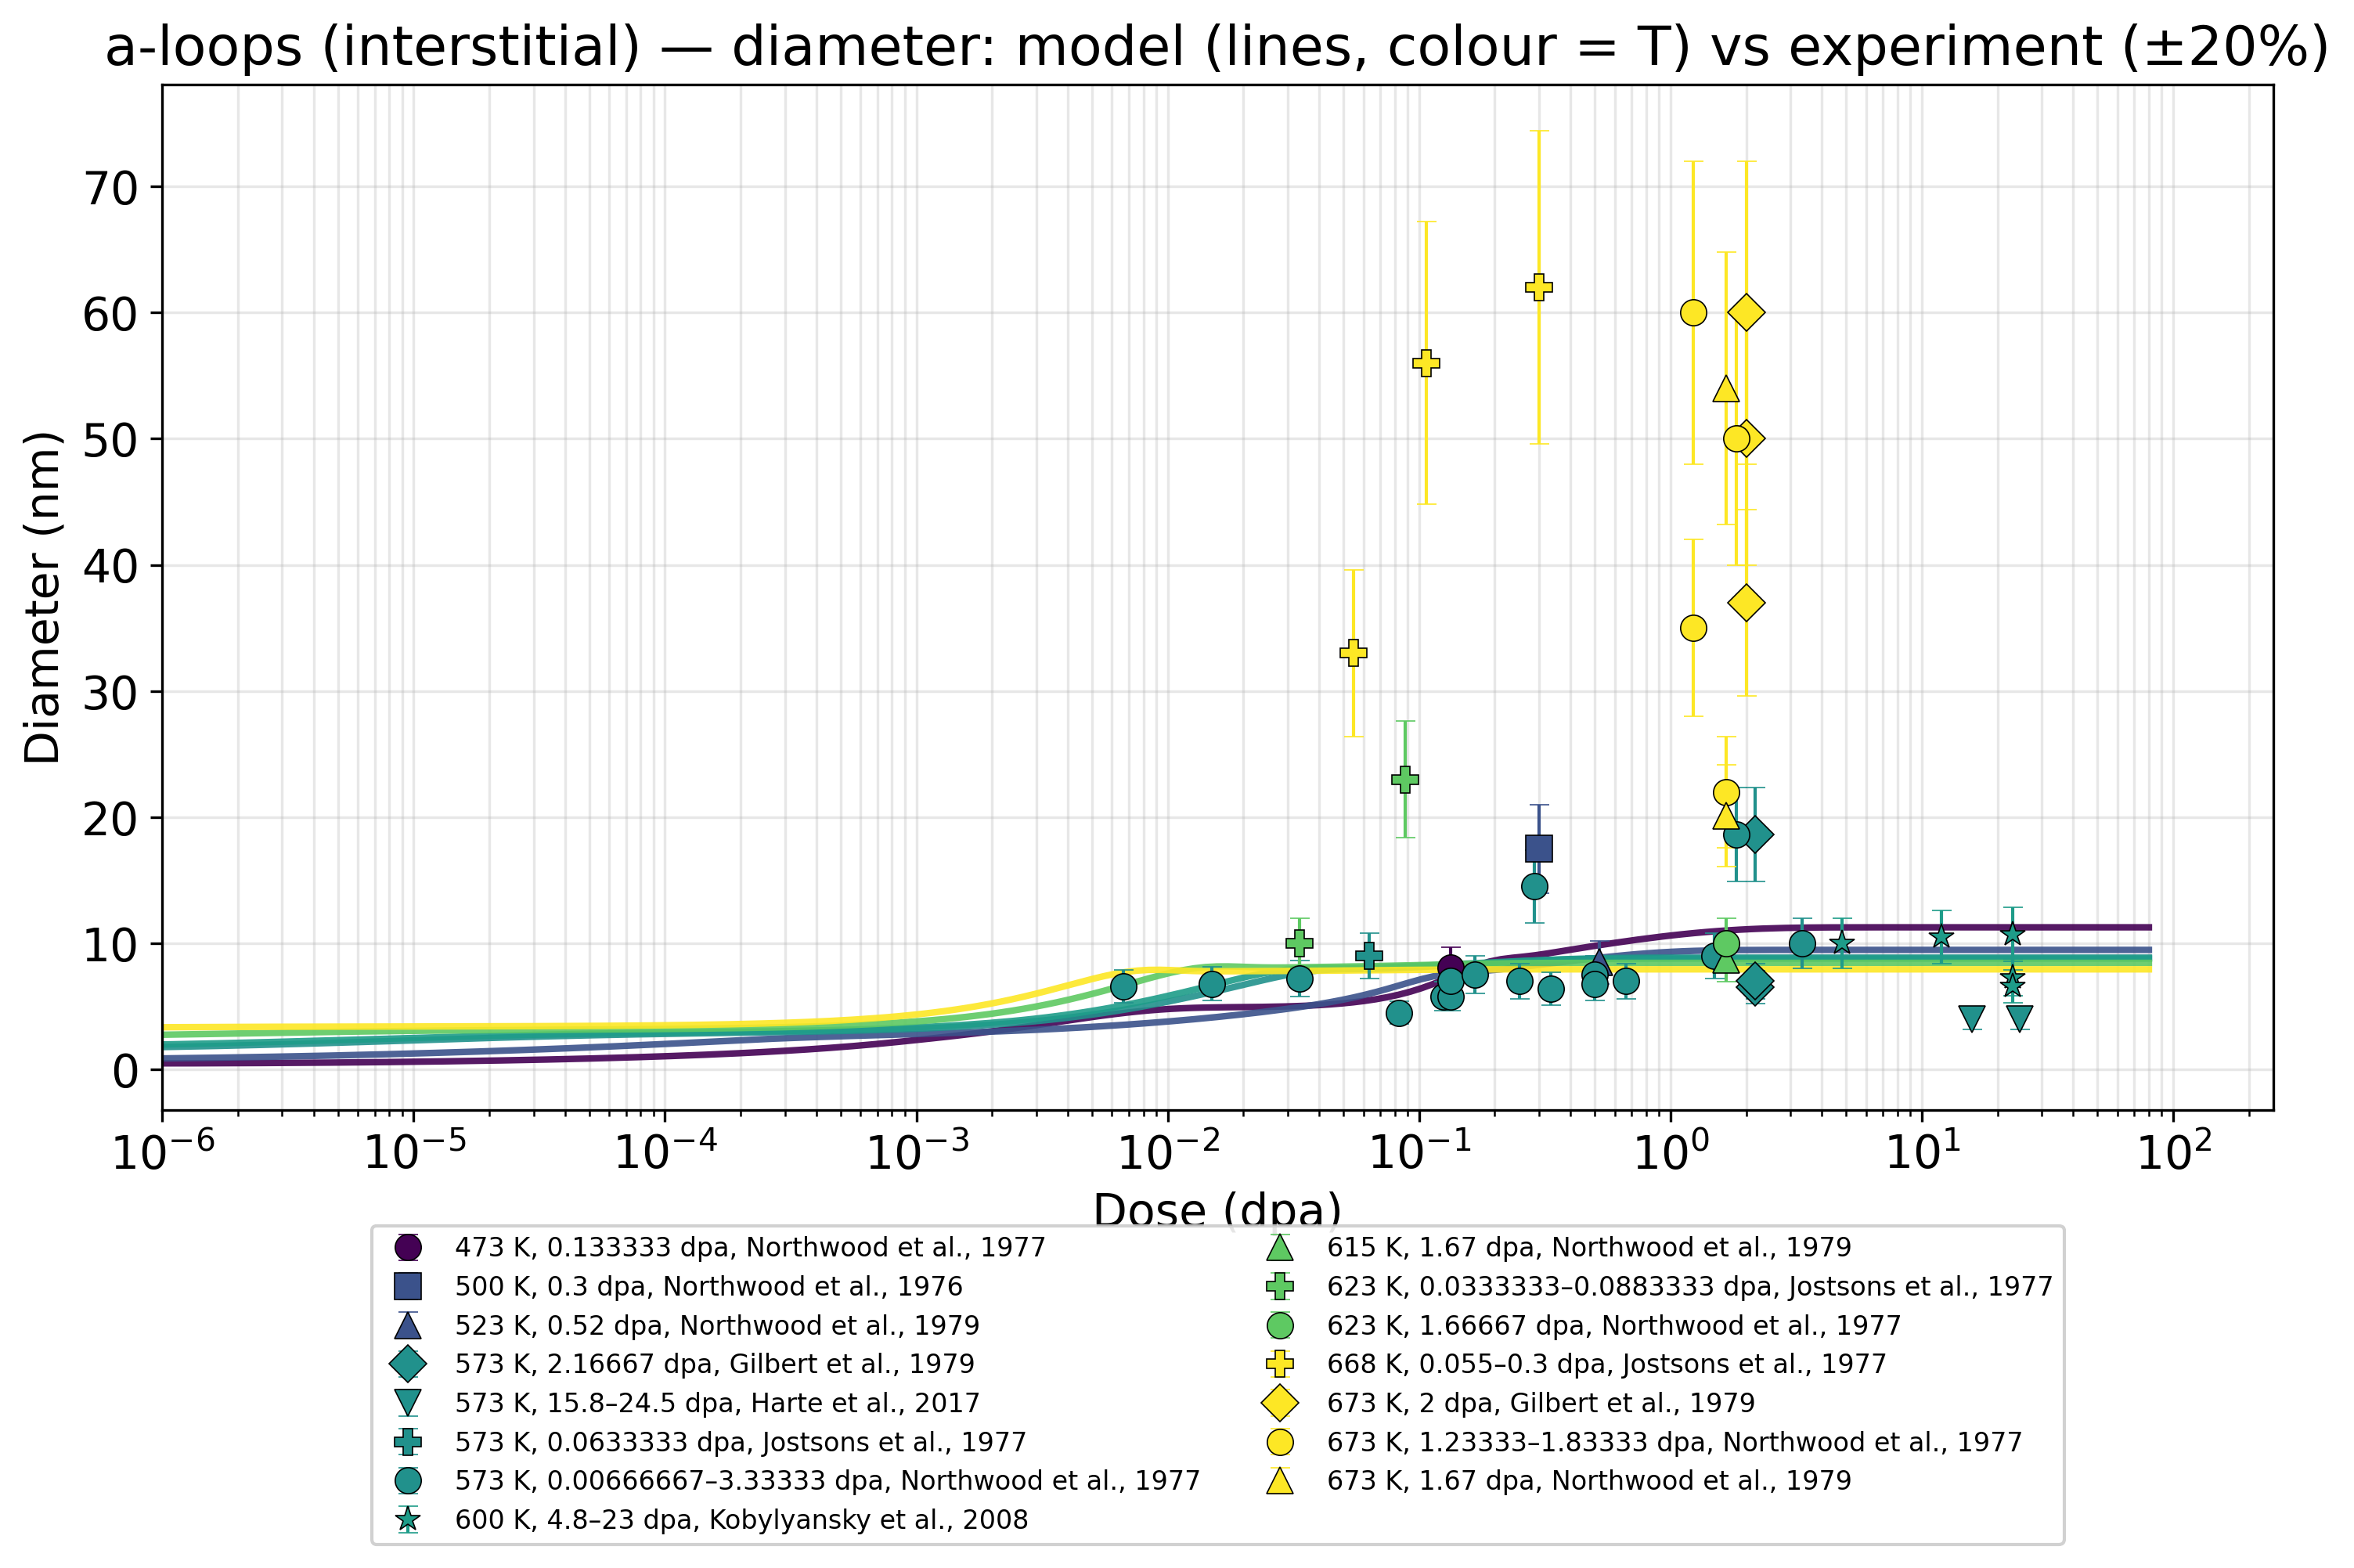

saved aloop_diameter_vs_experiment.png


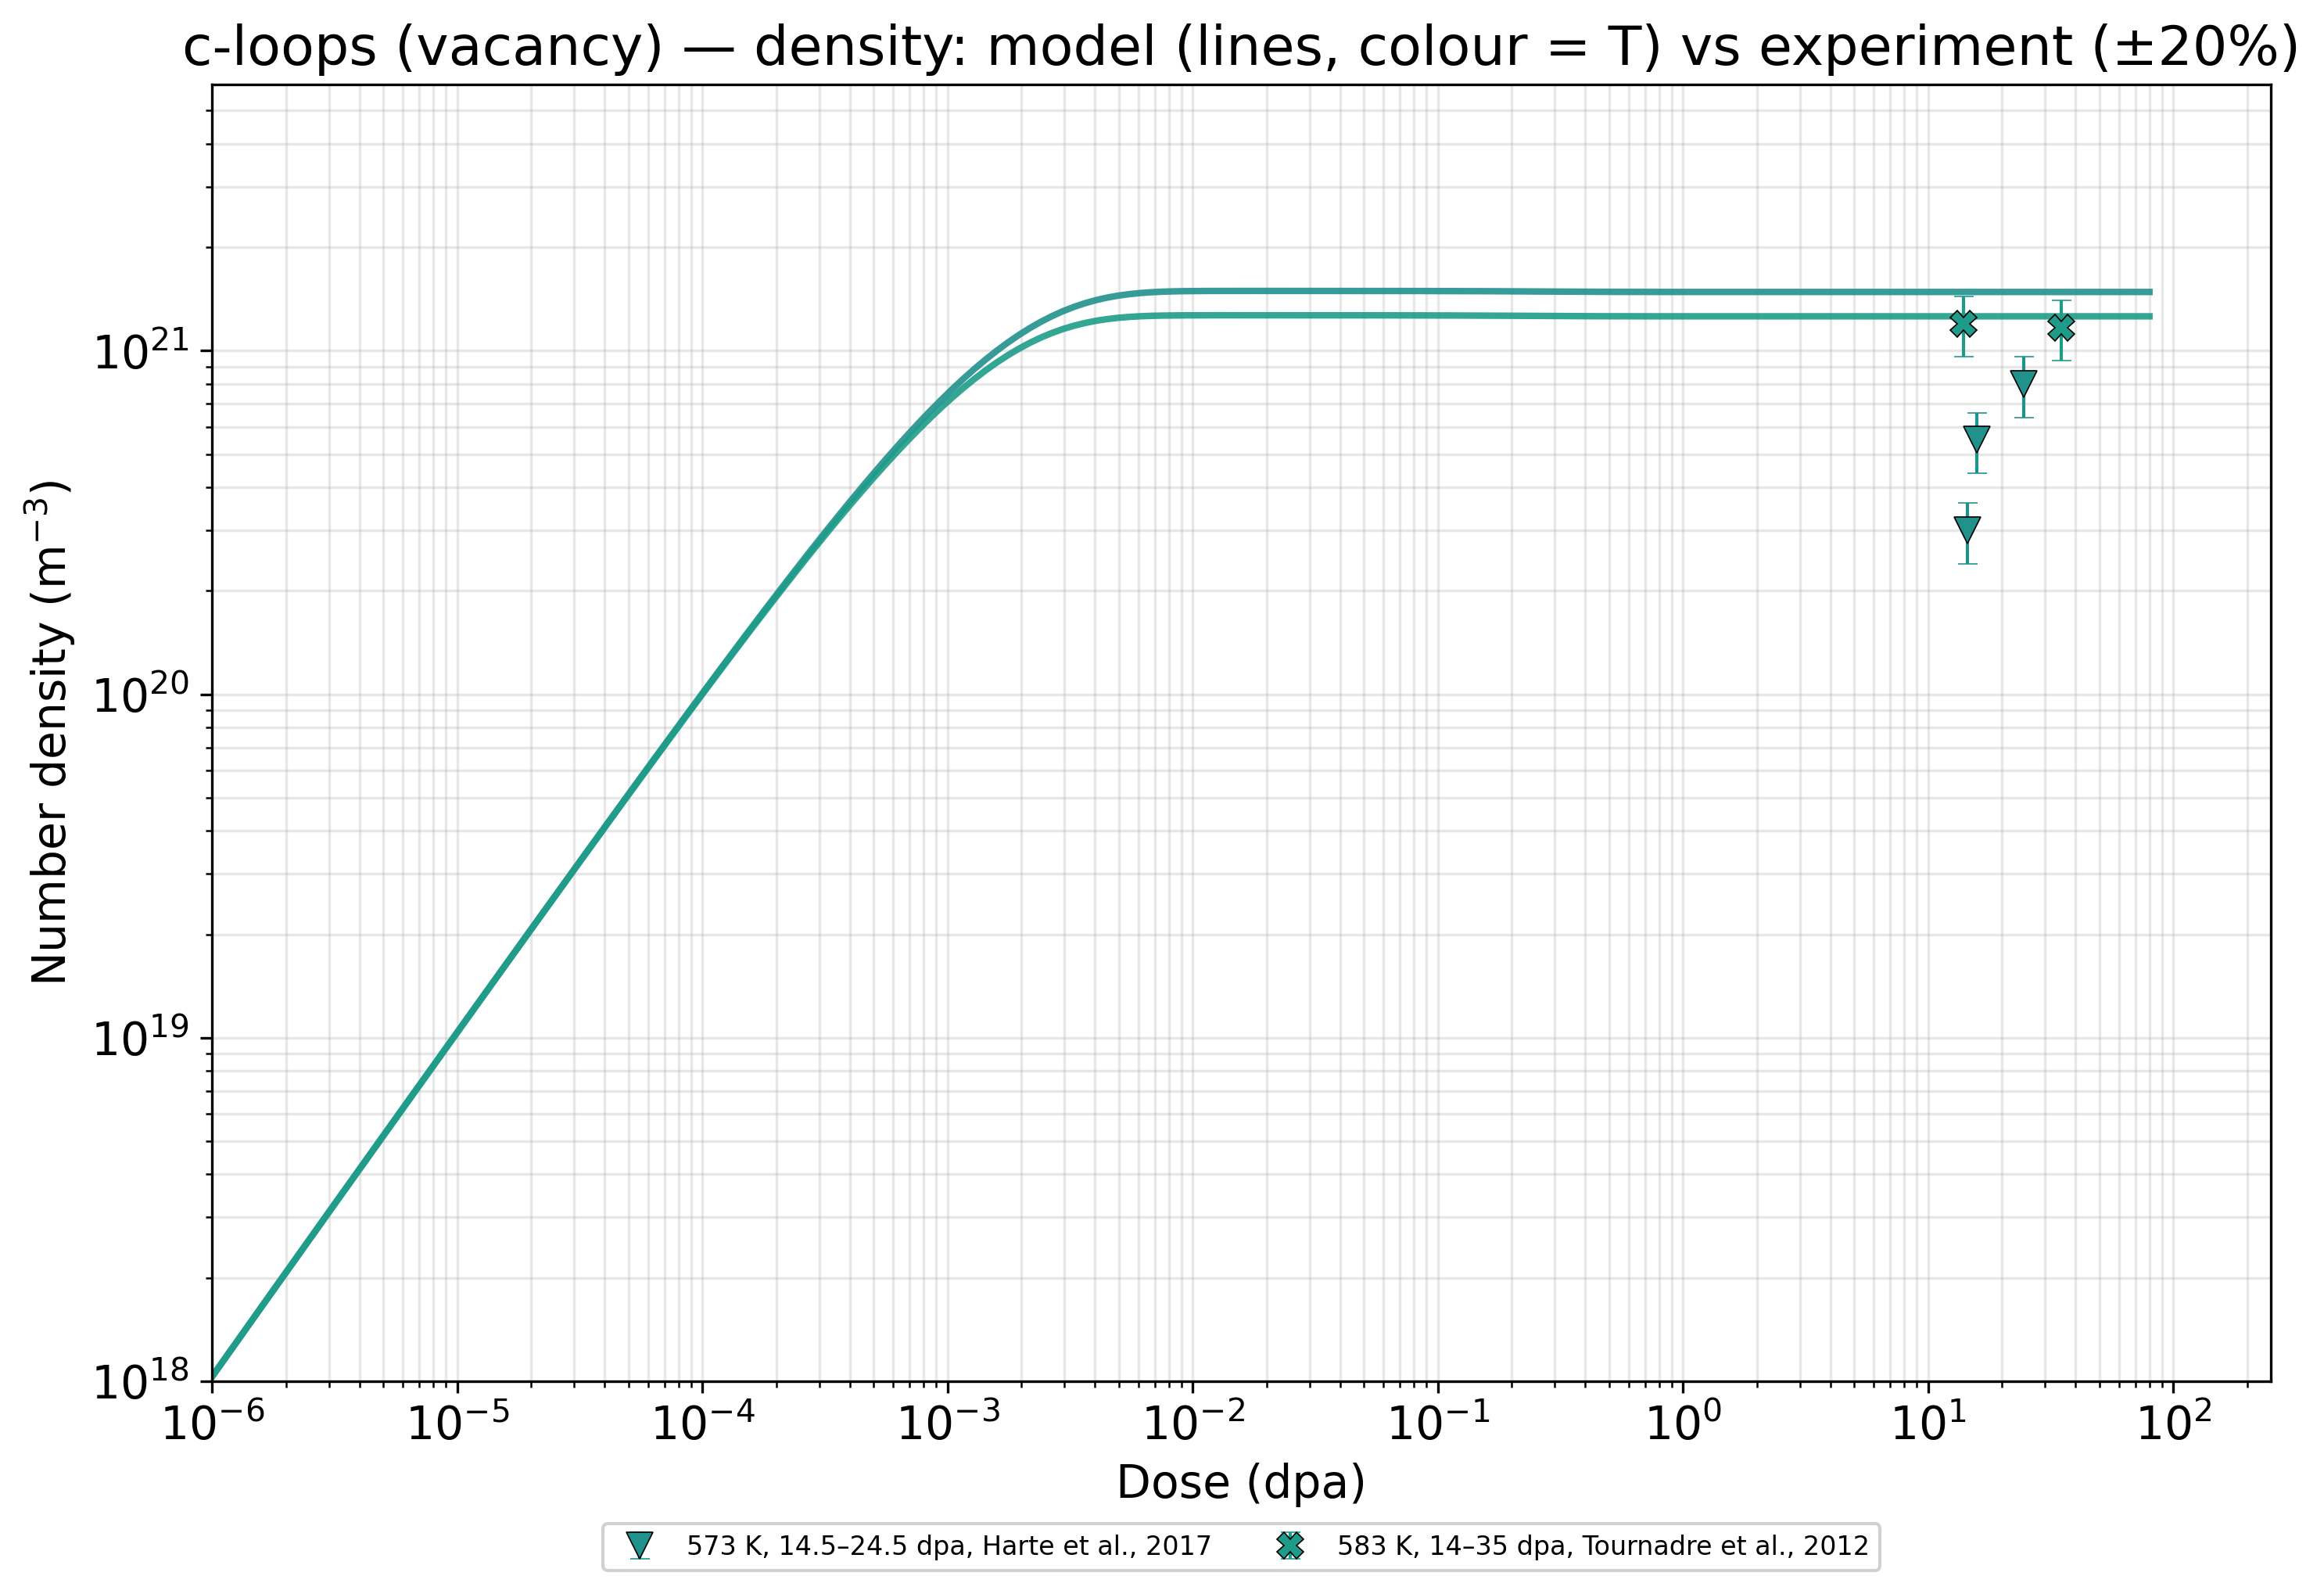

saved cloop_density_vs_experiment.png


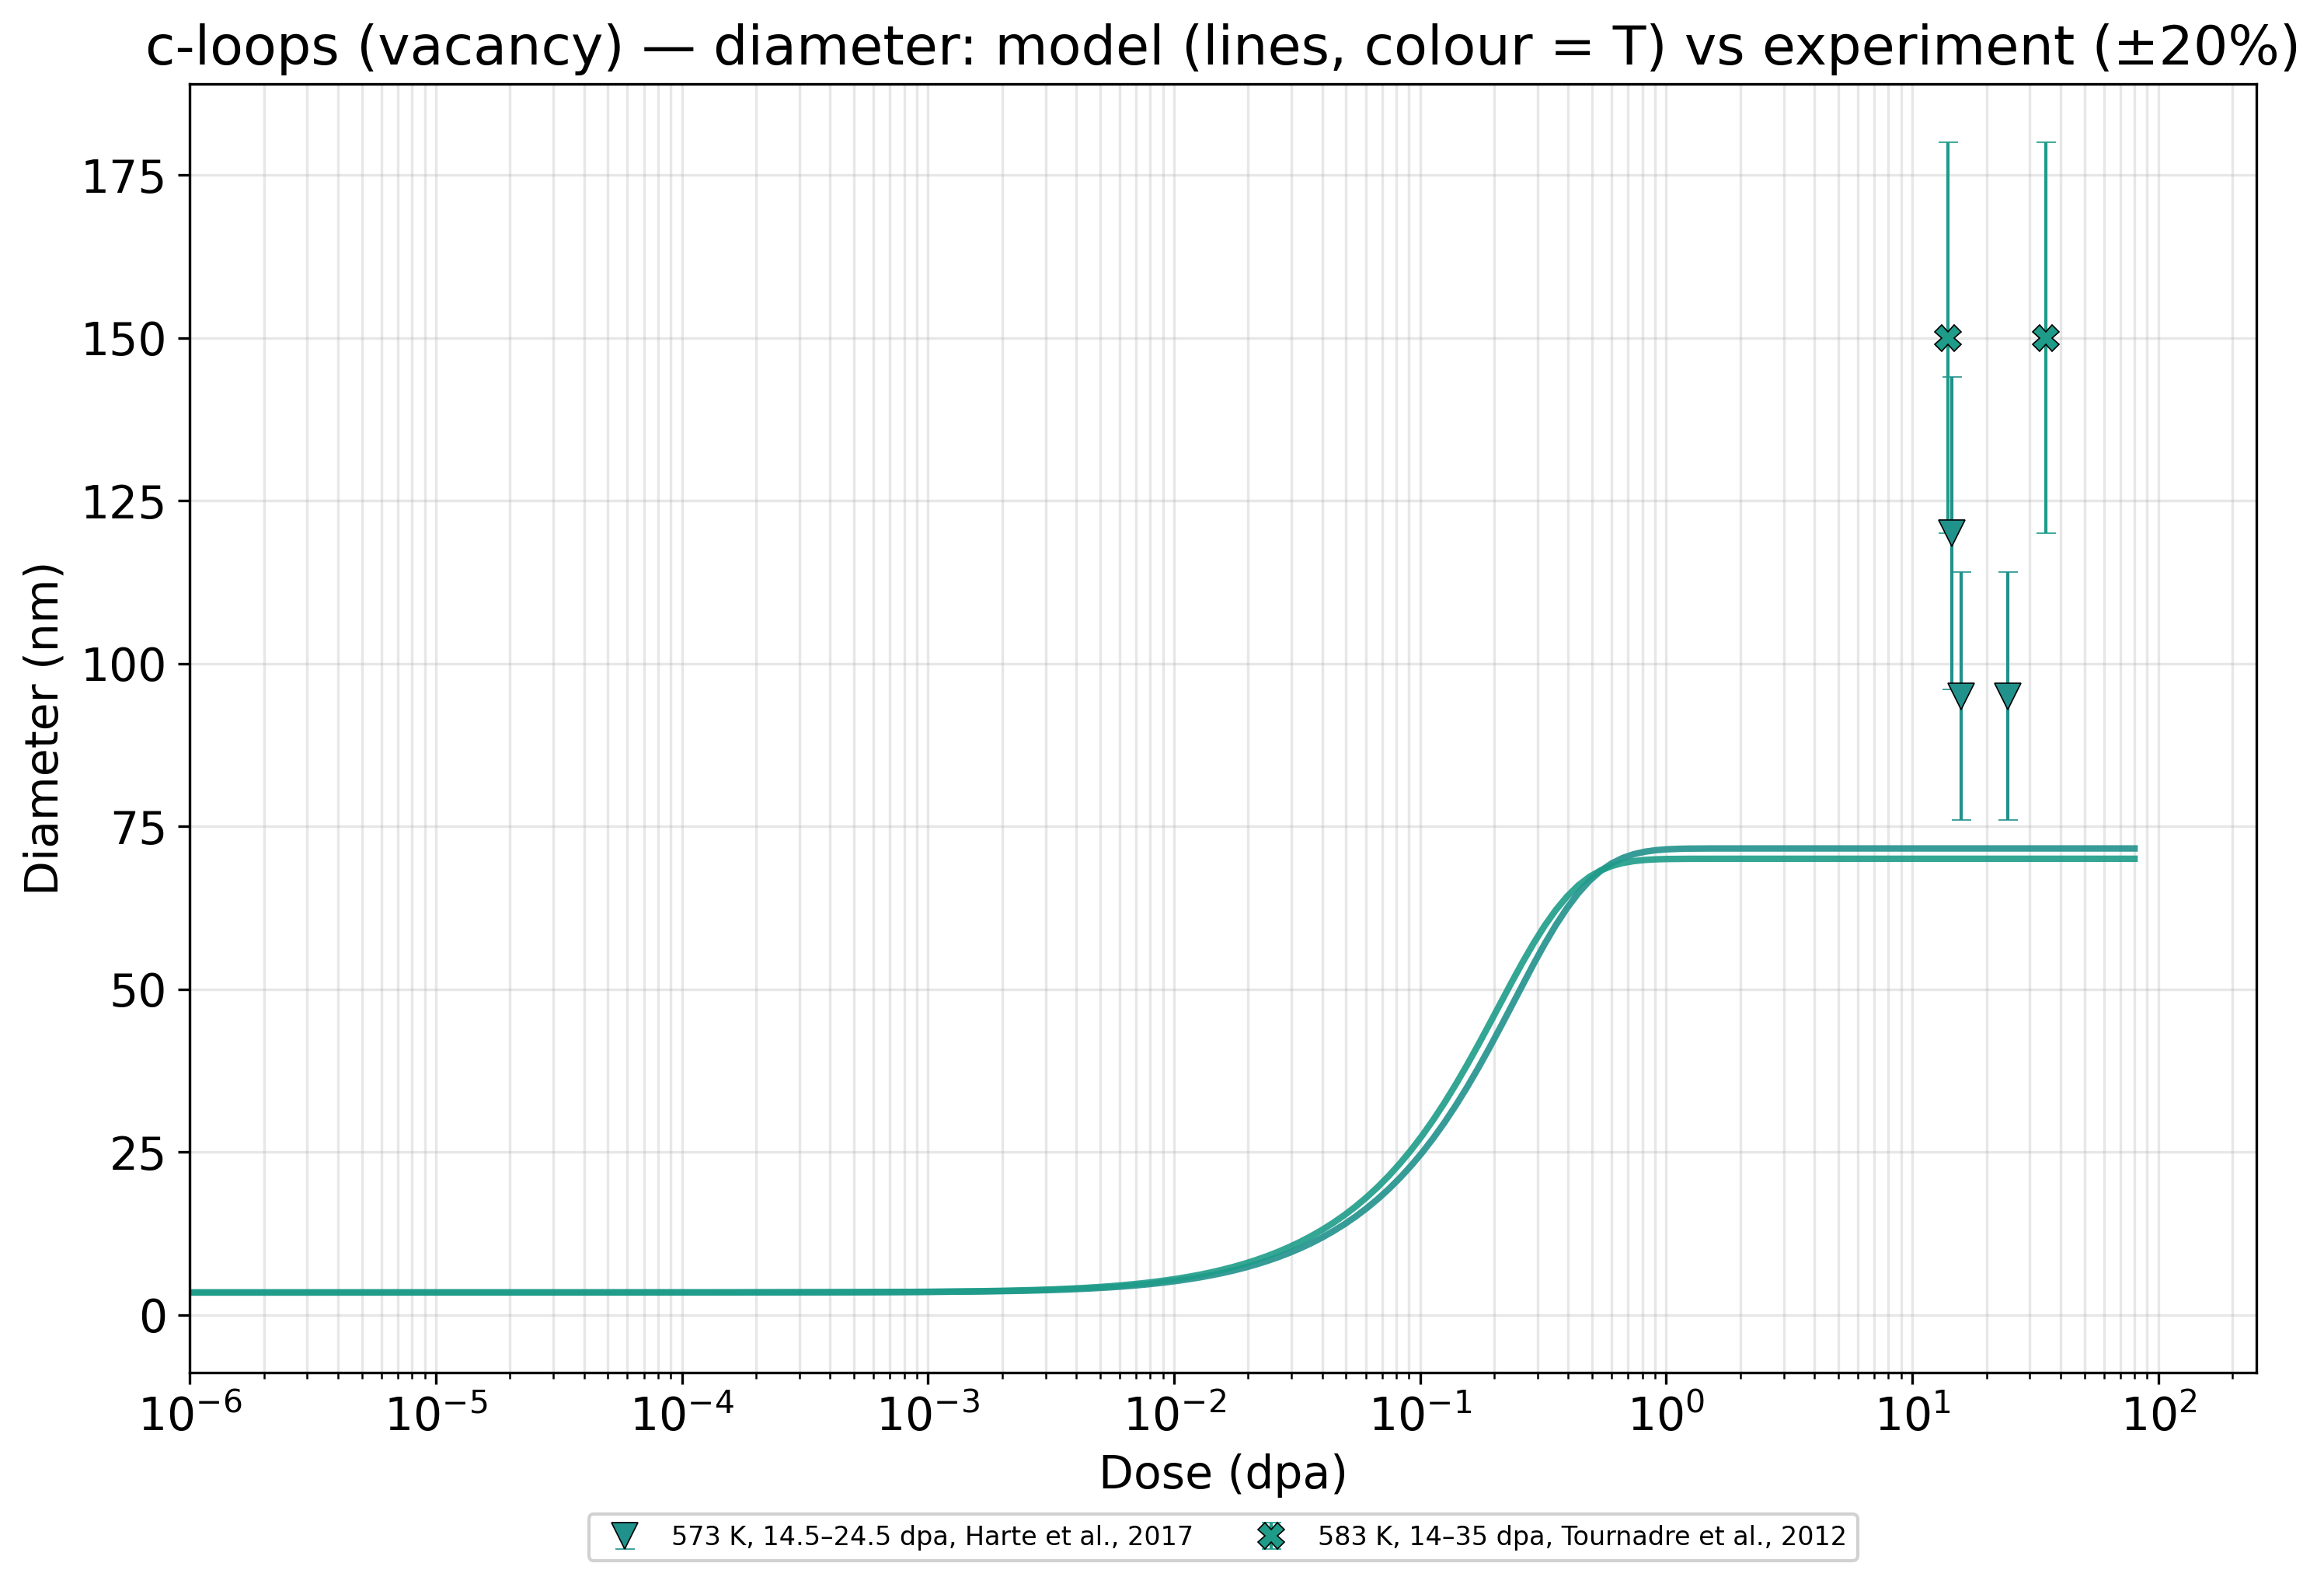

saved cloop_diameter_vs_experiment.png


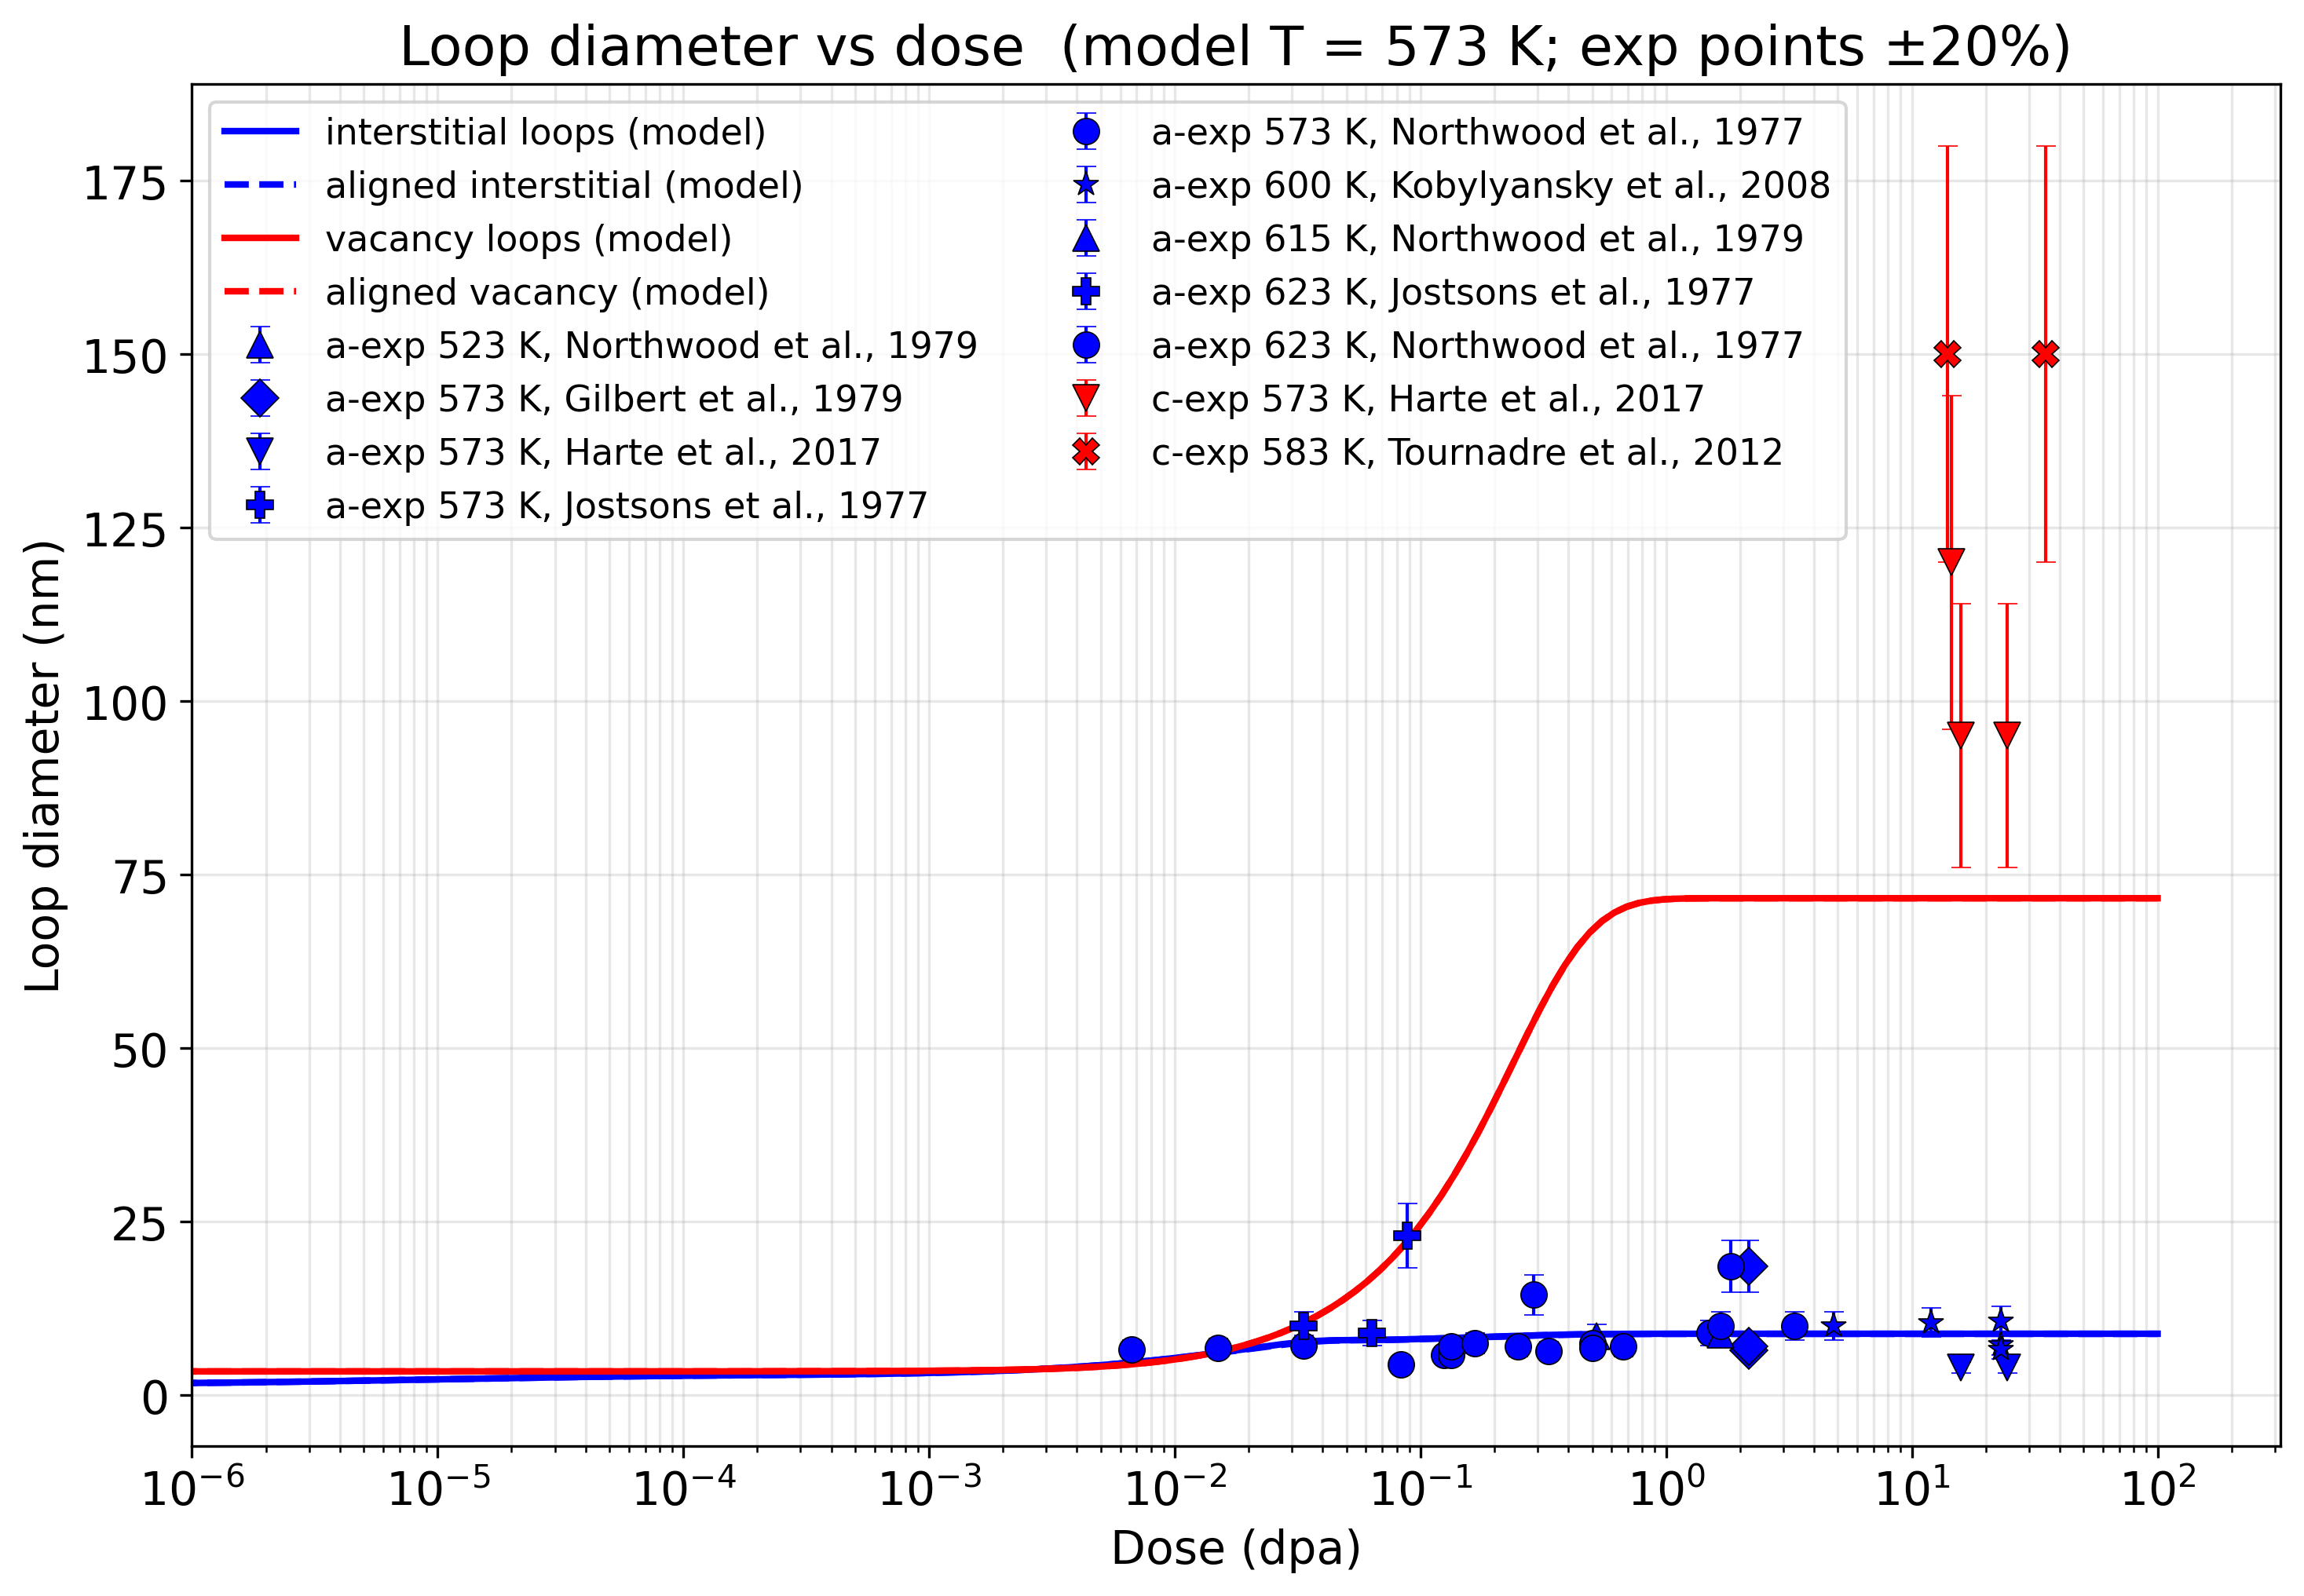

saved loop_diameter_vs_dose.png


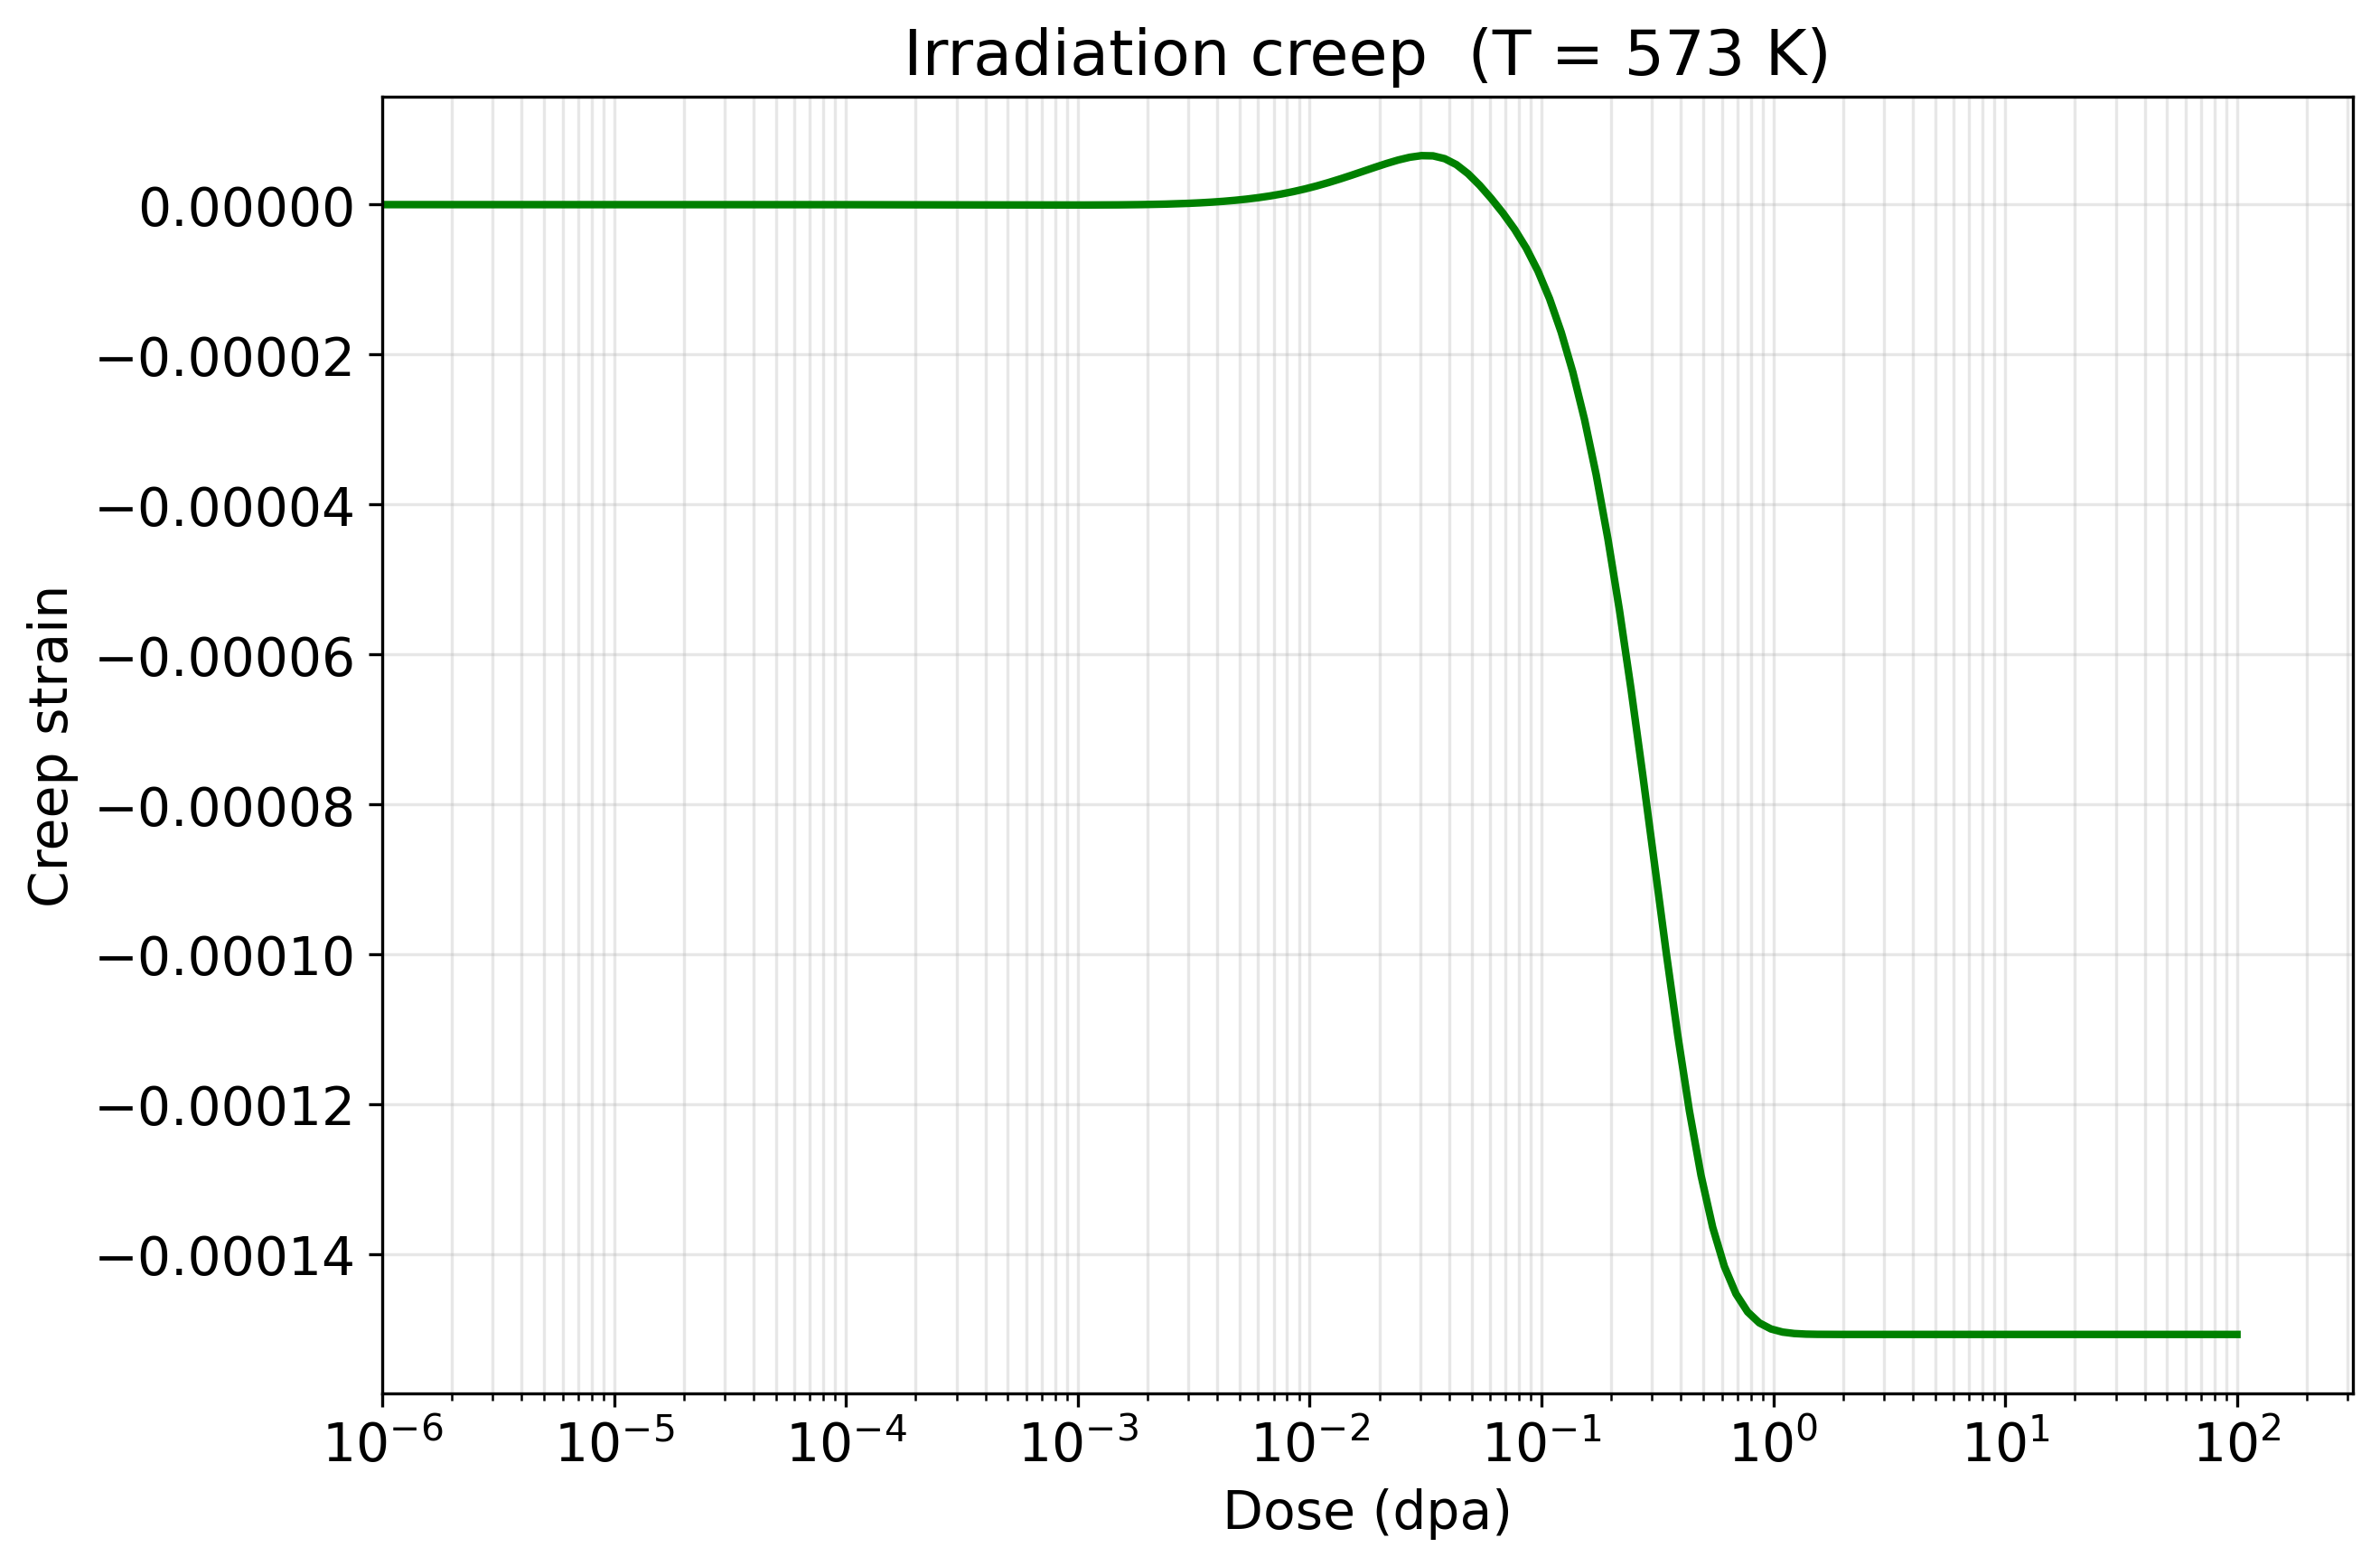

saved creep_vs_dose.png


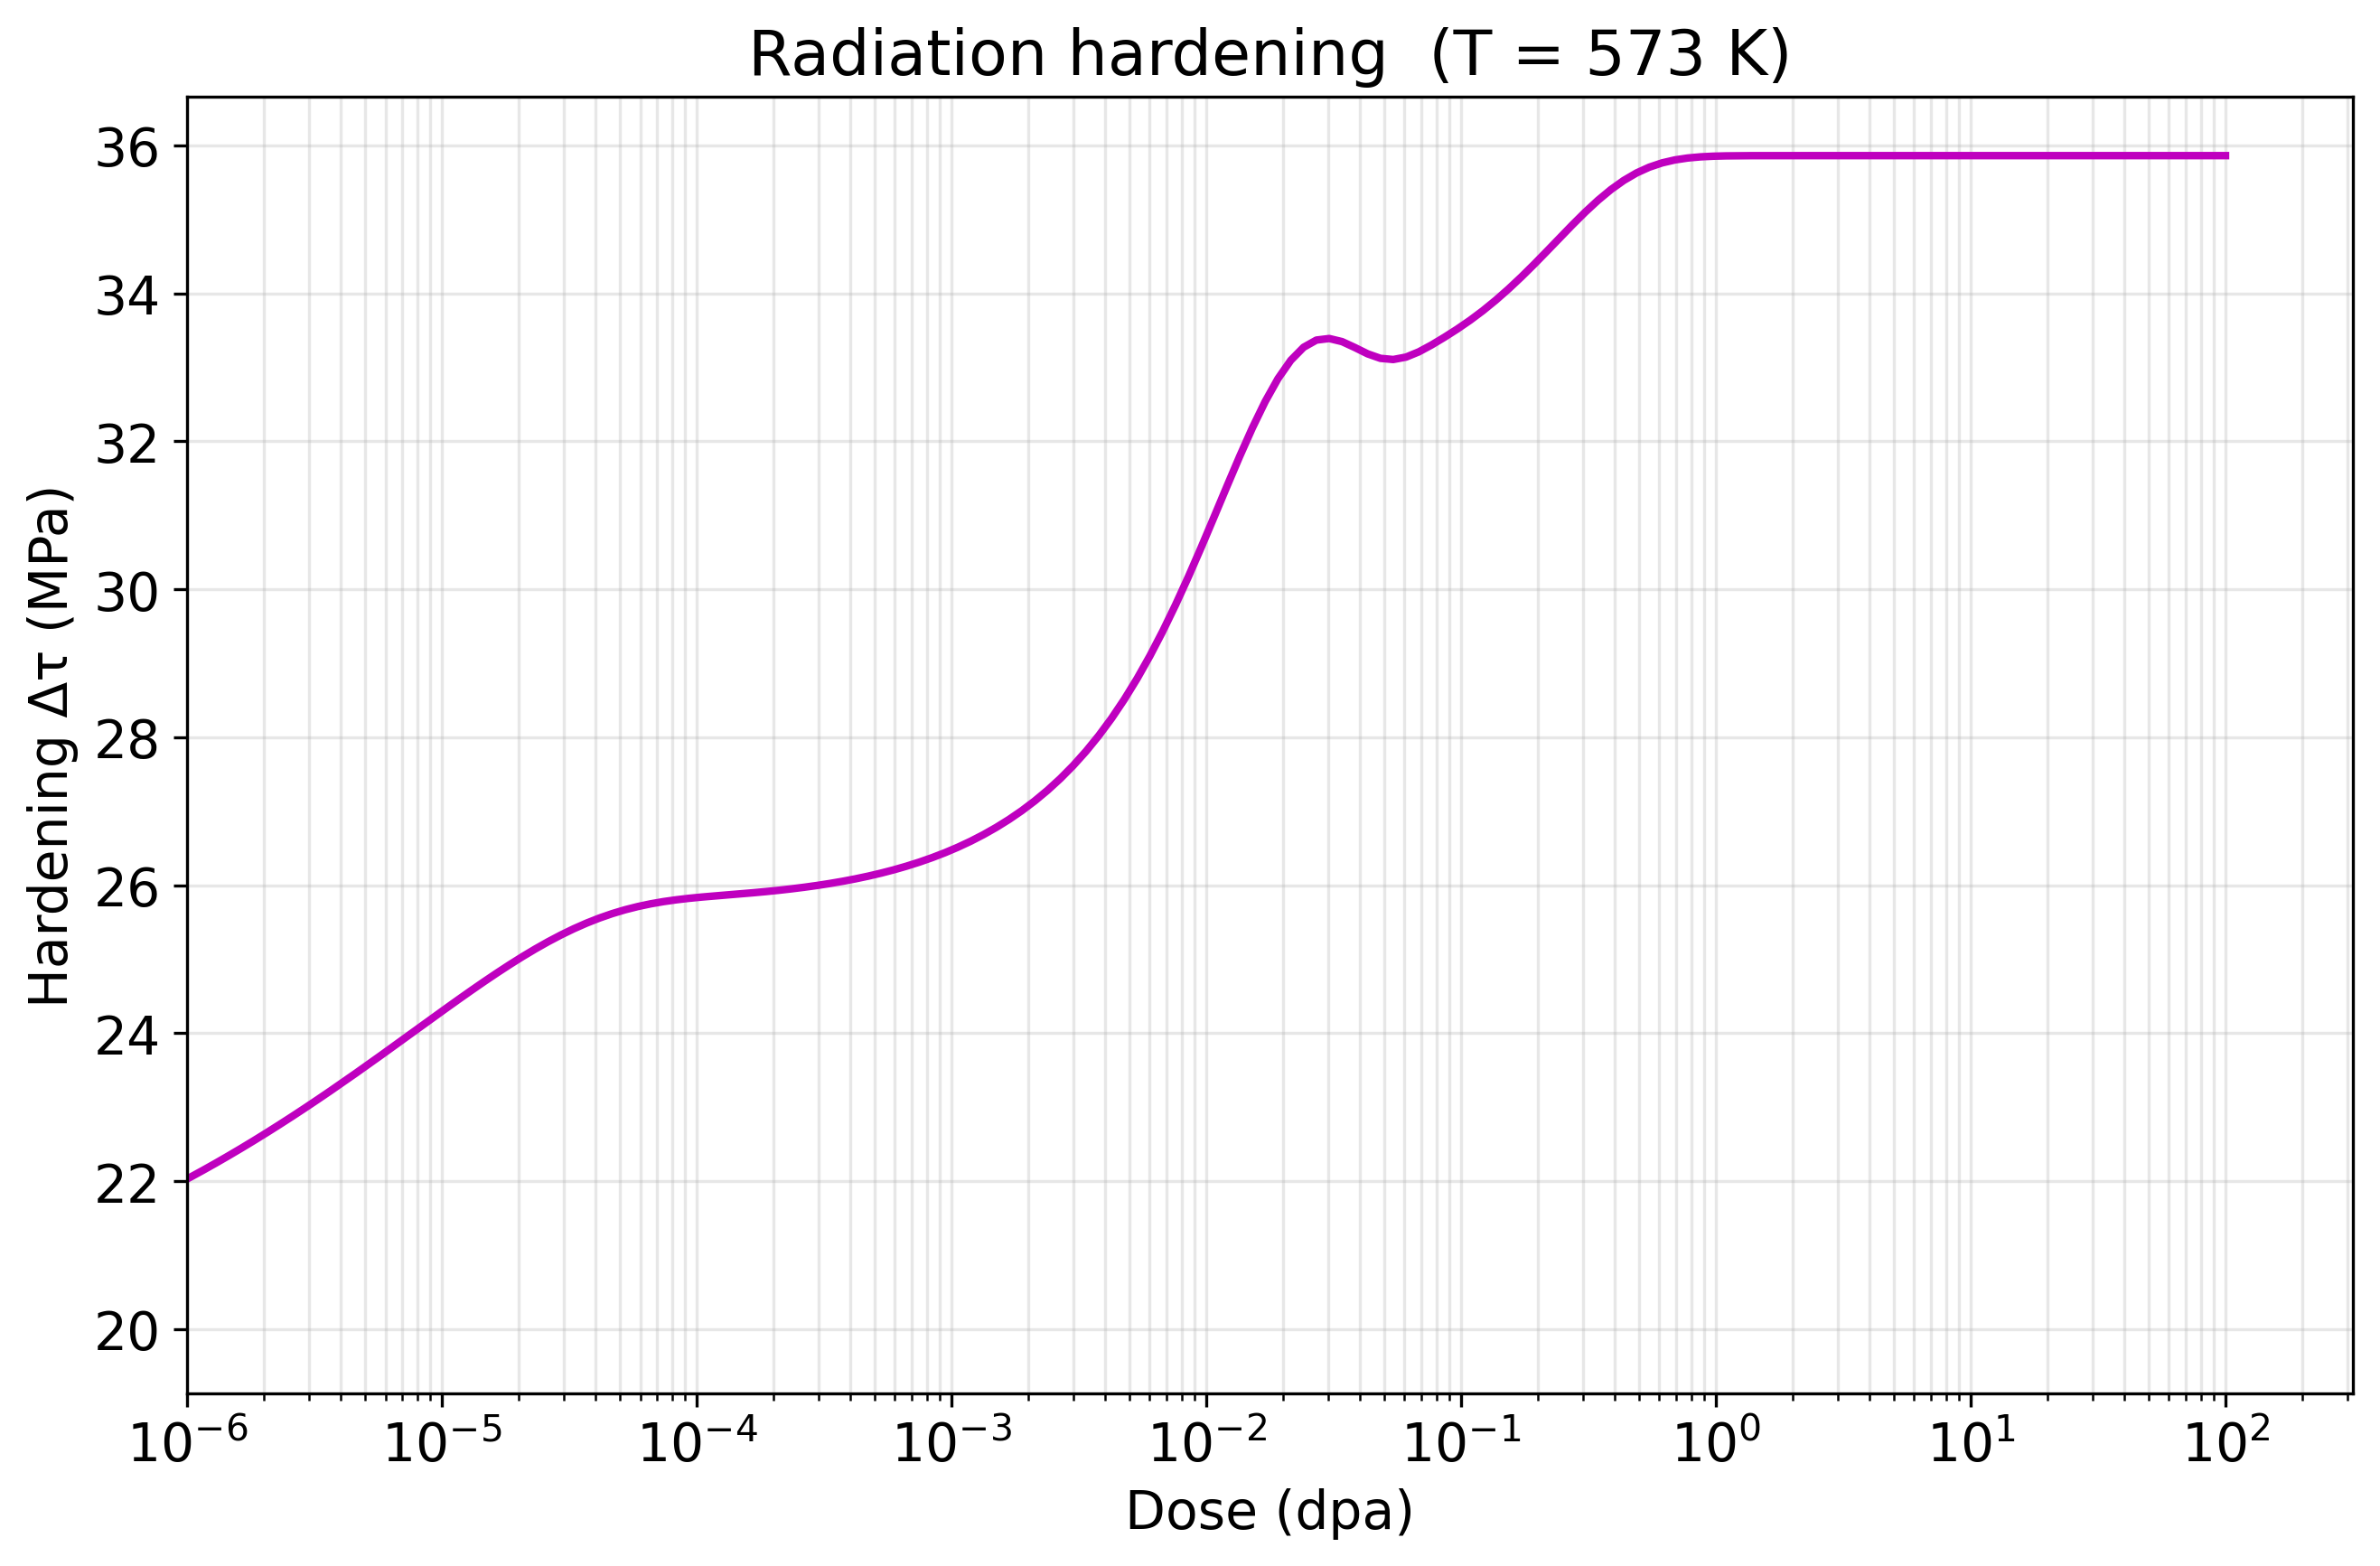

saved hardening_vs_dose.png


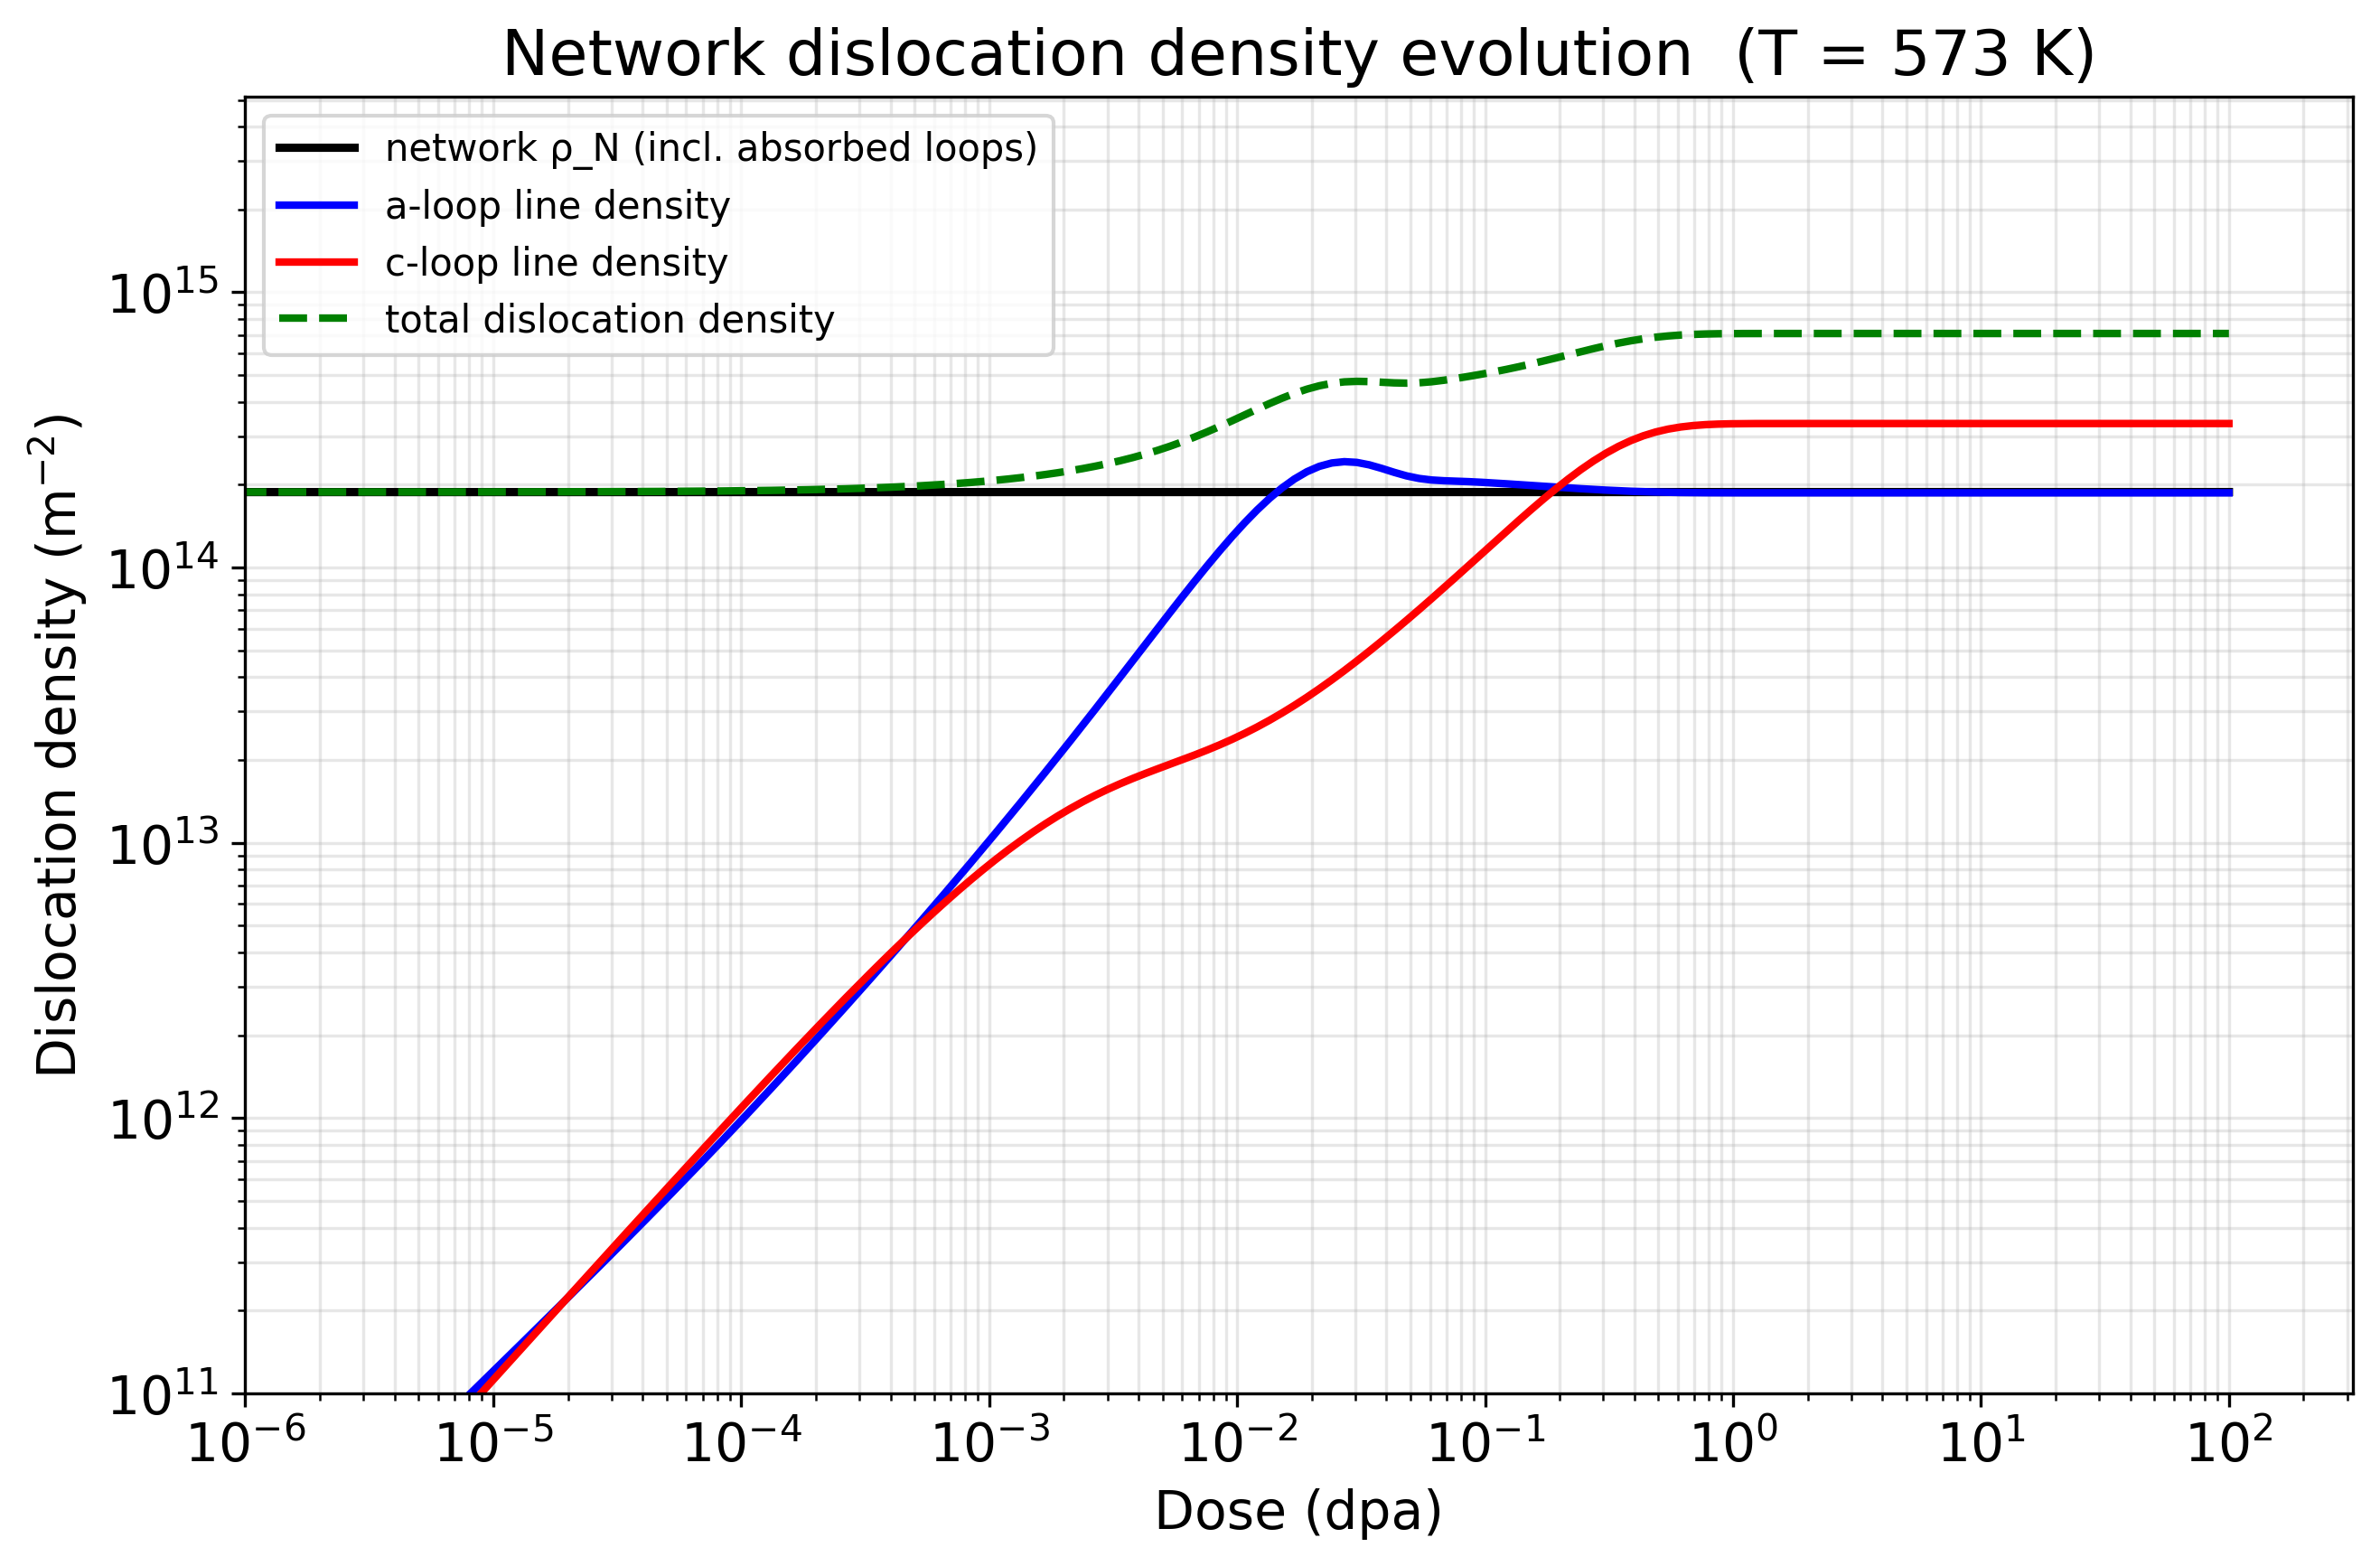

saved network_density_evolution.png


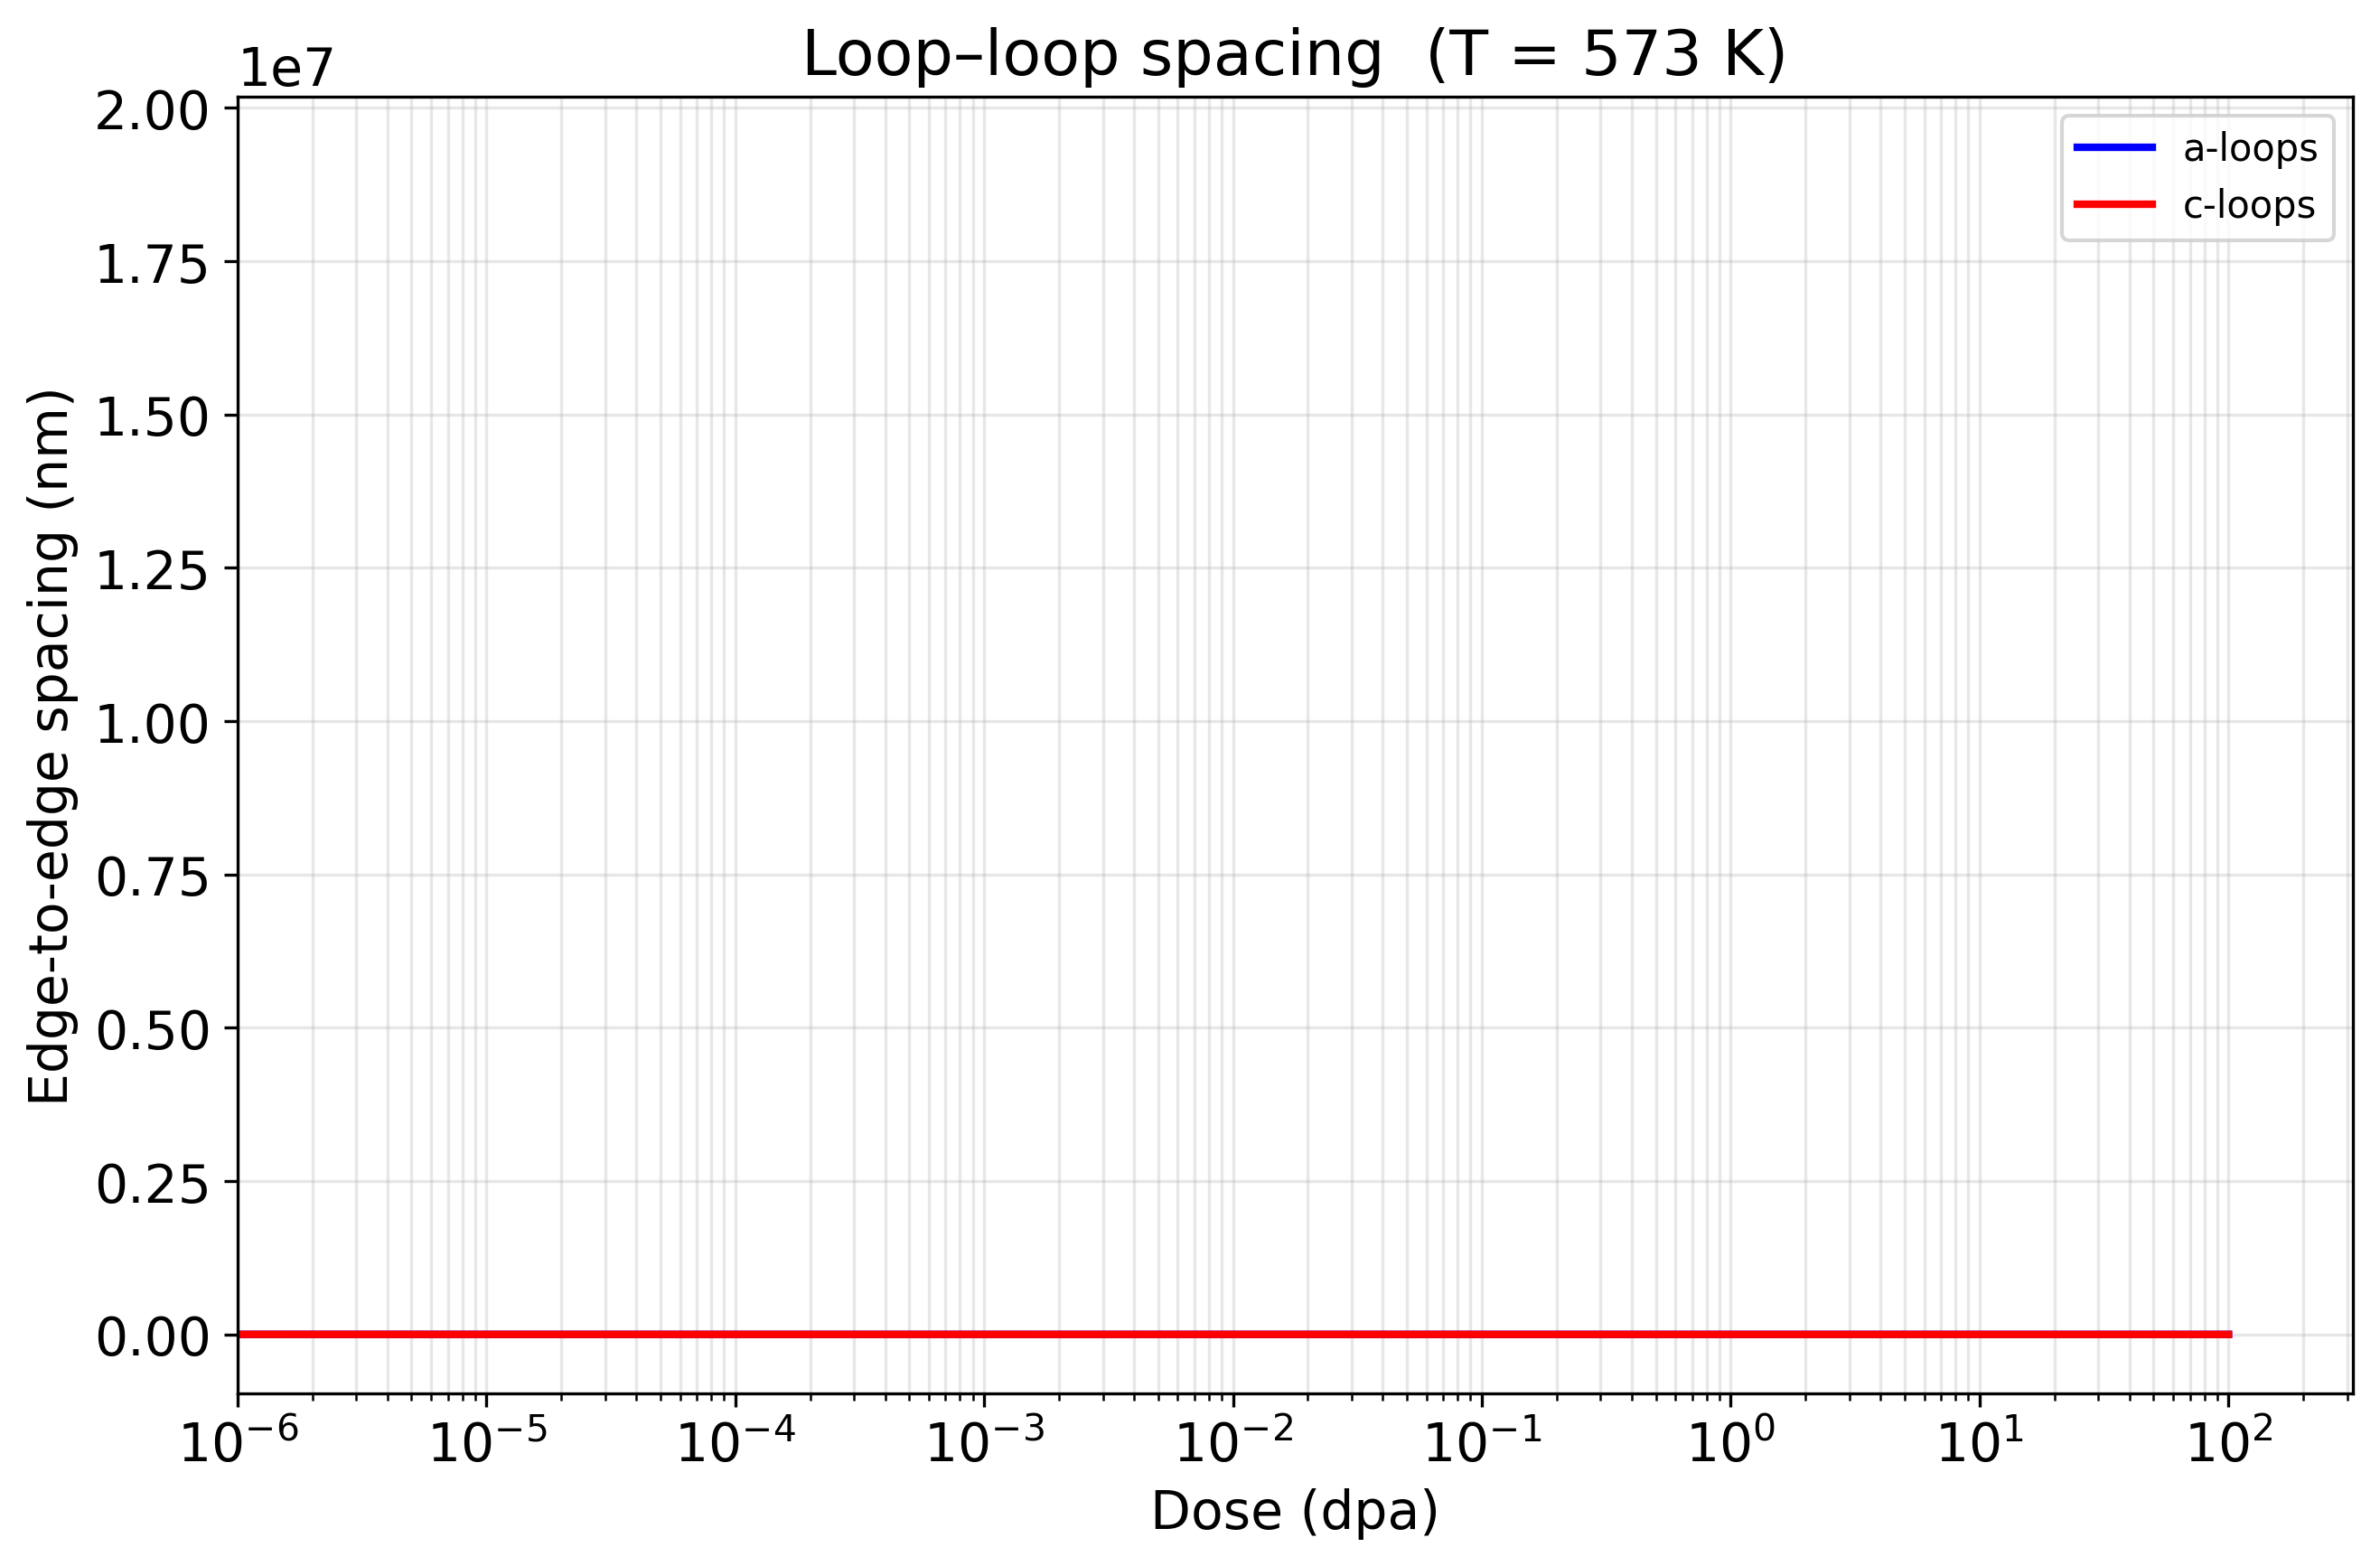

saved loop_loop_spacing.png


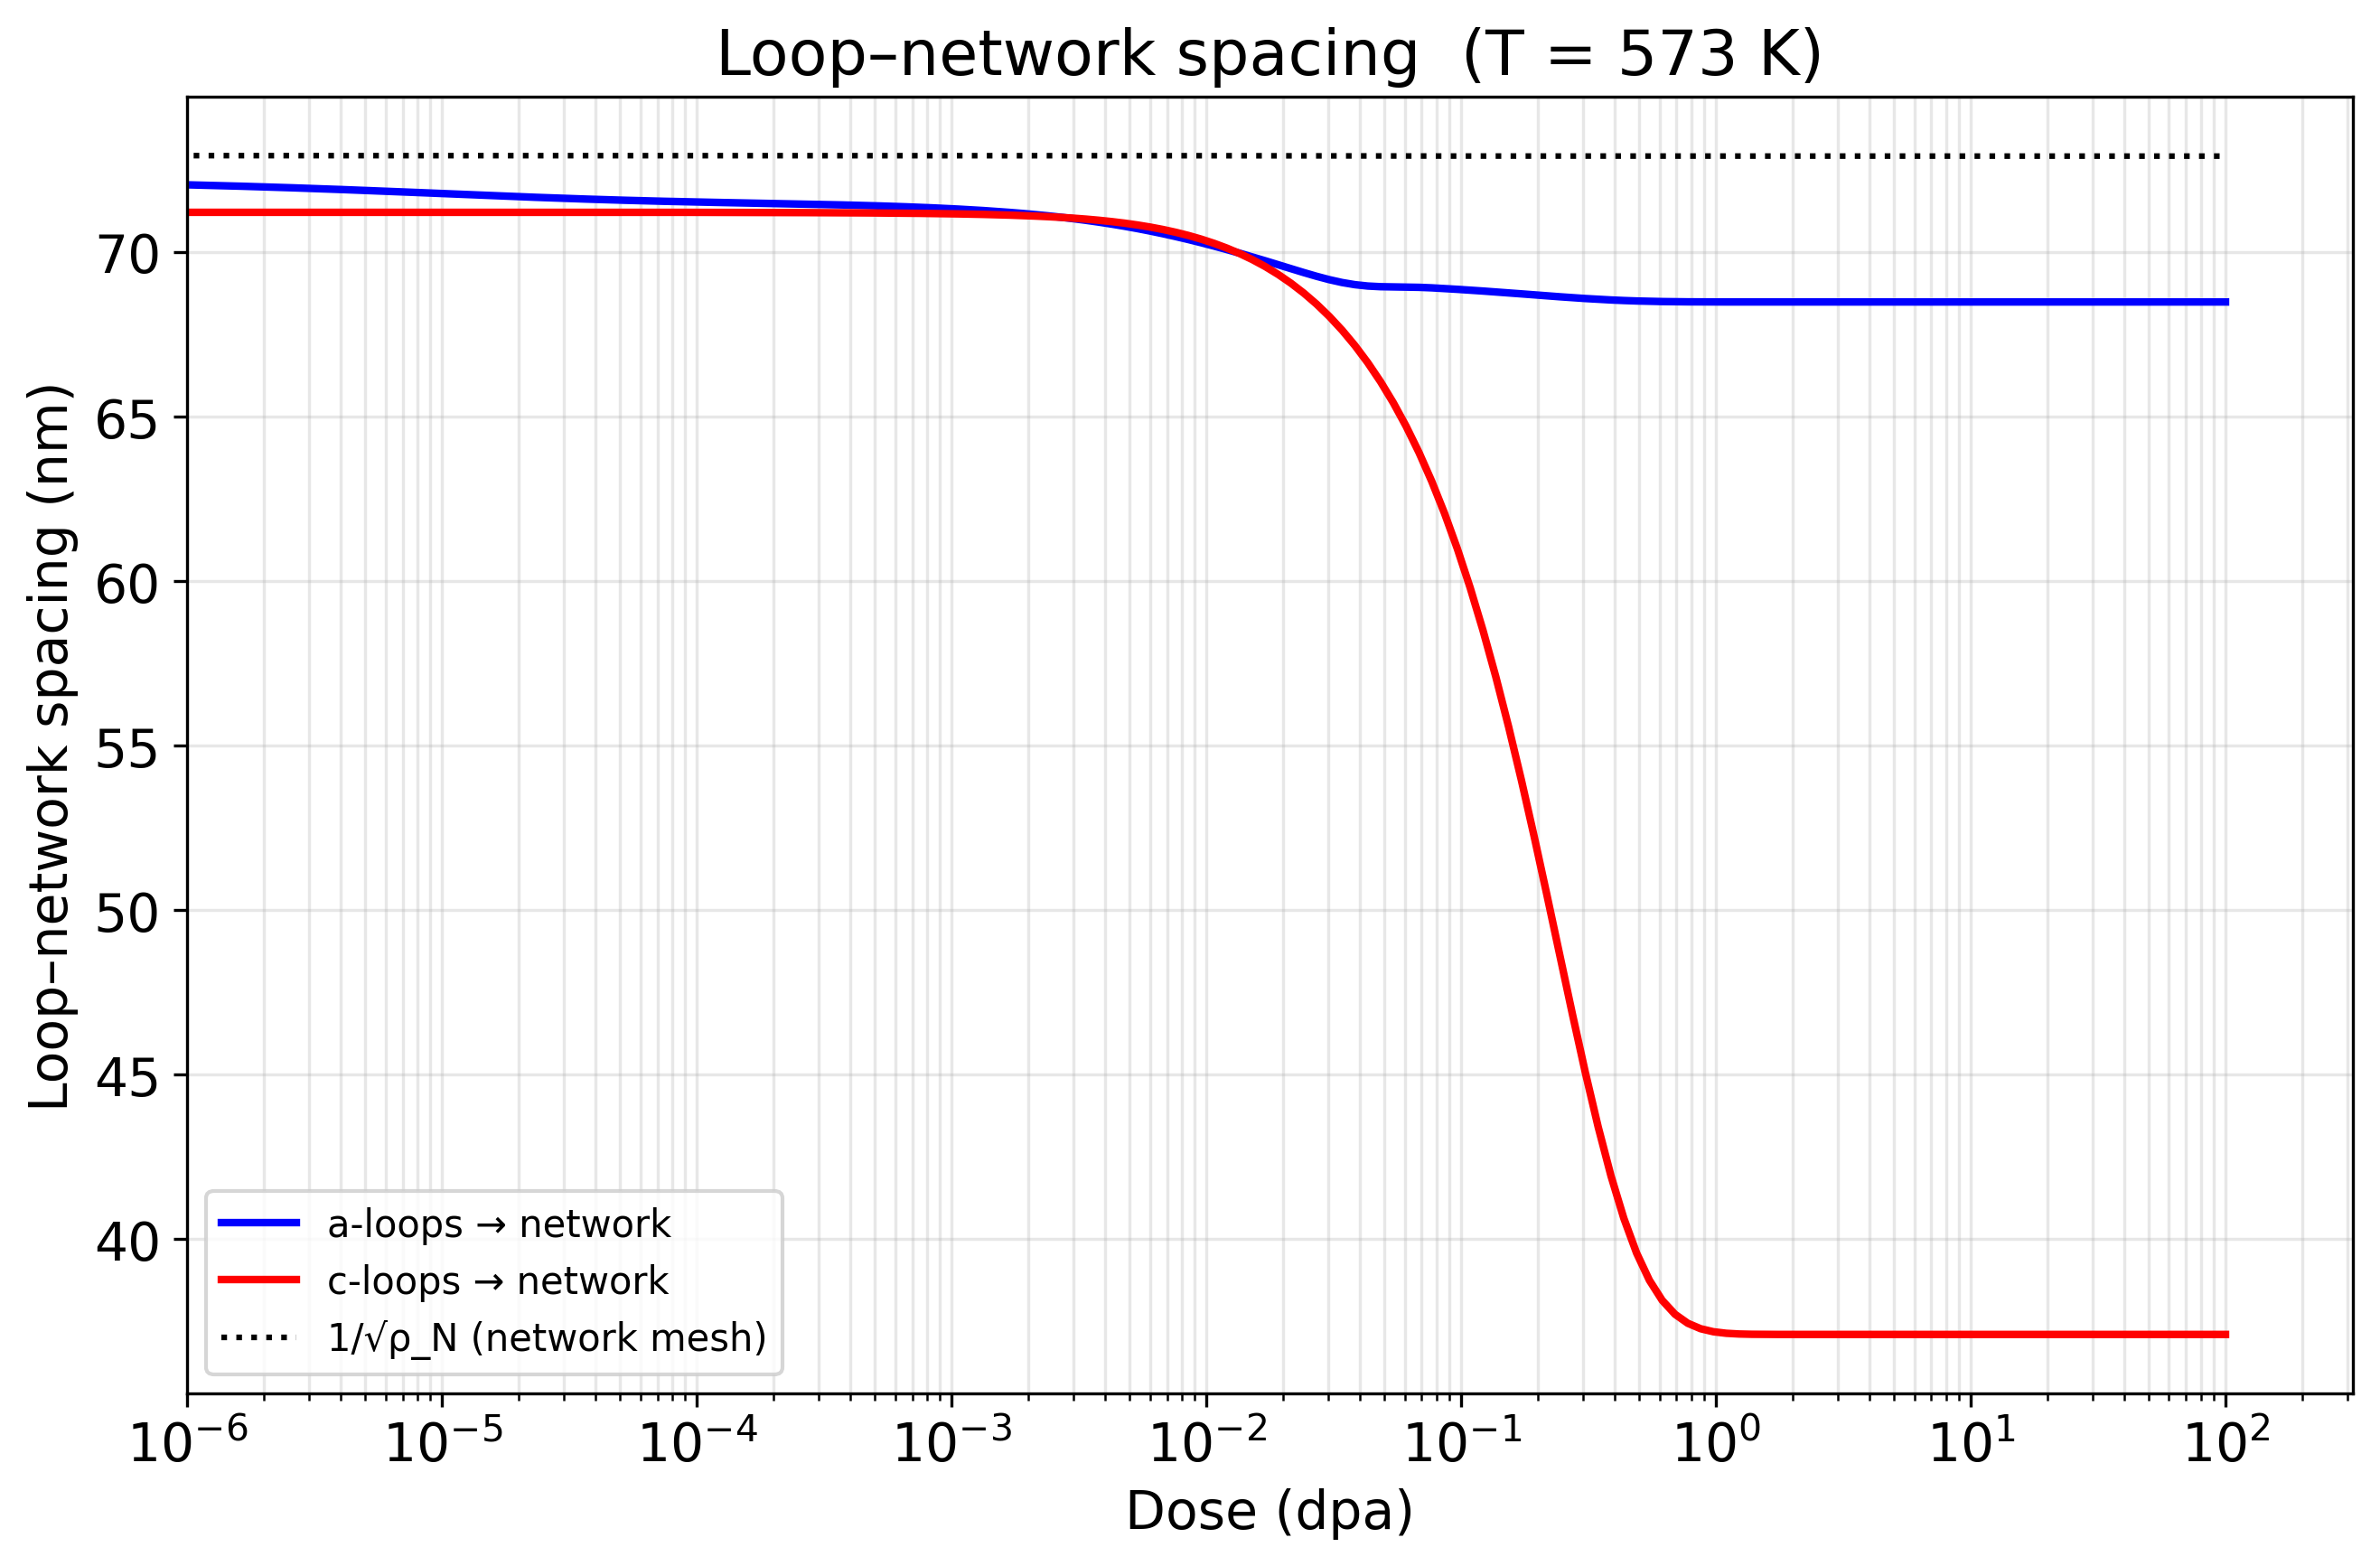

saved loop_network_spacing.png

✓ overlay & derived plots saved to D:\GitHub\ZrClusterDynamics\ZrMicro\output\20260622_144021_7959445


In [4]:
# ZrMicro: Cluster Dynamics Simulation for Zirconium Irradiation Growth
# =====================================================================
# Single orchestration cell with a selectable solver backend:
#
#   SOLVER = 'python'  ->  scipy.integrate.solve_ivp        (no build needed)
#   SOLVER = 'cpp'     ->  C++ SUNDIALS CVODE/ARKODE         (needs solver.exe)
#
# Build the C++ solver once before using SOLVER = 'cpp':
#   cd ZrMicro/cpp_utils
#   cmake -S . -B ../build -DCMAKE_BUILD_TYPE=Release
#   cmake --build ../build --config Release
#
# Both backends feed the same post-processing / visualization pipeline, so the
# figures and provenance.md are produced identically regardless of the choice.

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# ── Resolve ZrMicro/ root (parent of the code/ folder containing this notebook)
try:
    _NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    _NOTEBOOK_DIR = Path().resolve()

BASE_DIR = _NOTEBOOK_DIR.parent  # ZrMicro/
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

# ── Custom modules ──────────────────────────────────────────────────────────
try:
    from py_utils.simulation import ZrMicroSimulation
    from py_utils.reaction_rates import ReactionRates
    from py_utils.rate_equations import RateEquations
    from py_utils.cpp_bridge import (run_cpp_solver, run_cpp_solver_batch,
                                     collect_solver_args)
    from py_utils.post_process import calculate_derived_quantities
    from py_utils.visualization import plot_results
    print("✓ Successfully imported ZrMicro modules")
except ImportError as e:
    print(f"✗ Error importing simulation modules: {e}")
    print("Make sure all Python files are in the py_utils/ folder")
    raise

# ── Matplotlib defaults ─────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 14

# ── File paths ──────────────────────────────────────────────────────────────
INPUT_DIR  = BASE_DIR / 'input'
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)
INPUT_FILE = INPUT_DIR / 'input_parameters.xlsx'
# Fall back to the extended workbook when the basic input file is absent — both
# carry the same Material_Environment / Physical_Properties / Model_Parameters
# sheets that InputData reads, so the forward model runs identically from either.
if not INPUT_FILE.exists() and (INPUT_DIR / 'Zr_input_parameters.xlsx').exists():
    INPUT_FILE = INPUT_DIR / 'Zr_input_parameters.xlsx'

if not INPUT_FILE.exists():
    print(f"⚠️  Warning: Input file not found at {INPUT_FILE}")
else:
    print(f"✓ Input file found: {INPUT_FILE}")
print(f"✓ Output directory: {OUTPUT_DIR}")

print("\nZrMicro: Cluster Dynamics Simulation for Zirconium")
print("=" * 60)

# ════════════════════════════════════════════════════════════════════════════
#  USER SETTINGS  —  edit these
# ════════════════════════════════════════════════════════════════════════════
# 'cpp' (CVODE/BDF) is recommended: it is the stiff-accurate reference backend.
# The 'python' (LSODA) path is a build-free fallback but can show transient
# oscillations in the loop-content species (CiL_i, CaiL_i, CvL_v, CavL_v) and
# triggers solution-quality warnings; final-state quantities still agree.
SOLVER = 'cpp'           # 'python' (scipy/LSODA) or 'cpp' (SUNDIALS subprocess)

SIMULATION_CONFIG = {
    't_begin':  1e-1,        # s
    't_end':    1e9,         # s
    'n_points': 200,
    'rtol':     1e-6,
    'atol':     1e-20,
    'log_time': True,

    # Used only when SOLVER == 'python' (scipy.integrate.solve_ivp):
    'method':   'LSODA',     # 'LSODA', 'Radau', 'BDF'

    # Used only when SOLVER == 'cpp'; CVODE BDF + dense is recommended:
    'solver_method': {
        'backend': 'cvode',  # 'cvode' or 'arkode'
        'lmm':     'bdf',    # 'bdf' or 'adams'   (cvode only)
        'linsol':  'dense',  # 'dense', 'band', or 'gmres'
    },
}

# ────────────────────────────────────────────────────────────────────────────
#  PARAMETER OVERRIDES  —  override values loaded from input_parameters.xlsx
# ────────────────────────────────────────────────────────────────────────────
# Override any input parameter without editing the spreadsheet. Set a value to
# apply the override; leave it as None to keep the value from the Excel file.
# Each key is routed automatically to whichever sheet already defines it
# (Material_Environment / Physical_Properties / Model_Parameters), then derived
# quantities, reaction rates, and rate equations are recomputed so that BOTH
# the 'python' and 'cpp' backends pick up the new values.
#
# You may add any other parameter notation (e.g. 'Omega', 'E_m_v', 'epsilon_vL',
# 'nu_i', 'M', ...) as an extra key — it will be routed to its sheet the same way.
PARAMETER_OVERRIDES = {
    # ── c-loop JOINT refit (fit_cloops.py): J 0.609 -> 0.368 ──────────────
    #   a-loops J_A 0.370->0.325 (not disturbed), c-loops J_C 0.392->0.164
    #   key c-loop fix: c_LN_c 93 -> 3 (lets c-loops grow ~28 -> ~68 nm)
    'T'               : 573,
    'delta_DAD_i_300' : 0.153343,
    'delta_DAD_i_600' : 0.0640797,
    'Z_iL'            : 1.34408,
    'c_LL_a'          : 120.577,
    'c_LN_a'          : 1130.85,
    'epsilon_iL'      : 0.00211286,
    'n_iL_nuc'        : 300,
    'epsilon_2i'      : 0.01,
    'epsilon_3i'      : 0.01,
    'E_m_i'           : 0.759101,
    'E_m_2i'          : 1.36292,
    'E_b_2i'          : 0.957033,
    'delta_DAD'       : 0.107886,
    'c_LL_c'          : 0.162483,
    'c_LN_c'          : 2.95829,  # <-- c-loop SIZE fix (network-coalescence sink, was 93)
    'epsilon_vL'      : 0.005,  # c-loop density
    'n_vL_nuc'        : 400,  # c-loop birth size
    'E_a_vL'          : 0.470079,  # c-loop density (lifetime)
    'tau_vL0'         : 1.05145,
    'Q'               : 0.287931,
    'Z_N'             : 1.01,
    'c_rhoN'          : 0.001,
    'k_rhoN_rec'      : 3.47726e-05,
}
# ════════════════════════════════════════════════════════════════════════════

print(f"Solver backend  : {SOLVER}")
print(f"Time span       : {SIMULATION_CONFIG['t_begin']:.1e} → "
      f"{SIMULATION_CONFIG['t_end']:.1e} s  ({SIMULATION_CONFIG['n_points']} points)")
print(f"Output directory: {OUTPUT_DIR}")


def _solver_label(results, solver):
    """Human-readable description of the backend that actually ran."""
    meta = results.get('metadata', {}) if results else {}
    backend = meta.get('solver_backend')
    if backend:
        return backend
    if solver == 'python':
        return f"scipy {SIMULATION_CONFIG['method']}"
    return SIMULATION_CONFIG.get('solver_method', {}).get('backend', 'cpp')


def print_simulation_summary(results, sim, solver):
    print("\n" + "=" * 60)
    print("SIMULATION SUMMARY")
    print("=" * 60)

    print("Simulation Parameters:")
    print(f"  Temperature: {sim.input_data.material_params['T']} K")
    print(f"  Dose rate: {sim.input_data.material_params['G']:.2e} dpa/s")
    print(f"  Total time: {results['time'][-1]:.2e} seconds")
    print(f"  Solver: {_solver_label(results, solver)}")
    print(f"  Tolerances: rtol={SIMULATION_CONFIG['rtol']:.1e}, "
          f"atol={SIMULATION_CONFIG['atol']:.1e}")

    print("\nFinal Concentrations:")
    for name, values in results['concentrations'].items():
        print(f"  {name}: {values[-1]:.2e}")

    print("\nFinal Loop Sizes:")
    for name, values in results['loop_sizes'].items():
        print(f"  {name}: {values[-1]*1e9:.2f} nm")

    print("\nFinal Mechanical Properties:")
    mech = results['mechanical_properties']
    print(f"  Strain (a-direction): {mech['strain_a'][-1]*100:.4f}%")
    print(f"  Strain (c-direction): {mech['strain_c'][-1]*100:.4f}%")
    print(f"  Creep rate: {abs(mech['creep_rate'][-1]):.2e} s⁻¹")
    print(f"  Hardening: {mech['hardening'][-1]/1e6:.2f} MPa")

    if 'metadata' in results:
        stats = results['metadata']['solver_stats']
        print(f"\nSolver Statistics:")
        print(f"  Success: {stats['success']}")
        if stats.get('nfev') is not None:
            print(f"  Function evaluations: {stats['nfev']}")
        if stats.get('njev'):
            print(f"  Jacobian evaluations: {stats['njev']}")

    print("=" * 60)


def apply_parameter_overrides(sim, overrides):
    """Override Excel-loaded parameters in-place and rebuild physics modules.

    Each non-None entry is routed to whichever input dictionary already contains
    the key (material_params / physical_props / model_params). Derived quantities
    are then recomputed and the reaction-rate / rate-equation modules are rebuilt,
    because they cache T-, G- and geometry-dependent values at construction time.
    This keeps both the python (scipy) and cpp (SUNDIALS) backends consistent,
    since cpp_bridge reads from input_data.derived and sim.reaction_rates.
    """
    inp = sim.input_data
    dicts = {
        'Material_Environment': inp.material_params,
        'Physical_Properties':  inp.physical_props,
        'Model_Parameters':     inp.model_params,
    }

    applied = []
    for key, val in overrides.items():
        if val is None:
            continue
        target = next((name for name, d in dicts.items() if key in d), None)
        if target is None:
            # Not present in any sheet — add to Model_Parameters and warn.
            inp.model_params[key] = val
            applied.append((key, 'Model_Parameters (new)', None, val))
            print(f"⚠️  '{key}' not found in any sheet; added to Model_Parameters")
            continue
        old = dicts[target][key]
        dicts[target][key] = val
        applied.append((key, target, old, val))

    if not applied:
        print("No parameter overrides applied (all values are None).")
        return sim

    # Recompute derived quantities and rebuild the modules that cached them.
    inp.calculate_derived_parameters()
    sim.reaction_rates = ReactionRates(inp)
    sim.rate_equations = RateEquations(inp, sim.reaction_rates)

    def _fmt(v):
        if v is None:
            return 'n/a'
        return f'{v:.4e}' if isinstance(v, (int, float)) else str(v)

    print("\n" + "=" * 70)
    print("PARAMETER OVERRIDES APPLIED")
    print("=" * 70)
    print(f"{'Parameter':<12}{'Sheet':<24}{'Excel':>14}  ->  {'Override':<14}")
    print("-" * 70)
    for key, sheet, old, val in applied:
        print(f"{key:<12}{sheet:<24}{_fmt(old):>14}  ->  {_fmt(val):<14}")
    print("=" * 70)
    return sim


def show_plots_inline(viz, width=720):
    """Display every PNG figure from the run directory inline in the notebook."""
    if viz is None:
        return
    pngs = sorted(Path(viz.run_dir).glob('*.png'))
    if not pngs:
        print("No PNG figures found to display.")
        return
    print("\n" + "=" * 50)
    print(f"DISPLAYING {len(pngs)} FIGURES INLINE")
    print("=" * 50)
    for p in pngs:
        print(f"\n{p.name}")
        display(Image(filename=str(p), width=width))


def run_zrmicro(solver=SOLVER):
    """Initialise, integrate with the chosen backend, post-process, and plot."""
    try:
        print("\n" + "=" * 50)
        print("INITIALIZING SIMULATION")
        print("=" * 50)
        sim = ZrMicroSimulation(str(INPUT_FILE))
        apply_parameter_overrides(sim, PARAMETER_OVERRIDES)

        print("\n" + "=" * 50)
        if solver == 'cpp':
            print("RUNNING C++ SUNDIALS SOLVER")
            print("=" * 50)
            results = run_cpp_solver(sim, SIMULATION_CONFIG, base_dir=BASE_DIR)
        elif solver == 'python':
            print("RUNNING PYTHON (scipy) SOLVER")
            print("=" * 50)
            results = sim.run_simulation(
                t_begin=SIMULATION_CONFIG['t_begin'],
                t_end=SIMULATION_CONFIG['t_end'],
                n_points=SIMULATION_CONFIG['n_points'],
                method=SIMULATION_CONFIG['method'],
                rtol=SIMULATION_CONFIG['rtol'],
                atol=SIMULATION_CONFIG['atol'],
                log_time=SIMULATION_CONFIG['log_time'],
            )
        else:
            raise ValueError(
                f"SOLVER must be 'python' or 'cpp', got {solver!r}")

        if results is None:
            print(f"❌ {solver} simulation failed!")
            return None, None

        print("\n" + "=" * 50)
        print("GENERATING PLOTS")
        print("=" * 50)
        viz = plot_results(
            sim, results,
            save_plots=True,
            output_dir=str(OUTPUT_DIR),
            sim_config=SIMULATION_CONFIG,
        )

        print_simulation_summary(results, sim, solver)

        # Show every figure inline at the end of the run.
        show_plots_inline(viz)

        return results, sim

    except Exception as e:
        print(f"❌ Fatal error during simulation: {e}")
        import traceback
        traceback.print_exc()
        return None, None


results, simulation = run_zrmicro(SOLVER)

# ── Post-processing summary ─────────────────────────────────────────────────
if results is not None:
    run_dirs = sorted(
        [p for p in OUTPUT_DIR.iterdir() if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if run_dirs:
        latest = run_dirs[0]
        print(f"\n✓ All outputs saved to:\n  {latest}\n")
        print("Contents:")
        for f in sorted(latest.iterdir()):
            print(f"  {f.name}")
else:
    print("❌ No results available for post-processing")

# ════════════════════════════════════════════════════════════════════════════
#  EXPERIMENT-OVERLAY & DERIVED-PROPERTY PLOTS
#  • a-/c-loop DENSITY and DIAMETER vs dose — SEPARATE figures per family,
#    model run at each experimental temperature, measured points (±20% error
#    bars) overlaid; legends carry temperature, dose, and author-year.
#  • loop DIAMETER vs dose (all families) with experimental points overlaid.
#  • creep vs dose and hardening vs dose — SEPARATE figures, x-log.
#  • network dislocation density evolution (incl. absorbed loops).
#  • loop–loop (edge-to-edge) and loop–network spacing.
#  All dose axes start at 10^-6 dpa.
# ════════════════════════════════════════════════════════════════════════════
import io as _io, contextlib as _ctx
import pandas as _pd
import matplotlib.cm as _cm

_XMIN = 1e-6   # uniform lower dose limit (dpa)

if results is not None and simulation is not None:
    _G  = float(simulation.input_data.material_params['G'])
    _Om = float(simulation.input_data.physical_props['Omega'])
    _run_dir = max((p for p in OUTPUT_DIR.iterdir()
                    if p.is_dir() and not p.name.startswith('fit')),
                   key=lambda p: p.stat().st_mtime)

    # ── experimental targets (a- and c-loops), with author-year source ───────
    def _load_targets(sheet):
        df = _pd.read_excel(INPUT_FILE, sheet_name=sheet).iloc[:, :5]
        df.columns = ['T', 'dpa', 'N', 'd', 'Source']
        for c in ('T', 'dpa', 'N', 'd'):
            df[c] = _pd.to_numeric(df[c], errors='coerce')
        df['T'] = df['T'].ffill()
        df['Source'] = df['Source'].ffill()
        df = df.dropna(subset=['T', 'dpa'])
        return df[~(df['N'].isna() & df['d'].isna())].reset_index(drop=True)
    _exp = {'A': _load_targets('Targets_A'), 'C': _load_targets('Targets_C')}

    # ── representative temperatures (~50 K apart); nearest-assign each datum ──
    _REP_T = [473.0, 523.0, 573.0, 583.0, 623.0, 673.0]
    def _nearest_rep(T):
        return min(_REP_T, key=lambda r: abs(r - T))
    for _k in _exp:
        _exp[_k]['Trep'] = _exp[_k]['T'].map(_nearest_rep)
    _temps = sorted({t for _k in _exp for t in _exp[_k]['Trep'].unique()})

    # ── run the model once per representative temperature ────────────────────
    def _model_at(Ti):
        s = ZrMicroSimulation(str(INPUT_FILE))
        ov = dict(PARAMETER_OVERRIDES); ov['T'] = float(Ti)
        cfg = dict(SIMULATION_CONFIG)
        cfg['t_end'] = max(1e8, 80.0 / _G)      # reach ~80 dpa (covers all data)
        cfg['n_points'] = 220
        with _ctx.redirect_stdout(_io.StringIO()):
            apply_parameter_overrides(s, ov)
            r = run_cpp_solver(s, cfg, base_dir=BASE_DIR)
        if r is None:
            return None
        c, ls = r['concentrations'], r['loop_sizes']
        dose = _G * r['time']
        Na = c['CiL'] + c['CaiL']; Nc = c['CvL'] + c['CavL']
        dA = 2.0 * (c['CiL']*ls['r_iL'] + c['CaiL']*ls['r_aiL']) / np.maximum(Na, 1e-30) * 1e9
        dC = 2.0 * (c['CvL']*ls['r_vL'] + c['CavL']*ls['r_avL']) / np.maximum(Nc, 1e-30) * 1e9
        return {'dose': dose, 'A': (Na/_Om, dA), 'C': (Nc/_Om, dC)}

    print("\nRunning model at representative temperatures:",
          ", ".join(f"{t:.0f} K" for t in _temps))
    _curves = {t: _model_at(t) for t in _temps}
    _curves = {t: v for t, v in _curves.items() if v is not None}

    _norm = plt.Normalize(min(_temps), max(_temps))
    _tcol = {t: _cm.viridis(_norm(t)) for t in _temps}
    _markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', '<', '>']
    _src_mk = {}
    def _mk(src):
        return _src_mk.setdefault(src, _markers[len(_src_mk) % len(_markers)])
    _LBL = {'A': 'a-loops (interstitial)', 'C': 'c-loops (vacancy)'}
    _DENS_YMIN = {'A': 1e15, 'C': 1e18}     # per-family density lower limit

    # ── SEPARATE density and diameter overlay figures per loop family ─────────
    def _overlay_fig(k, kind):
        idx = 0 if kind == 'density' else 1
        fld = 'N' if kind == 'density' else 'd'
        fig, ax = plt.subplots(figsize=(10, 7))
        for t in sorted(_exp[k]['Trep'].unique()):   # only T's with this family's data
            cv = _curves.get(t)
            if cv:
                ax.plot(cv['dose'], cv[k][idx], color=_tcol[t], lw=2, alpha=0.9)
        for (T, src), g in _exp[k].groupby(['T', 'Source']):
            gg = g.dropna(subset=[fld])
            if not len(gg):
                continue
            col = _tcol[_nearest_rep(T)]; mk = _mk(src)
            dmin, dmax = g['dpa'].min(), g['dpa'].max()
            dlab = f"{dmin:g}" if dmin == dmax else f"{dmin:g}–{dmax:g}"
            ax.errorbar(gg['dpa'], gg[fld], yerr=0.2*gg[fld], fmt=mk, color=col,
                        ms=8, capsize=3, lw=1, mec='k', mew=0.4,
                        label=f"{T:.0f} K, {dlab} dpa, {src}")
        ax.set_xscale('log'); ax.set_xlim(left=_XMIN)
        if kind == 'density':
            ax.set_yscale('log'); ax.set_ylabel('Number density (m$^{-3}$)')
            ax.set_ylim(bottom=_DENS_YMIN[k])
        else:
            ax.set_ylabel('Diameter (nm)')
        ax.set_xlabel('Dose (dpa)')
        ax.set_title(f'{_LBL[k]} — {kind}: model (lines, colour = T) vs '
                     f'experiment (±20%)')
        ax.grid(True, which='both', alpha=0.3)
        ax.legend(fontsize=8, ncol=2, framealpha=0.9,
                  loc='upper center', bbox_to_anchor=(0.5, -0.10))
        fig.tight_layout()
        pre = 'aloop' if k == 'A' else 'cloop'
        _f = _run_dir / f'{pre}_{kind}_vs_experiment.png'
        fig.savefig(_f, dpi=200, bbox_inches='tight'); plt.show()
        print(f"saved {_f.name}")

    for k in ('A', 'C'):
        _overlay_fig(k, 'density')
        _overlay_fig(k, 'diameter')

    # ── loop DIAMETER vs dose (model families) + experiment overlay ──────────
    _Tp = float(PARAMETER_OVERRIDES.get('T', simulation.input_data.material_params['T']))
    _ls = results['loop_sizes']
    _c  = results['concentrations']
    _dose = _G * np.asarray(results['time'])
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.plot(_dose, 2*_ls['r_iL'] * 1e9,  'b-',  lw=2, label='interstitial loops (model)')
    ax.plot(_dose, 2*_ls['r_aiL'] * 1e9, 'b--', lw=2, label='aligned interstitial (model)')
    ax.plot(_dose, 2*_ls['r_vL'] * 1e9,  'r-',  lw=2, label='vacancy loops (model)')
    ax.plot(_dose, 2*_ls['r_avL'] * 1e9, 'r--', lw=2, label='aligned vacancy (model)')
    for k, c0, lt in (('A', 'b', 'a'), ('C', 'r', 'c')):     # exp points within ±50 K of run T
        sub = _exp[k][(_exp[k]['T'] - _Tp).abs() <= 50.0].dropna(subset=['d'])
        for (T, src), g in sub.groupby(['T', 'Source']):
            ax.errorbar(g['dpa'], g['d'], yerr=0.2*g['d'], fmt=_mk(src), color=c0,
                        ms=8, capsize=3, lw=1, mec='k', mew=0.4,
                        label=f"{lt}-exp {T:.0f} K, {src}")
    ax.set(xscale='log', xlabel='Dose (dpa)', ylabel='Loop diameter (nm)',
           title=f'Loop diameter vs dose  (model T = {_Tp:.0f} K; exp points ±20%)')
    ax.set_xlim(left=_XMIN)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=11, ncol=2, loc='upper left')
    fig.tight_layout()
    _f = _run_dir / 'loop_diameter_vs_dose.png'
    fig.savefig(_f, dpi=200, bbox_inches='tight'); plt.show()
    print(f"saved {_f.name}")

    # ── creep vs dose and hardening vs dose — SEPARATE figures, x-log ────────
    _mech = results['mechanical_properties']
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(_dose, _mech['creep_rate'], 'g-', lw=2)
    ax.set(xscale='log', xlabel='Dose (dpa)', ylabel='Creep strain',
           title=f'Irradiation creep  (T = {_Tp:.0f} K)')
    ax.set_xlim(left=_XMIN); ax.grid(True, which='both', alpha=0.3); fig.tight_layout()
    _f = _run_dir / 'creep_vs_dose.png'
    fig.savefig(_f, dpi=200, bbox_inches='tight'); plt.show()
    print(f"saved {_f.name}")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(_dose, np.asarray(_mech['hardening']) / 1e6, 'm-', lw=2)
    ax.set(xscale='log', xlabel='Dose (dpa)', ylabel='Hardening Δτ (MPa)',
           title=f'Radiation hardening  (T = {_Tp:.0f} K)')
    ax.set_xlim(left=_XMIN); ax.grid(True, which='both', alpha=0.3); fig.tight_layout()
    _f = _run_dir / 'hardening_vs_dose.png'
    fig.savefig(_f, dpi=200, bbox_inches='tight'); plt.show()
    print(f"saved {_f.name}")

    # ── network dislocation density evolution (incl. absorbed loops) ─────────
    # rho_N is the evolving network density; loop–network coalescence feeds
    # absorbed loops into it. The loop LINE-LENGTH density (Σ 2πr·N) and the
    # grand-total dislocation density are shown alongside.
    _rhoN = np.asarray(results.get('rho_N', np.full_like(_dose, np.nan)))
    def _line(famN, r):
        return 2.0 * np.pi * np.asarray(r) * np.asarray(famN) / _Om
    _ll_a = _line(_c['CiL'], _ls['r_iL']) + _line(_c['CaiL'], _ls['r_aiL'])
    _ll_c = _line(_c['CvL'], _ls['r_vL']) + _line(_c['CavL'], _ls['r_avL'])
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.loglog(_dose, _rhoN, 'k-', lw=2.2, label='network ρ_N (incl. absorbed loops)')
    ax.loglog(_dose, _ll_a, 'b-', lw=2, label='a-loop line density')
    ax.loglog(_dose, _ll_c, 'r-', lw=2, label='c-loop line density')
    ax.loglog(_dose, _rhoN + _ll_a + _ll_c, 'g--', lw=2, label='total dislocation density')
    ax.set(xlabel='Dose (dpa)', ylabel='Dislocation density (m$^{-2}$)',
           title=f'Network dislocation density evolution  (T = {_Tp:.0f} K)')
    ax.set_xlim(left=_XMIN); ax.set_ylim(bottom=1e11)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
    fig.tight_layout()
    _f = _run_dir / 'network_density_evolution.png'
    fig.savefig(_f, dpi=200, bbox_inches='tight'); plt.show()
    print(f"saved {_f.name}")

    # ── loop–loop (edge-to-edge) and loop–network spacing ────────────────────
    _Na = (_c['CiL'] + _c['CaiL']) / _Om
    _Nc = (_c['CvL'] + _c['CavL']) / _Om
    _ra = (_c['CiL']*_ls['r_iL'] + _c['CaiL']*_ls['r_aiL']) / np.maximum(_c['CiL']+_c['CaiL'], 1e-30)
    _rc = (_c['CvL']*_ls['r_vL'] + _c['CavL']*_ls['r_avL']) / np.maximum(_c['CvL']+_c['CavL'], 1e-30)
    def _edge2edge(N, r):                      # nearest-neighbour spacing minus the two radii
        return np.maximum(np.maximum(N, 1e-30) ** (-1.0/3.0) - 2.0*np.asarray(r), 1e-12)
    _ll_sp_a = _edge2edge(_Na, _ra); _ll_sp_c = _edge2edge(_Nc, _rc)
    _net_mesh = 1.0 / np.sqrt(np.maximum(_rhoN, 1e-30))     # mean network line spacing
    _ln_sp_a = np.maximum(_net_mesh - _ra, 1e-12)
    _ln_sp_c = np.maximum(_net_mesh - _rc, 1e-12)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.semilogx(_dose, _ll_sp_a*1e9, 'b-', lw=2, label='a-loops')
    ax.semilogx(_dose, _ll_sp_c*1e9, 'r-', lw=2, label='c-loops')
    ax.set(xlabel='Dose (dpa)', ylabel='Edge-to-edge spacing (nm)',
           title=f'Loop–loop spacing  (T = {_Tp:.0f} K)')
    ax.set_xlim(left=_XMIN); ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=10)
    fig.tight_layout()
    _f = _run_dir / 'loop_loop_spacing.png'
    fig.savefig(_f, dpi=200, bbox_inches='tight'); plt.show()
    print(f"saved {_f.name}")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.semilogx(_dose, _ln_sp_a*1e9, 'b-', lw=2, label='a-loops → network')
    ax.semilogx(_dose, _ln_sp_c*1e9, 'r-', lw=2, label='c-loops → network')
    ax.semilogx(_dose, _net_mesh*1e9, 'k:', lw=1.5, label='1/√ρ_N (network mesh)')
    ax.set(xlabel='Dose (dpa)', ylabel='Loop–network spacing (nm)',
           title=f'Loop–network spacing  (T = {_Tp:.0f} K)')
    ax.set_xlim(left=_XMIN); ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=10)
    fig.tight_layout()
    _f = _run_dir / 'loop_network_spacing.png'
    fig.savefig(_f, dpi=200, bbox_inches='tight'); plt.show()
    print(f"saved {_f.name}")

    print(f"\n✓ overlay & derived plots saved to {_run_dir}")
